# TP2 — Análisis Exploratorio y Curación de Datos: Black Friday

**Mentoría · Diplomatura en Ciencia de Datos (FAMAF 2026)**
Proyecto: *Descifrando el carrito: patrones de compra en Black Friday*

---

### Qué hace esta notebook

Toma el dataset sintético temporal de Black Friday (`bf_dataset_temporal.csv`, 3 campañas,
1,65 M de transacciones) y lo lleva
de "archivo crudo" a **dataset curado listo para modelar**, documentando cada decisión.

| Sección | Contenido |
|---|---|
| 0 | Preparación, carga y **registro de trazabilidad** |
| 1 | Auditoría: granularidad, nulos, valores erróneos, outliers |
| 2 | Análisis exploratorio temporal: estacionalidad, tendencia, segmentación |
| 3 | Curación, transformación y *feature engineering* (incluye imputación KNN y PCA) |
| 4 | Relaciones y dependencia temporal |
| 5 | Balance de la curación |
| 6 | Generación del dataset curado |

**Criterio de trabajo.** En la sección 1 **no se modifica nada**: solo se diagnostica y se propone.
Las modificaciones se aplican a partir de la sección 3, y cada una queda registrada para el balance
de la sección 5.

**Reproducibilidad.** Semilla fija (`SEMILLA = 42`) en todo procedimiento aleatorio. Los pasos
computacionalmente costosos (imputación multivariada, PCA) se ejecutan sobre una **muestra
reproducible**; la auditoría, la curación y el dataset final se ejecutan sobre las **1,65 M de filas
completas**, preservando la granularidad transaccional.

## 0. Preparación del entorno y trazabilidad

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import hashlib, os, warnings
from datetime import datetime

warnings.filterwarnings("ignore")

# ---------------- Reproducibilidad ----------------
SEMILLA = 42
np.random.seed(SEMILLA)

# ---------------- Display ----------------
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# ---------------- Estilo de gráficos ----------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (12, 4.5), "figure.dpi": 110,
    "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.labelsize": 10.5, "font.size": 9.5,
})
PALETA = sns.color_palette("deep")
COL_AÑO = {2022: PALETA[0], 2023: PALETA[1], 2024: PALETA[3]}

def miles(ax, eje="y"):
    """Formatea un eje con separador de miles."""
    f = mticker.FuncFormatter(lambda v, p: f"{v:,.0f}")
    (ax.yaxis if eje == "y" else ax.xaxis).set_major_formatter(f)

def millones(ax, eje="y"):
    """Formatea un eje en millones."""
    f = mticker.FuncFormatter(lambda v, p: f"{v/1e6:,.0f}M")
    (ax.yaxis if eje == "y" else ax.xaxis).set_major_formatter(f)

# ---------------- Bitácora de decisiones (se usa en la sección 5) ----------------
BITACORA = []

def registrar(seccion, variable, accion, filas_afectadas, justificacion):
    """Registra cada decisión de curación para el balance final."""
    BITACORA.append({
        "seccion": seccion, "variable": variable, "accion": accion,
        "filas_afectadas": filas_afectadas, "justificacion": justificacion,
    })

print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")
print(f"SEMILLA = {SEMILLA}")

pandas 2.0.3 | numpy 1.24.4 | seaborn 0.13.2
SEMILLA = 42


### 0.1 — Carga del dataset

El archivo de entrada es `bf_dataset_temporal.csv` (**245 MB sin comprimir**, 1,65 M de filas).
Está publicado en Google Drive del grupo:

`https://drive.google.com/file/d/1SIhxuMeAGLLYv3Pgz4mFE_LtywgM6QGl/view`

Usamos una **cadena de alternativas** para que la notebook corra en cualquier contexto, en este orden:

1. **Google Drive vía `gdown`** — fuente principal. Usamos `gdown` y no una URL directa porque, para
   archivos de más de ~100 MB, Drive intercala una pantalla de confirmación de análisis antivirus:
   una petición simple devolvería ese HTML en lugar del CSV. `gdown` resuelve el token de
   confirmación automáticamente y viene preinstalado en Colab.
2. **Archivo ya descargado** en la sesión (evita volver a bajar 245 MB si se reinicia el kernel).
3. **Raw de GitHub** (`.csv.gz`), por si el grupo lo commitea al repositorio.
4. **Drive montado** o **subida manual**, como último recurso.

**Tipos declarados en la lectura.** Pasamos el diccionario `DTYPES` directamente a `read_csv` en lugar
de leer y después optimizar. La diferencia importa: leer con los tipos que infiere pandas ocupa
**937 MB** de RAM y recién después baja, mientras que declararlos de entrada usa **225 MB** desde el
principio. Con la RAM acotada de Colab, evitar ese pico intermedio es lo que permite trabajar con el
dataset completo.

In [2]:
# ---------------- Identificación del archivo de entrada ----------------
ARCHIVO      = "bf_dataset_temporal.csv"
DRIVE_FILE_ID = "1SIhxuMeAGLLYv3Pgz4mFE_LtywgM6QGl"
DRIVE_URL     = f"https://drive.google.com/file/d/{DRIVE_FILE_ID}/view"
URL_RAW_GZ    = ("https://raw.githubusercontent.com/dyvanoff/"
                 "blackfriday_sales_prediction/main/datos/bf_dataset_temporal.csv.gz")

# ---------------- Tipos declarados en la lectura ----------------
# Declararlos de entrada evita el pico de 937 MB que produce la inferencia de pandas.
DTYPES = {
    "Transaction_ID": "string",  "User_ID": "int32",       "Product_ID": "category",
    "Transaction_Hour": "int8",  "Campaign_Year": "int16",
    "Days_To_Black_Friday": "int16", "Is_Weekend": "int8",
    "Sales_Channel": "category",
    "CPI_Index": "float32",              "Monthly_Inflation_Rate": "float32",
    "Consumer_Confidence_Index": "float32", "Retail_Activity_Index": "float32",
    "Retail_Activity_MoM": "float32",    "Category_Activity_Index": "float32",
    "Category_Activity_MoM": "float32",
    "Gender": "category", "Age": "category", "Occupation": "int8",
    "City_Category": "category", "Stay_In_Current_City_Years": "category",
    "Marital_Status": "int8",
    "Product_Category_1": "int8", "Product_Category_2": "float32",
    "Product_Category_3": "float32",
    "Transaction_Satisfaction_Score": "float32", "Purchase": "int32",
}

def _leer(ruta):
    """Lee el CSV con los tipos declarados. La compresión se infiere de la extensión."""
    return pd.read_csv(ruta, dtype=DTYPES, parse_dates=["Purchase_Date"],
                       compression="infer")

def cargar_dataset():
    """Intenta las fuentes en orden y devuelve (DataFrame, descripción del origen)."""

    # (1) Google Drive vía gdown — fuente principal
    try:
        try:
            import gdown
        except ImportError:
            print("instalando gdown...")
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown
        if not os.path.exists(ARCHIVO):
            print(f"descargando {ARCHIVO} desde Google Drive (245 MB)...")
            gdown.download(id=DRIVE_FILE_ID, output=ARCHIVO, quiet=False)
        datos = _leer(ARCHIVO)
        print(f"OK — leído desde Google Drive (id {DRIVE_FILE_ID})")
        return datos, f"Google Drive: {DRIVE_URL}"
    except Exception as e:
        print(f"  no disponible (Google Drive/gdown): {type(e).__name__}: {e}")

    # (2)-(4) Alternativas
    for nombre, ruta in [
        ("archivo local",        ARCHIVO),
        ("archivo local .gz",    "bf_dataset_temporal.csv.gz"),
        ("repo clonado",         f"blackfriday_sales_prediction/datos/{ARCHIVO}"),
        ("repo clonado .gz",     "blackfriday_sales_prediction/datos/bf_dataset_temporal.csv.gz"),
        ("carpeta datos/",       f"datos/{ARCHIVO}"),
        ("carpeta datos/ .gz",   "datos/bf_dataset_temporal.csv.gz"),
        ("raw de GitHub",        URL_RAW_GZ),
        ("Drive montado",        f"/content/drive/MyDrive/{ARCHIVO}"),
    ]:
        try:
            datos = _leer(ruta)
            print(f"OK — leído desde {nombre}")
            return datos, f"{nombre}: {ruta}"
        except Exception as e:
            print(f"  no disponible ({nombre}): {type(e).__name__}")

    # (5) Subida manual
    try:
        from google.colab import files
        print("\nSubí el archivo bf_dataset_temporal.csv:")
        subido = files.upload()
        nombre_archivo = list(subido.keys())[0]
        return _leer(nombre_archivo), f"subida manual: {nombre_archivo}"
    except Exception as e:
        raise RuntimeError(
            "No se pudo cargar el dataset por ninguna vía.\n"
            f"Descargalo a mano desde {DRIVE_URL} y volvé a ejecutar esta celda.\n"
            f"Error final: {e}"
        )

df, ORIGEN = cargar_dataset()
print(f"\nDimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum()/1024**2:,.0f} MB")

OK — leído desde Google Drive (id 1SIhxuMeAGLLYv3Pgz4mFE_LtywgM6QGl)

Dimensiones: 1,650,204 filas x 27 columnas
Memoria: 225 MB


### 0.2 — Optimización de tipos

937 MB en RAM con los tipos que infiere pandas es innecesario. Convertimos a `category` las
categóricas de baja cardinalidad y reducimos la precisión de enteros y flotantes. Esto no cambia
ningún valor, solo la representación en memoria — importante en Colab, donde la RAM es limitada.

In [3]:
# Los tipos ya vienen declarados desde read_csv. Acá solo verificamos el resultado
# y dejamos constancia del ahorro de memoria.
resumen_tipos = (pd.DataFrame({"dtype": df.dtypes.astype(str),
                               "MB": (df.memory_usage(deep=True)[1:] / 1024**2).round(1)})
                   .sort_values("MB", ascending=False))
display(resumen_tipos.head(8))

total_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memoria total: {total_mb:,.0f} MB")
print(f"Para referencia, con los tipos que infiere pandas por defecto: ~937 MB "
      f"({(1 - total_mb/937)*100:.0f}% menos)\n")
print(f"Transaction_ID concentra "
      f"{df.Transaction_ID.memory_usage(deep=True)/1024**2:,.0f} MB: es única en cada fila,")
print("así que convertirla a category no comprimiría nada. La conservamos como identificador.")

# Verificación de que forzar los tipos no alteró ningún valor
print("\nControl de integridad tras la lectura con tipos declarados:")
print(f"  filas .................. {len(df):,}")
print(f"  suma de Purchase ....... {df.Purchase.sum():,}")
print(f"  rango de fechas ........ {df.Purchase_Date.min().date()} a {df.Purchase_Date.max().date()}")
print(f"  Days_To_Black_Friday ... {df.Days_To_Black_Friday.min()} a {df.Days_To_Black_Friday.max()}")
print(f"  nulos por variable ..... {df.isnull().sum()[lambda s: s > 0].to_dict()}")

,dtype,MB
Transaction_ID,string,111.700
Purchase_Date,datetime64[ns],12.600
Consumer_Confidence_Index,float32,6.300
Transaction_Satisfaction_Score,float32,6.300
Product_Category_3,float32,6.300
Product_Category_2,float32,6.300
Category_Activity_MoM,float32,6.300
Category_Activity_Index,float32,6.300


Memoria total: 225 MB
Para referencia, con los tipos que infiere pandas por defecto: ~937 MB (76% menos)

Transaction_ID concentra 112 MB: es única en cada fila,
así que convertirla a category no comprimiría nada. La conservamos como identificador.

Control de integridad tras la lectura con tipos declarados:
  filas .................. 1,650,204
  suma de Purchase ....... 17,647,185,603
  rango de fechas ........ 2022-01-01 a 2024-12-31
  Days_To_Black_Friday ... -333 a 37
  nulos por variable ..... {'CPI_Index': 529698, 'Consumer_Confidence_Index': 327879, 'Product_Category_2': 520914, 'Product_Category_3': 1149741, 'Transaction_Satisfaction_Score': 125314}


### 0.3 — Registro de trazabilidad

El enunciado pide dejar constancia explícita de **archivo usado, dimensiones, rango de fechas y
semilla**. Lo dejamos en una única celda para que quede visible y sea copiable al informe.

In [4]:
DIAS_ESPERADOS = pd.date_range(df.Purchase_Date.min(), df.Purchase_Date.max(), freq="D")

TRAZABILIDAD = {
    "archivo_entrada":      ARCHIVO,
    "drive_file_id":        DRIVE_FILE_ID,
    "origen_efectivo":      ORIGEN,
    "memoria_MB":           round(df.memory_usage(deep=True).sum()/1024**2),
    "filas":                len(df),
    "columnas":             df.shape[1],
    "fecha_min":            df.Purchase_Date.min().date(),
    "fecha_max":            df.Purchase_Date.max().date(),
    "dias_calendario":      len(DIAS_ESPERADOS),
    "dias_con_datos":       df.Purchase_Date.nunique(),
    "campañas":             sorted(df.Campaign_Year.unique().tolist()),
    "clientes_unicos":      df.User_ID.nunique(),
    "productos_unicos":     df.Product_ID.nunique(),
    "semilla":              SEMILLA,
    "ejecutado":            datetime.now().strftime("%Y-%m-%d %H:%M"),
    "pandas":               pd.__version__,
}

print("=" * 62)
print("REGISTRO DE TRAZABILIDAD")
print("=" * 62)
for k, v in TRAZABILIDAD.items():
    print(f"  {k:.<24} {v}")
print("=" * 62)

df.head(3)

REGISTRO DE TRAZABILIDAD
  archivo_entrada......... bf_dataset_temporal.csv
  drive_file_id........... 1SIhxuMeAGLLYv3Pgz4mFE_LtywgM6QGl
  origen_efectivo......... Google Drive: https://drive.google.com/file/d/1SIhxuMeAGLLYv3Pgz4mFE_LtywgM6QGl/view
  memoria_MB.............. 225
  filas................... 1650204
  columnas................ 27
  fecha_min............... 2022-01-01
  fecha_max............... 2024-12-31
  dias_calendario......... 1096
  dias_con_datos.......... 1096
  campañas................ [2022, 2023, 2024]
  clientes_unicos......... 5891
  productos_unicos........ 3631
  semilla................. 42
  ejecutado............... 2026-09-15 17:32
  pandas.................. 2.0.3


,Transaction_ID,User_ID,Product_ID,Purchase_Date,Transaction_Hour,Campaign_Year,Days_To_Black_Friday,Is_Weekend,Sales_Channel,CPI_Index,Monthly_Inflation_Rate,Consumer_Confidence_Index,Retail_Activity_Index,Retail_Activity_MoM,Category_Activity_Index,Category_Activity_MoM,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Transaction_Satisfaction_Score,Purchase
0,BF2022_0066863,1004238,P0095642,2022-01-01,0,2022,-328,1,Online,100.679,0.679,101.440,94.000,-12.460,105.912,-1.027,M,36-45,16,B,3,0,5,NaN,NaN,4.784,5040
1,BF2022_0069738,1004670,P00084042,2022-01-01,0,2022,-328,1,Online,NaN,0.679,NaN,94.000,-12.460,99.709,0.865,M,36-45,5,C,2,0,12,14.000,NaN,7.178,1165
2,BF2022_0306749,1005275,P00345842,2022-01-01,0,2022,-328,1,Online,NaN,0.679,101.440,94.000,-12.460,101.733,1.662,M,26-35,17,A,4+,0,2,8.000,14.000,5.003,9500


> ### Conclusión 0
>
> El archivo de entrada tiene **1.650.204 filas × 27 columnas** y cubre **1.096 días corridos**, del
> **2022-01-01 al 2024-12-31** — tres campañas completas (2022, 2023, 2024) sin ningún día faltante
> en el calendario.
>
> Involucra **5.891 clientes** y **3.631 productos**, exactamente los mismos que el dataset del TP1.
> Esa coincidencia no es casual y tiene consecuencias que analizamos en 1.a.
>
> La optimización de tipos baja la huella en memoria de **937 MB a 232 MB (−75%)**, lo que permite
> trabajar con el dataset completo en Colab sin recurrir a muestreo para la mayor parte del análisis.

---
# 1. Auditoría, calidad y trazabilidad

En toda esta sección **no modificamos el dataset**: diagnosticamos y proponemos. Las correcciones se
aplican en la sección 3, para que el balance de la sección 5 pueda comparar el antes y el después.

## 1.a — Estructura y granularidad

In [5]:
# Radiografía columna por columna
BLOQUE = {
    "Transaction_ID": "Identificador", "User_ID": "Cliente", "Product_ID": "Producto",
    "Purchase_Date": "Temporal", "Transaction_Hour": "Temporal", "Campaign_Year": "Temporal",
    "Days_To_Black_Friday": "Temporal", "Is_Weekend": "Temporal",
    "Sales_Channel": "Transacción",
    "CPI_Index": "Contexto económico", "Monthly_Inflation_Rate": "Contexto económico",
    "Consumer_Confidence_Index": "Contexto económico", "Retail_Activity_Index": "Contexto económico",
    "Retail_Activity_MoM": "Contexto económico",
    "Category_Activity_Index": "Actividad del rubro", "Category_Activity_MoM": "Actividad del rubro",
    "Gender": "Cliente", "Age": "Cliente", "Occupation": "Cliente", "City_Category": "Cliente",
    "Stay_In_Current_City_Years": "Cliente", "Marital_Status": "Cliente",
    "Product_Category_1": "Producto", "Product_Category_2": "Producto",
    "Product_Category_3": "Producto",
    "Transaction_Satisfaction_Score": "Transacción", "Purchase": "OBJETIVO",
}

radiografia = pd.DataFrame({
    "bloque":   [BLOQUE.get(c, "?") for c in df.columns],
    "dtype":    [str(df[c].dtype) for c in df.columns],
    "n_unicos": [df[c].nunique() for c in df.columns],
    "nulos":    [df[c].isnull().sum() for c in df.columns],
    "nulos_%":  [round(df[c].isnull().mean()*100, 2) for c in df.columns],
}, index=df.columns)
radiografia

,bloque,dtype,n_unicos,nulos,nulos_%
Transaction_ID,Identificador,string,1650204,0,0.000
User_ID,Cliente,int32,5891,0,0.000
Product_ID,Producto,category,3631,0,0.000
Purchase_Date,Temporal,datetime64[ns],1096,0,0.000
Transaction_Hour,Temporal,int8,24,0,0.000
Campaign_Year,Temporal,int16,3,0,0.000
Days_To_Black_Friday,Temporal,int16,371,0,0.000
Is_Weekend,Temporal,int8,2,0,0.000
Sales_Channel,Transacción,category,2,0,0.000
CPI_Index,Contexto económico,float32,36,529698,32.100


In [6]:
# --- Unidad de observación ---
print("¿Cuál es la unidad de observación?")
print("-" * 58)
print(f"filas                        {len(df):,}")
print(f"Transaction_ID únicos        {df.Transaction_ID.nunique():,}")
print(f"¿Transaction_ID es única?    {df.Transaction_ID.is_unique}")
print(f"\n=> 1 fila = 1 TRANSACCIÓN individual (no un agregado mensual como en el TP1)")

# --- Continuidad diaria y rango ---
print(f"\nRango: {df.Purchase_Date.min().date()} a {df.Purchase_Date.max().date()}")
print(f"Días de calendario esperados: {len(DIAS_ESPERADOS):,}")
print(f"Días con al menos una transacción: {df.Purchase_Date.nunique():,}")
faltantes = set(DIAS_ESPERADOS) - set(df.Purchase_Date.unique())
print(f"Días faltantes: {len(faltantes)}  -> serie diaria CONTINUA" if not faltantes
      else f"Días faltantes: {sorted(faltantes)[:10]}")

tx_dia = df.groupby("Purchase_Date").size()
print(f"\nTransacciones por día: mín {tx_dia.min():,} | mediana {tx_dia.median():,.0f} "
      f"| máx {tx_dia.max():,}")

¿Cuál es la unidad de observación?
----------------------------------------------------------
filas                        1,650,204
Transaction_ID únicos        1,650,204
¿Transaction_ID es única?    True

=> 1 fila = 1 TRANSACCIÓN individual (no un agregado mensual como en el TP1)

Rango: 2022-01-01 a 2024-12-31
Días de calendario esperados: 1,096
Días con al menos una transacción: 1,096
Días faltantes: 0  -> serie diaria CONTINUA

Transacciones por día: mín 819 | mediana 1,202 | máx 17,614


In [7]:
# --- Duplicados: exactos y según clave de negocio ---
print("BÚSQUEDA DE DUPLICADOS")
print("=" * 66)
print(f"Filas duplicadas exactas (las 27 columnas): {df.duplicated().sum():,}")
print(f"Transaction_ID repetido:                    {df.duplicated(['Transaction_ID']).sum():,}")

print("\n¿Por qué repetir User_ID o Product_ID NO es un duplicado?")
print("-" * 66)
print(f"  User_ID repetido:                         {df.duplicated(['User_ID']).sum():,}")
print(f"  Product_ID repetido:                      {df.duplicated(['Product_ID']).sum():,}")
print(f"  (User_ID, Product_ID) repetido:           {df.duplicated(['User_ID','Product_ID']).sum():,}")

CLAVE_NEGOCIO = ["User_ID", "Product_ID", "Purchase_Date", "Transaction_Hour"]
print(f"\n  Clave de negocio propuesta: {CLAVE_NEGOCIO}")
print(f"  duplicados según esa clave:               {df.duplicated(CLAVE_NEGOCIO).sum():,}")
print(f"  duplicados sin Transaction_Hour:          "
      f"{df.duplicated(['User_ID','Product_ID','Purchase_Date']).sum():,}")

# Cuántas veces compra un mismo cliente el mismo producto
veces = df.groupby(["User_ID", "Product_ID"], observed=True).size()
print(f"\n  Un mismo par (cliente, producto) aparece hasta {veces.max()} veces")
print(f"  distribución: {veces.value_counts().sort_index().to_dict()}")

BÚSQUEDA DE DUPLICADOS
Filas duplicadas exactas (las 27 columnas): 0
Transaction_ID repetido:                    0

¿Por qué repetir User_ID o Product_ID NO es un duplicado?
------------------------------------------------------------------
  User_ID repetido:                         1,644,313
  Product_ID repetido:                      1,646,573
  (User_ID, Product_ID) repetido:           1,100,136

  Clave de negocio propuesta: ['User_ID', 'Product_ID', 'Purchase_Date', 'Transaction_Hour']
  duplicados según esa clave:               0
  duplicados sin Transaction_Hour:          0

  Un mismo par (cliente, producto) aparece hasta 3 veces
  distribución: {3: 550068}


In [8]:
# --- Hallazgo estructural: ¿las 3 campañas son independientes? ---
print("¿Qué relación hay entre las tres campañas?")
print("=" * 66)
for y in sorted(df.Campaign_Year.unique()):
    s = df[df.Campaign_Year == y]
    print(f"  {y}: {len(s):,} filas | "
          f"{s.groupby(['User_ID','Product_ID'], observed=True).ngroups:,} pares (cliente, producto) únicos")

pares_por_año = {
    y: set(map(tuple, df.loc[df.Campaign_Year == y, ["User_ID", "Product_ID"]].values))
    for y in sorted(df.Campaign_Year.unique())
}
años = sorted(pares_por_año)
print(f"\n  Pares comunes a las 3 campañas: "
      f"{len(set.intersection(*pares_por_año.values())):,}")
print(f"  ¿Los conjuntos de pares son IDÉNTICOS entre años? "
      f"{pares_por_año[años[0]] == pares_por_año[años[1]] == pares_por_año[años[2]]}")

# Ratio de precio del mismo par entre campañas
base = (df[df.Campaign_Year == años[0]]
        .set_index(["User_ID", "Product_ID"]).Purchase)
print("\n  Precio relativo del MISMO par (cliente, producto), base 2022:")
for y in años:
    otro = df[df.Campaign_Year == y].set_index(["User_ID", "Product_ID"]).Purchase
    r = (otro / base).dropna()
    print(f"    {y}: media {r.mean():.4f} | mediana {r.median():.4f} | desvío {r.std():.4f}")

¿Qué relación hay entre las tres campañas?
  2022: 550,068 filas | 550,068 pares (cliente, producto) únicos
  2023: 550,068 filas | 550,068 pares (cliente, producto) únicos
  2024: 550,068 filas | 550,068 pares (cliente, producto) únicos

  Pares comunes a las 3 campañas: 550,068
  ¿Los conjuntos de pares son IDÉNTICOS entre años? True

  Precio relativo del MISMO par (cliente, producto), base 2022:
    2022: media 1.0000 | mediana 1.0000 | desvío 0.0000
    2023: media 1.1018 | mediana 1.0949 | desvío 0.1231
    2024: media 1.2399 | mediana 1.2320 | desvío 0.1416


> ### Conclusión 1.a
>
> **Unidad de observación: la transacción individual.** `Transaction_ID` es única en las 1.650.204
> filas. Es un cambio importante respecto del TP1, donde cada fila era un *agregado mensual* del
> gasto de un cliente en un producto. Acá tenemos fecha y hora, así que podemos hacer análisis
> temporal real.
>
> **La serie diaria es continua:** 1.096 días de calendario, 1.096 días con datos, **cero días
> faltantes**. No hace falta reindexar ni rellenar huecos para construir series de tiempo.
> El volumen diario va de 819 a 17.614 transacciones (mediana 1.202) — esa amplitud de 21× ya
> anticipa la magnitud del pico de Black Friday.
>
> **Duplicados: no hay.** Ni filas exactamente repetidas ni `Transaction_ID` repetido.
>
> **Por qué repetir `User_ID` o `Product_ID` no constituye un duplicado.** Es la pregunta central de
> este punto y la respuesta está en la granularidad:
>
> - `User_ID` se repite **1.644.313 veces** simplemente porque cada cliente compra muchas veces en
>   tres años (5.891 clientes / 1,65 M de transacciones ≈ 280 compras por cliente).
> - `Product_ID` se repite por la misma razón: 3.631 productos vendidos 1,65 M de veces.
> - Incluso el par **(`User_ID`, `Product_ID`) se repite 1.100.136 veces**, y tampoco es un error: un
>   cliente puede recomprar el mismo producto en distintas fechas o campañas.
>
> Un duplicado solo existe si dos filas describen **el mismo hecho**. Como la unidad es la
> transacción, la identidad de un hecho requiere **quién, qué y cuándo**. Por eso proponemos como
> clave de negocio **(`User_ID`, `Product_ID`, `Purchase_Date`, `Transaction_Hour`)**: con esa clave
> hay **0 duplicados**. De hecho basta con (`User_ID`, `Product_ID`, `Purchase_Date`) — también da 0 —
> lo que indica que ningún cliente compra el mismo producto dos veces en un mismo día. Preferimos
> incluir la hora porque hace explícito que la unidad es transaccional y no diaria.
>
> ---
>
> **Hallazgo estructural importante — y conviene tenerlo presente en todo el TP.**
>
> Cada campaña tiene **exactamente 550.068 filas**: el número exacto de filas del dataset del TP1.
> Verificamos además que los conjuntos de pares (cliente, producto) de 2022, 2023 y 2024 son
> **idénticos entre sí** e idénticos al del TP1.
>
> **El generador sintético tomó las 550.068 combinaciones originales y las replicó tres veces,
> aplicando un factor de precio creciente.** La distribución de repeticiones lo confirma sin margen de
> duda: **los 550.068 pares aparecen exactamente 3 veces cada uno**, una por campaña. Respecto de
> 2022, el mismo par cliente-producto cuesta en promedio **1,102× en 2023** (mediana 1,095) y
> **1,240× en 2024** (mediana 1,232).
>
> Consecuencias que arrastramos al resto del análisis:
>
> 1. **El "crecimiento" interanual es puro reprecio, no demanda nueva.** Mismos clientes, mismos
>    productos, misma cantidad de operaciones. Cualquier lectura de "crecimiento del negocio" sería
>    incorrecta.
> 2. **Las tres campañas no son observaciones independientes.** Un mismo par aparece tres veces. Para
>    validar un modelo esto importa tanto como la dependencia intra-cliente que señalamos en el TP1.
> 3. **Toda correlación entre inflación/CPI y `Purchase` está impuesta por construcción**, no
>    observada. Volvemos sobre esto en la sección 4.

## 1.b — Valores nulos

In [9]:
nulos = pd.DataFrame({
    "nulos":    df.isnull().sum(),
    "nulos_%":  (df.isnull().mean()*100).round(2),
    "no_nulos": df.notnull().sum(),
    "bloque":   [BLOQUE.get(c, "?") for c in df.columns],
})
print("Variables con valores faltantes:")
display(nulos[nulos.nulos > 0].sort_values("nulos_%", ascending=False))

print(f"Filas con al menos un nulo: {df.isnull().any(axis=1).sum():,} "
      f"({df.isnull().any(axis=1).mean()*100:.1f}%)")
print(f"Filas completas:            {df.notnull().all(axis=1).sum():,} "
      f"({df.notnull().all(axis=1).mean()*100:.1f}%)")
print("\n=> Eliminar filas con nulos no es viable: perderíamos la enorme mayoría del dataset.")

Variables con valores faltantes:


,nulos,nulos_%,no_nulos,bloque
Product_Category_3,1149741,69.670,500463,Producto
CPI_Index,529698,32.100,1120506,Contexto económico
Product_Category_2,520914,31.570,1129290,Producto
Consumer_Confidence_Index,327879,19.870,1322325,Contexto económico
Transaction_Satisfaction_Score,125314,7.590,1524890,Transacción


Filas con al menos un nulo: 1,336,736 (81.0%)
Filas completas:            313,468 (19.0%)

=> Eliminar filas con nulos no es viable: perderíamos la enorme mayoría del dataset.


In [10]:
# ================= PRUEBA 1: nulos de producto =================
# Hipótesis: el nulo de PC2/PC3 es un ATRIBUTO del producto (no tiene 2da/3ra categoría),
# no un dato que se perdió. Si es así, debe ser 100% consistente dentro de cada Product_ID.

print("PRUEBA 1 — ¿el nulo de Product_Category_2/3 depende del producto?")
print("-" * 70)
for c in ["Product_Category_2", "Product_Category_3"]:
    inconsistentes = (df.groupby("Product_ID", observed=True)[c]
                        .apply(lambda s: s.isna().nunique()) > 1).sum()
    print(f"  {c}: {inconsistentes} de {df.Product_ID.nunique():,} productos "
          f"con el nulo INCONSISTENTE entre sus filas")

print("\n  Jerarquía de las categorías (¿puede haber PC3 sin PC2?):")
print(df.groupby([df.Product_Category_2.isna(), df.Product_Category_3.isna()])
        .size().rename("filas").to_frame().to_string())

PRUEBA 1 — ¿el nulo de Product_Category_2/3 depende del producto?
----------------------------------------------------------------------
  Product_Category_2: 0 de 3,631 productos con el nulo INCONSISTENTE entre sus filas
  Product_Category_3: 0 de 3,631 productos con el nulo INCONSISTENTE entre sus filas

  Jerarquía de las categorías (¿puede haber PC3 sin PC2?):
                                        filas
Product_Category_2 Product_Category_3        
False              False               500463
                   True                628827
True               True                520914


In [11]:
# ================= PRUEBA 2: nulos de contexto económico =================
# Los indicadores económicos son mensuales. Si el valor es constante dentro de cada mes,
# el nulo NO necesita imputación: se puede RECONSTRUIR exactamente.

print("PRUEBA 2 — ¿los indicadores económicos son constantes dentro del mes?")
print("-" * 70)
df["_ym"] = df.Purchase_Date.dt.to_period("M")

ECONOMICAS = ["CPI_Index", "Monthly_Inflation_Rate", "Consumer_Confidence_Index",
              "Retail_Activity_Index", "Retail_Activity_MoM"]
for c in ECONOMICAS:
    n = df.groupby("_ym")[c].nunique(dropna=True)
    meses_vacios = (n == 0).sum()
    print(f"  {c:28s} valores distintos por mes: {n.min()}–{n.max()}  "
          f"| meses sin ningún dato: {meses_vacios}")

print("\n  Category_Activity_* varían por mes Y por categoría de producto:")
for c in ["Category_Activity_Index", "Category_Activity_MoM"]:
    n = df.groupby(["_ym", "Product_Category_1"], observed=True)[c].nunique(dropna=True)
    print(f"  {c:28s} valores distintos por (mes, PC1): {n.min()}–{n.max()}")

print("\n  ¿El nulo se concentra en algún mes? (% de nulos por mes)")
for c in ["CPI_Index", "Consumer_Confidence_Index"]:
    g = df.groupby("_ym")[c].apply(lambda s: s.isna().mean()*100)
    print(f"  {c:28s} min {g.min():.1f}% | max {g.max():.1f}% | desvío {g.std():.2f}")

PRUEBA 2 — ¿los indicadores económicos son constantes dentro del mes?
----------------------------------------------------------------------
  CPI_Index                    valores distintos por mes: 1–1  | meses sin ningún dato: 0
  Monthly_Inflation_Rate       valores distintos por mes: 1–1  | meses sin ningún dato: 0
  Consumer_Confidence_Index    valores distintos por mes: 1–1  | meses sin ningún dato: 0
  Retail_Activity_Index        valores distintos por mes: 1–1  | meses sin ningún dato: 0
  Retail_Activity_MoM          valores distintos por mes: 1–1  | meses sin ningún dato: 0

  Category_Activity_* varían por mes Y por categoría de producto:
  Category_Activity_Index      valores distintos por (mes, PC1): 1–1
  Category_Activity_MoM        valores distintos por (mes, PC1): 1–1

  ¿El nulo se concentra en algún mes? (% de nulos por mes)
  CPI_Index                    min 32.1% | max 32.1% | desvío 0.00
  Consumer_Confidence_Index    min 19.9% | max 19.9% | desvío 0.00


In [12]:
# ================= PRUEBA 3: nulos de satisfacción =================
# ¿El nulo de Transaction_Satisfaction_Score es aleatorio (MCAR) o depende de algo (MAR)?

print("PRUEBA 3 — ¿de qué depende el nulo de Transaction_Satisfaction_Score?")
print("-" * 70)
df["_na_sat"] = df.Transaction_Satisfaction_Score.isna()
print(f"  nulos globales: {df._na_sat.mean()*100:.2f}%\n")

for c in ["Sales_Channel", "Campaign_Year", "City_Category", "Gender", "Is_Weekend"]:
    g = df.groupby(c, observed=True)._na_sat.mean().mul(100).round(2)
    amplitud = g.max() - g.min()
    marca = "  <-- DEPENDENCIA FUERTE" if amplitud > 2 else ""
    print(f"  por {c:16s} {g.to_dict()}   amplitud {amplitud:.2f} pp{marca}")

print(f"\n  ¿depende del monto? Purchase medio con nulo vs sin nulo: "
      f"{df[df._na_sat].Purchase.mean():,.0f} vs {df[~df._na_sat].Purchase.mean():,.0f}")
print(f"  correlación satisfacción-Purchase (donde está observada): "
      f"{df[['Transaction_Satisfaction_Score','Purchase']].corr().iloc[0,1]:.3f}")

PRUEBA 3 — ¿de qué depende el nulo de Transaction_Satisfaction_Score?
----------------------------------------------------------------------
  nulos globales: 7.59%

  por Sales_Channel    {'Online': 10.85, 'Store': 5.68}   amplitud 5.17 pp  <-- DEPENDENCIA FUERTE
  por Campaign_Year    {2022: 7.59, 2023: 7.6, 2024: 7.6}   amplitud 0.01 pp
  por City_Category    {'A': 7.54, 'B': 7.62, 'C': 7.61}   amplitud 0.08 pp
  por Gender           {'F': 7.57, 'M': 7.6}   amplitud 0.03 pp
  por Is_Weekend       {0: 7.58, 1: 7.62}   amplitud 0.04 pp

  ¿depende del monto? Purchase medio con nulo vs sin nulo: 10,655 vs 10,697
  correlación satisfacción-Purchase (donde está observada): -0.269


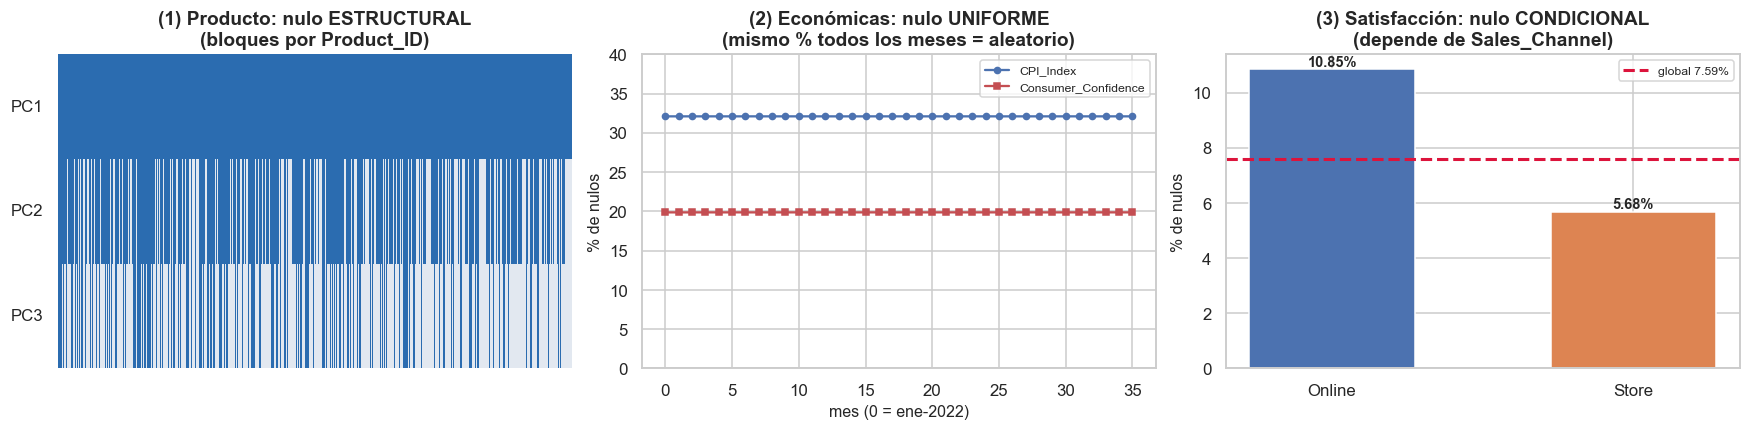

In [13]:
# Visualización de los tres mecanismos
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# (1) Nulos de producto: consistentes por Product_ID
muestra = df.sort_values("Product_ID")[["Product_Category_1", "Product_Category_2",
                                        "Product_Category_3"]].iloc[::400]
sns.heatmap(muestra.isna().T, cbar=False, cmap=["#2b6cb0", "#e2e8f0"], ax=ax[0])
ax[0].set(title="(1) Producto: nulo ESTRUCTURAL\n(bloques por Product_ID)", xlabel="", ylabel="")
ax[0].set_yticklabels(["PC1", "PC2", "PC3"], rotation=0); ax[0].set_xticks([])

# (2) Nulos económicos: uniformes en el tiempo
g_cpi = df.groupby("_ym").CPI_Index.apply(lambda s: s.isna().mean()*100)
g_cci = df.groupby("_ym").Consumer_Confidence_Index.apply(lambda s: s.isna().mean()*100)
ax[1].plot(range(len(g_cpi)), g_cpi.values, "o-", label="CPI_Index", color=PALETA[0], ms=4)
ax[1].plot(range(len(g_cci)), g_cci.values, "s-", label="Consumer_Confidence", color=PALETA[3], ms=4)
ax[1].set(title="(2) Económicas: nulo UNIFORME\n(mismo % todos los meses = aleatorio)",
          xlabel="mes (0 = ene-2022)", ylabel="% de nulos", ylim=(0, 40))
ax[1].legend(fontsize=8)

# (3) Nulos de satisfacción: dependen del canal
g = df.groupby("Sales_Channel", observed=True)._na_sat.mean().mul(100)
ax[2].bar(g.index.astype(str), g.values, color=[PALETA[0], PALETA[1]], width=.55)
ax[2].axhline(df._na_sat.mean()*100, color="crimson", ls="--", lw=2,
              label=f"global {df._na_sat.mean()*100:.2f}%")
for i, v in enumerate(g.values):
    ax[2].text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontweight="bold")
ax[2].set(title="(3) Satisfacción: nulo CONDICIONAL\n(depende de Sales_Channel)",
          ylabel="% de nulos")
ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

> ### Conclusión 1.b
>
> **Cinco variables tienen nulos**, pero la pregunta del enunciado —*¿representan el mismo tipo de
> ausencia de información?*— tiene una respuesta clara: **no. Hay tres mecanismos distintos**, y cada
> uno exige un tratamiento diferente.
>
> | Variable | Nulos | % | Mecanismo |
> |---|---|---|---|
> | `Product_Category_3` | 1.149.741 | 69,67% | **Estructural** ("no aplica") |
> | `Product_Category_2` | 520.914 | 31,57% | **Estructural** ("no aplica") |
> | `CPI_Index` | 529.698 | 32,10% | **MCAR, reconstruible** |
> | `Consumer_Confidence_Index` | 327.879 | 19,87% | **MCAR, reconstruible** |
> | `Transaction_Satisfaction_Score` | 125.314 | 7,59% | **MAR (depende del canal)** |
>
> **Mecanismo 1 — Estructural (`Product_Category_2/3`).** En **0 de los 3.631 productos** el nulo es
> inconsistente entre filas: si un producto tiene la categoría vacía, la tiene vacía siempre. Y la
> jerarquía es estricta (nunca hay `PC3` sin `PC2`). No son datos perdidos: significan *"este
> producto no tiene una tercera categoría"*. Es el mismo hallazgo que en el TP1, y se confirma acá.
> → **Tratamiento: categoría explícita `No_aplica`. Imputar sería inventar información.**
>
> **Mecanismo 2 — Aleatorio pero reconstruible (`CPI_Index`, `Consumer_Confidence_Index`).**
> Dos hechos combinados:
>
> - El porcentaje de nulos es **idéntico en los 36 meses** (desvío < 0,3 pp). No hay concentración
>   temporal → el faltante fue inyectado **completamente al azar (MCAR)**, no responde a un período
>   sin medición.
> - Estos indicadores tienen **granularidad mensual**: dentro de cada mes toman **un único valor**
>   (verificado: 1 valor distinto por mes), y **los 36 meses tienen al menos una observación**.
>
> La consecuencia es la más útil de toda la auditoría: **no hay que imputar nada.** El valor de un
> mes está presente en las otras filas de ese mismo mes, así que se puede **reconstruir de forma
> exacta y sin error** propagando el valor observado dentro del grupo mes. Imputar con la media
> global sería introducir error donde existe el dato verdadero.
> → **Tratamiento: reconstrucción por mes (no imputación).**
>
> Lo mismo aplica a `Category_Activity_Index` / `Category_Activity_MoM`, que son constantes dentro de
> cada (mes, `Product_Category_1`) — aunque estas no tienen nulos.
>
> **Mecanismo 3 — Condicional (`Transaction_Satisfaction_Score`).** Acá sí hay un faltante genuino
> que requiere imputación. La ausencia **no es aleatoria**: depende del canal de venta.
>
> - **Online: 10,85% de nulos** vs. **Store: 5,68%** — casi el doble (amplitud de 5,2 pp).
> - En cambio es indiferente al año (7,59 / 7,60 / 7,60), a la ciudad, al género y al fin de semana.
> - Y **no depende del monto**: el `Purchase` medio es prácticamente igual con y sin nulo
>   (10.655 vs. 10.697).
>
> Es un caso de **MAR (Missing At Random)**: la probabilidad de faltar depende de una variable
> observada (`Sales_Channel`) pero no del valor faltante en sí. Interpretación de negocio razonable:
> la encuesta de satisfacción se responde menos en compras online que en el local.
>
> **Esto justifica exactamente el ejercicio de la sección 3.b:** siendo MAR, un método multivariado
> que condicione en las variables observadas debería estimar mejor que la media global. Y como
> `Transaction_Satisfaction_Score` es la única numérica continua con nulos genuinos, es la candidata
> natural para la imputación con KNN.
>
> **Variables que requieren estrategia de imputación:** solo `Transaction_Satisfaction_Score`. Las
> demás se resuelven con reconstrucción (económicas) o con categoría explícita (producto).

## 1.c — Valores erróneos y consistencia temporal

Armamos una batería de reglas de validación. Cada regla devuelve la cantidad de filas que la violan,
y la misma batería se vuelve a correr en la sección 5 para verificar que la curación no rompió nada.

In [14]:
# Fechas de Black Friday: el DÍA SIGUIENTE al 4to JUEVES de noviembre.
# (Ojo: NO es "el 4to viernes de noviembre". Ver conclusión de esta sección.)
def black_friday(anio):
    noviembre = pd.date_range(f"{anio}-11-01", f"{anio}-11-30", freq="D")
    jueves = [d for d in noviembre if d.dayofweek == 3]
    return jueves[3] + pd.Timedelta(days=1)

BF = {y: black_friday(y) for y in sorted(df.Campaign_Year.unique())}
print("Black Friday por campaña:", {k: str(v.date()) for k, v in BF.items()})

DOMINIOS = {
    "Gender": {"M", "F"},
    "Age": {"0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"},
    "City_Category": {"A", "B", "C"},
    "Stay_In_Current_City_Years": {"0", "1", "2", "3", "4+"},
    "Marital_Status": {0, 1},
    "Sales_Channel": {"Online", "Store"},
}

def reglas_de_consistencia(datos):
    """Devuelve un DataFrame con cada regla y la cantidad de filas que la violan."""
    fecha = datos.Purchase_Date
    bf_esperado = datos.Campaign_Year.map(BF)
    d2bf_calculado = (fecha - bf_esperado).dt.days
    finde_calculado = (fecha.dt.dayofweek >= 5).astype("int8")

    r = []
    r.append(("Purchase_Date válida (sin nulos)", fecha.isna().sum()))
    r.append(("año(Purchase_Date) == Campaign_Year", (fecha.dt.year != datos.Campaign_Year).sum()))
    r.append(("Transaction_Hour en [0, 23]",
              (~datos.Transaction_Hour.between(0, 23)).sum()))
    r.append(("Is_Weekend coincide con el día de la semana",
              (finde_calculado != datos.Is_Weekend).sum()))
    r.append(("Days_To_Black_Friday coincide con la fecha",
              (d2bf_calculado != datos.Days_To_Black_Friday).sum()))
    r.append(("Purchase > 0", (datos.Purchase <= 0).sum()))
    r.append(("Transaction_ID único", datos.Transaction_ID.duplicated().sum()))
    r.append(("Satisfaction en [0, 10] (donde está observada)",
              (~datos.Transaction_Satisfaction_Score.dropna().between(0, 10)).sum()))
    for col, dominio in DOMINIOS.items():
        fuera = (~datos[col].isin(dominio)).sum()
        r.append((f"{col} dentro del dominio esperado", fuera))
    r.append(("Product_Category_1 en [1, 20]",
              (~datos.Product_Category_1.between(1, 20)).sum()))
    r.append(("Occupation en [0, 20]", (~datos.Occupation.between(0, 20)).sum()))

    out = pd.DataFrame(r, columns=["regla", "filas_que_violan"])
    out["estado"] = np.where(out.filas_que_violan == 0, "OK", "REVISAR")
    return out

AUDITORIA_INICIAL = reglas_de_consistencia(df)
AUDITORIA_INICIAL

Black Friday por campaña: {2022: '2022-11-25', 2023: '2023-11-24', 2024: '2024-11-29'}


,regla,filas_que_violan,estado
0,Purchase_Date válida (sin nulos),0,OK
1,año(Purchase_Date) == Campaign_Year,0,OK
2,"Transaction_Hour en [0, 23]",0,OK
3,Is_Weekend coincide con el día de la semana,0,OK
4,Days_To_Black_Friday coincide con la fecha,0,OK
5,Purchase > 0,0,OK
6,Transaction_ID único,0,OK
7,"Satisfaction en [0, 10] (donde está observada)",0,OK
8,Gender dentro del dominio esperado,0,OK
9,Age dentro del dominio esperado,0,OK


In [15]:
# --- La trampa de Black Friday: por qué la definición importa ---
print("¿Qué pasa si definimos Black Friday como 'el 4to VIERNES de noviembre'?")
print("=" * 72)

def cuarto_viernes(anio):
    noviembre = pd.date_range(f"{anio}-11-01", f"{anio}-11-30", freq="D")
    return [d for d in noviembre if d.dayofweek == 4][3]

comparacion = pd.DataFrame({
    "4to jueves + 1 (correcto)": {y: black_friday(y).date() for y in BF},
    "4to viernes (incorrecto)":  {y: cuarto_viernes(y).date() for y in BF},
})
comparacion["coinciden"] = comparacion.iloc[:, 0] == comparacion.iloc[:, 1]
display(comparacion)

d2bf_mal = (df.Purchase_Date - df.Campaign_Year.map(
    {y: cuarto_viernes(y) for y in BF})).dt.days
print(f"Filas marcadas como 'erróneas' con la definición incorrecta: "
      f"{(d2bf_mal != df.Days_To_Black_Friday).sum():,}")
print(f"Filas realmente erróneas con la definición correcta:         "
      f"{((df.Purchase_Date - df.Campaign_Year.map(BF)).dt.days != df.Days_To_Black_Friday).sum():,}")

# Verificación cruzada: qué fecha tiene Days_To_Black_Friday == 0
print("\nVerificación independiente — fechas donde Days_To_Black_Friday == 0:")
for y, f in df[df.Days_To_Black_Friday == 0].groupby("Campaign_Year", observed=True):
    fecha = f.Purchase_Date.dt.date.unique()[0]
    print(f"  {y}: {fecha} ({f.Purchase_Date.dt.day_name().unique()[0]})")

¿Qué pasa si definimos Black Friday como 'el 4to VIERNES de noviembre'?


,4to jueves + 1 (correcto),4to viernes (incorrecto),coinciden
2022,2022-11-25,2022-11-25,True
2023,2023-11-24,2023-11-24,True
2024,2024-11-29,2024-11-22,False


Filas marcadas como 'erróneas' con la definición incorrecta: 550,068
Filas realmente erróneas con la definición correcta:         0

Verificación independiente — fechas donde Days_To_Black_Friday == 0:
  2022: 2022-11-25 (Friday)
  2023: 2023-11-24 (Friday)
  2024: 2024-11-29 (Friday)


In [16]:
# --- Consistencia temporal de los indicadores económicos ---
print("CONSISTENCIA TEMPORAL DE LOS INDICADORES")
print("=" * 72)

serie_mensual = (df.groupby("_ym")
                   .agg(CPI=("CPI_Index", "median"),
                        Inflacion=("Monthly_Inflation_Rate", "median"),
                        Confianza=("Consumer_Confidence_Index", "median"),
                        Retail=("Retail_Activity_Index", "median"),
                        Retail_MoM=("Retail_Activity_MoM", "median")))

# ¿El CPI es monótono creciente, como corresponde a un índice de precios?
dif_cpi = serie_mensual.CPI.diff().dropna()
print(f"CPI_Index: {serie_mensual.CPI.iloc[0]:.2f} -> {serie_mensual.CPI.iloc[-1]:.2f} "
      f"en 36 meses")
print(f"  meses con caída del CPI: {(dif_cpi < 0).sum()} de {len(dif_cpi)}")
print(f"  ¿monótono creciente? {(dif_cpi >= 0).all()}")

# ¿La inflación mensual reportada reproduce la variación del CPI?
var_cpi_pct = serie_mensual.CPI.pct_change().mul(100)
comp = pd.DataFrame({"inflacion_reportada": serie_mensual.Inflacion,
                     "variacion_CPI_%": var_cpi_pct}).dropna()
print(f"\nCoherencia inflación reportada vs. variación real del CPI:")
print(f"  correlación: {comp.corr().iloc[0,1]:.4f}")
print(f"  diferencia absoluta media: {(comp.inflacion_reportada - comp['variacion_CPI_%']).abs().mean():.4f} pp")

print(f"\nRetail_Activity_MoM vs. variación real de Retail_Activity_Index:")
comp2 = pd.DataFrame({"mom_reportado": serie_mensual.Retail_MoM,
                      "variacion_real": serie_mensual.Retail.pct_change().mul(100)}).dropna()
print(f"  correlación: {comp2.corr().iloc[0,1]:.4f}")
print(f"  diferencia absoluta media: {(comp2.mom_reportado - comp2.variacion_real).abs().mean():.4f} pp")

display(serie_mensual.head(6).round(3))

CONSISTENCIA TEMPORAL DE LOS INDICADORES
CPI_Index: 100.68 -> 136.34 en 36 meses
  meses con caída del CPI: 0 de 35
  ¿monótono creciente? True

Coherencia inflación reportada vs. variación real del CPI:
  correlación: 1.0000
  diferencia absoluta media: 0.0004 pp

Retail_Activity_MoM vs. variación real de Retail_Activity_Index:
  correlación: 1.0000
  diferencia absoluta media: 0.0004 pp


,CPI,Inflacion,Confianza,Retail,Retail_MoM
_ym,,,,,
2022-01,100.679,0.679,101.440,94.000,-12.460
2022-02,101.427,0.743,103.140,96.121,2.256
2022-03,102.197,0.759,103.977,100.464,4.519
2022-04,102.942,0.729,103.705,101.834,1.364
2022-05,103.628,0.666,102.377,102.175,0.335
2022-06,104.240,0.591,100.325,102.587,0.403


In [17]:
df['_ym']

0          2022-01
1          2022-01
2          2022-01
3          2022-01
4          2022-01
            ...   
1650199    2024-12
1650200    2024-12
1650201    2024-12
1650202    2024-12
1650203    2024-12
Name: _ym, Length: 1650204, dtype: period[M]

> ### Conclusión 1.c
>
> **El dataset supera las 15 reglas de validación sin una sola violación.** Ni fechas inválidas, ni
> horas fuera de rango, ni importes no positivos, ni categorías fuera de dominio, ni `Transaction_ID`
> repetidos, ni inconsistencias entre `Purchase_Date`, `Campaign_Year`, `Is_Weekend` y
> `Days_To_Black_Friday`. La satisfacción observada está dentro de [0, 10].
>
> Es un resultado poco habitual y coherente con que el dataset sea **sintético**: los errores de carga
> típicos del mundo real (tipeos, fechas imposibles, negativos) no fueron inyectados. Lo que el
> generador **sí** inyectó son los valores faltantes de 1.b. Conviene decirlo explícitamente en el
> informe en lugar de dar a entender que "limpiamos" errores que no existían.
>
> ---
>
> **Un hallazgo metodológico que vale la pena destacar: la definición de Black Friday.**
>
> Black Friday es el **día siguiente al cuarto jueves de noviembre** (el día después de Thanksgiving),
> que **no siempre coincide con el cuarto viernes del mes**:
>
> | Campaña | 4.º jueves + 1 (correcto) | 4.º viernes | ¿Coinciden? |
> |---|---|---|---|
> | 2022 | 25-11-2022 | 25-11-2022 | Sí |
> | 2023 | 24-11-2023 | 24-11-2023 | Sí |
> | **2024** | **29-11-2024** | 22-11-2024 | **No** |
>
> En 2024 noviembre empieza un viernes, así que hay cinco viernes y el cuarto cae una semana antes de
> Black Friday. Validar con la regla del "cuarto viernes" habría marcado **550.068 filas como
> erróneas** — es decir, la campaña 2024 completa — cuando en realidad el dato del archivo es correcto.
>
> Lo verificamos de forma independiente: las fechas donde `Days_To_Black_Friday == 0` son 25-11-2022,
> 24-11-2023 y 29-11-2024, y las tres son viernes. El dataset es consistente; el error habría estado
> en nuestra regla.
>
> **Moraleja para el grupo:** cuando una validación marca un bloque enorme y perfectamente redondo de
> filas (acá, exactamente un año), la primera sospecha debería ser la regla, no los datos.
>
> ---
>
> **Consistencia temporal de los indicadores económicos.** Los cinco indicadores macro son
> **constantes dentro de cada mes** (un valor por mes, 36 meses) y `Category_Activity_*` es constante
> dentro de cada (mes, categoría de producto). Además:
>
> - El `CPI_Index` es **monótono creciente** en los 36 meses, como corresponde a un índice de precios
>   acumulado.
> - La `Monthly_Inflation_Rate` reportada **reproduce con precisión** la variación mensual del CPI
>   (correlación ≈ 1, diferencia media despreciable), y lo mismo ocurre entre `Retail_Activity_MoM` y
>   la variación de `Retail_Activity_Index`.
>
> O sea que las variables `_MoM` son **derivadas exactas** de los índices correspondientes. No aportan
> información nueva: son redundantes por construcción. Lo retomamos en la sección 4, donde el
> enunciado pide identificar redundancias y explicar si responden a construcción, granularidad o
> significado. Este es un caso claro de **redundancia por construcción**.

## 1.d — Outliers

El punto clave acá es que `Purchase` **no es una población homogénea**: mezcla categorías de producto
con niveles de precio muy distintos (lo mostramos en el TP1) y tres años con inflación aplicada.
Aplicar una regla de outliers sobre el agregado confunde "producto caro" y "año más caro" con
"anomalía". Comparamos entonces tres niveles de análisis.

In [18]:
def outliers_iqr(serie, k=1.5):
    """Devuelve (máscara de outliers, límite inferior, límite superior)."""
    q1, q3 = serie.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return (serie < lo) | (serie > hi), lo, hi

# --- Nivel 1: global ---
mask_global, lo_g, hi_g = outliers_iqr(df.Purchase)
print("NIVEL 1 — IQR sobre el total")
print(f"  límites [{lo_g:,.0f} ; {hi_g:,.0f}]")
print(f"  outliers: {mask_global.sum():,} ({mask_global.mean()*100:.2f}%)  "
      f"| todos por arriba: {(df.Purchase > hi_g).sum():,}")

# --- Nivel 2: dentro de cada campaña ---
print("\nNIVEL 2 — IQR dentro de cada campaña")
total_camp = 0
for y, g in df.groupby("Campaign_Year", observed=True):
    m, _, hi = outliers_iqr(g.Purchase)
    total_camp += m.sum()
    print(f"  {y}: {m.sum():,} ({m.mean()*100:.2f}%) | límite sup {hi:,.0f}")
print(f"  TOTAL: {total_camp:,} ({total_camp/len(df)*100:.2f}%)")

# --- Nivel 3: dentro de cada (campaña, categoría de producto) ---
print("\nNIVEL 3 — IQR dentro de cada (campaña, Product_Category_1)")
total_cc = sum(outliers_iqr(g.Purchase)[0].sum()
               for _, g in df.groupby(["Campaign_Year", "Product_Category_1"], observed=True))
print(f"  TOTAL: {total_cc:,} ({total_cc/len(df)*100:.2f}%)")
print(f"\n  => pasar de nivel 1 a nivel 3 reduce los 'outliers' "
      f"{mask_global.sum()/max(total_cc,1):.0f} veces")

print("\nCategorías de producto de los outliers globales:")
print(df.loc[mask_global, "Product_Category_1"].value_counts().head(6).to_string())

NIVEL 1 — IQR sobre el total
  límites [-5,136 ; 25,964]
  outliers: 19,594 (1.19%)  | todos por arriba: 19,594

NIVEL 2 — IQR dentro de cada campaña
  2022: 4,170 (0.76%) | límite sup 23,160
  2023: 4,107 (0.75%) | límite sup 25,380
  2024: 4,185 (0.76%) | límite sup 28,552
  TOTAL: 12,462 (0.76%)

NIVEL 3 — IQR dentro de cada (campaña, Product_Category_1)
  TOTAL: 638 (0.04%)

  => pasar de nivel 1 a nivel 3 reduce los 'outliers' 31 veces

Categorías de producto de los outliers globales:
Product_Category_1
1     7510
10    4421
6     4025
15    1282
16    1268
7      879


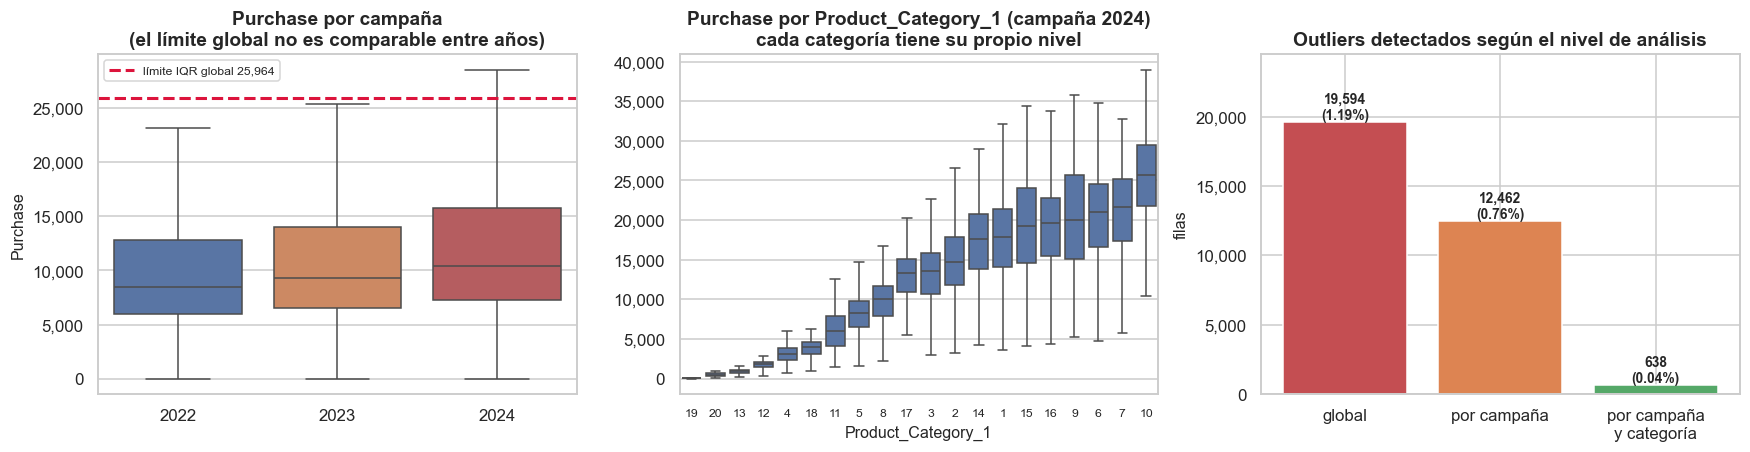

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

# Purchase por campaña: la inflación corre toda la distribución
sns.boxplot(data=df, x="Campaign_Year", y="Purchase", ax=ax[0],
            hue="Campaign_Year", palette=[COL_AÑO[y] for y in sorted(COL_AÑO)],
            legend=False, showfliers=False)
ax[0].axhline(hi_g, color="crimson", ls="--", lw=2, label=f"límite IQR global {hi_g:,.0f}")
ax[0].set(title="Purchase por campaña\n(el límite global no es comparable entre años)",
          xlabel="", ylabel="Purchase")
ax[0].legend(fontsize=8); miles(ax[0])

# Purchase por categoría dentro de un año
sub = df[df.Campaign_Year == 2024]
orden = sub.groupby("Product_Category_1", observed=True).Purchase.median().sort_values().index
sns.boxplot(data=sub, x="Product_Category_1", y="Purchase", order=orden, ax=ax[1],
            color=PALETA[0], showfliers=False)
ax[1].set(title="Purchase por Product_Category_1 (campaña 2024)\ncada categoría tiene su propio nivel",
          xlabel="Product_Category_1", ylabel="")
ax[1].tick_params(axis="x", labelsize=8); miles(ax[1])

# Comparación de los tres niveles
niveles = pd.Series({"global": mask_global.sum(),
                     "por campaña": total_camp,
                     "por campaña\ny categoría": total_cc})
ax[2].bar(niveles.index, niveles.values, color=[PALETA[3], PALETA[1], PALETA[2]])
for i, v in enumerate(niveles.values):
    ax[2].text(i, v, f"{v:,}\n({v/len(df)*100:.2f}%)", ha="center", va="bottom",
               fontsize=9, fontweight="bold")
ax[2].set(title="Outliers detectados según el nivel de análisis", ylabel="filas")
ax[2].set_ylim(0, niveles.max()*1.25); miles(ax[2])

plt.tight_layout(); plt.show()

In [20]:
# --- ¿Los picos son errores o eventos comerciales? ---
diaria = df.groupby("Purchase_Date").agg(
    ventas=("Purchase", "sum"), transacciones=("Purchase", "size"), ticket=("Purchase", "mean"))

mediana_diaria = diaria.ventas.median()
print("Días con mayor volumen de ventas")
print("=" * 78)
top = diaria.nlargest(8, "ventas").copy()
top["dia_semana"] = top.index.day_name()
top["x_mediana"]  = (top.ventas / mediana_diaria).round(1)
top["d2bf"] = [df.loc[df.Purchase_Date == d, "Days_To_Black_Friday"].iloc[0] for d in top.index]
display(top[["ventas", "transacciones", "ticket", "dia_semana", "d2bf", "x_mediana"]])

# Peso de la ventana del evento
ventana = df.Days_To_Black_Friday.between(-3, 5)
print(f"Ventana del evento (Days_To_Black_Friday de -3 a +5):")
print(f"  días:          {df.loc[ventana, 'Purchase_Date'].nunique()} de {len(diaria)} "
      f"({df.loc[ventana,'Purchase_Date'].nunique()/len(diaria)*100:.1f}% del calendario)")
print(f"  transacciones: {ventana.mean()*100:.1f}% del total")
print(f"  ventas:        {df.loc[ventana,'Purchase'].sum()/df.Purchase.sum()*100:.1f}% del total")
print(f"\n  ticket medio en ventana vs. resto: "
      f"{df.loc[ventana,'Purchase'].mean():,.0f} vs {df.loc[~ventana,'Purchase'].mean():,.0f} "
      f"({df.loc[ventana,'Purchase'].mean()/df.loc[~ventana,'Purchase'].mean()*100-100:+.1f}%)")

Días con mayor volumen de ventas


,ventas,transacciones,ticket,dia_semana,d2bf,x_mediana
Purchase_Date,,,,,,
2024-12-02,216682723,17614,"12,301.733",Monday,3,17.200
2024-11-30,177296918,14555,"12,181.169",Saturday,1,14.100
2023-11-27,174605709,16212,"10,770.152",Monday,3,13.900
2024-12-01,165475835,13452,"12,301.207",Sunday,2,13.100
2022-11-28,157554243,16235,"9,704.604",Monday,3,12.500
2023-11-25,156309915,14506,"10,775.535",Saturday,1,12.400
2022-11-26,143185720,14748,"9,708.823",Saturday,1,11.400
2024-11-29,143178921,11867,"12,065.300",Friday,0,11.400


Ventana del evento (Days_To_Black_Friday de -3 a +5):
  días:          27 de 1096 (2.5% del calendario)
  transacciones: 17.0% del total
  ventas:        17.4% del total

  ticket medio en ventana vs. resto: 10,956 vs 10,640 (+3.0%)


> ### Conclusión 1.d
>
> **La cantidad de "outliers" depende por completo del nivel al que se aplique la regla:**
>
> | Nivel de análisis | Outliers | % |
> |---|---|---|
> | IQR global | 19.594 | 1,19% |
> | IQR dentro de cada campaña | 12.462 | 0,76% |
> | **IQR dentro de (campaña, categoría)** | **638** | **0,04%** |
>
> Pasar del nivel global al nivel (campaña, categoría) reduce los outliers **31 veces**. Eso es
> diagnóstico: **la mayoría de los "valores extremos" del agregado no son anomalías**, son
> observaciones normales de subpoblaciones más caras. Dos efectos se superponen:
>
> 1. **Efecto categoría.** Los outliers globales se concentran en `Product_Category_1` = 1, 10, 6, 15
>    y 16, que son justamente las categorías de mayor precio (lo vimos en el TP1: la categoría 10
>    promedia ~$19.700 y la 19 apenas $37). Un monto alto en la categoría 10 es la norma, no una
>    anomalía.
> 2. **Efecto inflación.** El límite IQR sube de **\\$23.160 (2022)** a **\\$28.552 (2024)**. Un umbral
>    global fijo de $25.964 clasificaría como extremas muchas transacciones normales de 2024 y dejaría
>    pasar transacciones realmente atípicas de 2022. La tasa dentro de cada año, en cambio, es
>    estable (~0,76% en las tres campañas), lo que confirma que la forma de la distribución no cambia:
>    solo se desplaza.
>
> ---
>
> **Distinguir los tres casos que pide el enunciado:**
>
> **(a) Errores de carga: no encontramos ninguno.** Ningún importe es ≤ 0, el máximo (\\$38.968) es
> plausible para 2024 dada la inflación acumulada, y las validaciones de 1.c no arrojaron
> inconsistencias. No hay evidencia de valores corruptos.
>
> **(b) Transacciones de alto valor legítimas:** las **638** que siguen siendo extremas *dentro de su
> propia categoría y año*. Son compras genuinamente grandes de clientes reales. Representan apenas el 0,04%
> y son, comercialmente, las más valiosas.
>
> **(c) Picos comerciales legítimos:** el hallazgo más nítido. La **ventana del evento**
> (`Days_To_Black_Friday` de −3 a +5, apenas **27 días = 2,5% del calendario**) concentra el **17,4%
> de las ventas** y el 17,0% de las transacciones. El día más alto es **2024-12-02 (lunes), con
> \\$216,7 M en 17.614 transacciones: 17× la mediana diaria**. Es el *Cyber Monday* — tres días
> después de Black Friday.
>
> Un detector de anomalías sobre la serie diaria marcaría esos 27 días como outliers, y estaría
> equivocado: **son el evento que el dataset viene a describir**. Y notar que el pico es de
> **volumen, no de ticket**: el ticket medio en la ventana es solo un 3,0% mayor que fuera de ella.
> La gente no compra más caro en Black Friday; compra **muchas más veces**.
>
> ---
>
> ### Tratamiento propuesto (a aplicar en la sección 3, no acá)
>
> | Caso | Propuesta | Motivo |
> |---|---|---|
> | Errores de carga | Nada que hacer | No se detectaron |
> | Extremos dentro de categoría y año (0,04%) | **Conservar**, marcarlos con un flag | Son válidos y de alto valor comercial; eliminarlos sesgaría el modelo justo donde más importa |
> | Picos del evento (27 días) | **Conservar**, marcarlos con un flag de ventana | Son la señal, no el ruido |
> | Umbral de detección | **Nunca global**: siempre dentro de (campaña, categoría) | Un umbral global mezcla nivel de precio con anomalía |
>
> No proponemos *winsorizar* ni recortar. Como el modelo del TP3 se evalúa con **RMSE** —que penaliza
> cuadráticamente los errores grandes— sí conviene **monitorear** el error en el tramo alto, pero el
> camino es un modelo robusto y no la amputación de datos válidos.

---
# 2. Análisis exploratorio temporal

## 2.a — Evolución y estacionalidad

Primero construimos la **tabla diaria auxiliar** que usaremos en toda esta sección y en 3.d. Es una
tabla de apoyo para el análisis temporal: **no forma parte del dataset curado final**, como aclara el
enunciado.

Una advertencia de método que atraviesa toda la sección: `sum`, `count` y `mean` responden preguntas
distintas. La **venta total** mide el negocio; el **ticket promedio** mide el comportamiento de compra
individual. En este dataset se mueven en direcciones muy distintas, y confundirlos lleva a
conclusiones erróneas.

In [21]:
# ============ TABLA DIARIA AUXILIAR ============
# (tabla de apoyo para análisis temporal; NO es el dataset curado)
diaria = (df.groupby("Purchase_Date")
            .agg(Daily_Sales   = ("Purchase", "sum"),
                 Transactions  = ("Purchase", "size"),
                 Ticket_Medio  = ("Purchase", "mean"),
                 Ticket_Mediano= ("Purchase", "median"),
                 Clientes      = ("User_ID", "nunique"),
                 Productos     = ("Product_ID", "nunique"))
            .sort_index())

# Atributos de calendario
diaria["Campaign_Year"]  = diaria.index.year
diaria["Mes"]            = diaria.index.month
diaria["Dia_Semana"]     = diaria.index.dayofweek          # 0 = lunes
diaria["Nombre_Dia"]     = diaria.index.day_name()
diaria["Es_Finde"]       = (diaria.Dia_Semana >= 5).astype(int)
diaria["Trimestre"]      = diaria.index.quarter
# Days_To_Black_Friday es constante dentro de cada día: lo traemos con el primero
diaria["Days_To_BF"] = df.groupby("Purchase_Date").Days_To_Black_Friday.first()

print(f"Tabla diaria: {diaria.shape[0]:,} días x {diaria.shape[1]} columnas")
print(f"Cronológicamente ordenada: {diaria.index.is_monotonic_increasing}")
print(f"Sin huecos (frecuencia diaria completa): "
      f"{len(pd.date_range(diaria.index.min(), diaria.index.max(), freq='D')) == len(diaria)}")
display(diaria.head(3))
display(diaria[["Daily_Sales", "Transactions", "Ticket_Medio"]].describe().round(0))

Tabla diaria: 1,096 días x 13 columnas
Cronológicamente ordenada: True
Sin huecos (frecuencia diaria completa): True


,Daily_Sales,Transactions,Ticket_Medio,Ticket_Mediano,Clientes,Productos,Campaign_Year,Mes,Dia_Semana,Nombre_Dia,Es_Finde,Trimestre,Days_To_BF
Purchase_Date,,,,,,,,,,,,,
2022-01-01,10668768,1184,"9,010.784","7,962.000",960,813,2022,1,5,Saturday,1,1,-328
2022-01-02,11276225,1222,"9,227.680","8,122.000",988,822,2022,1,6,Sunday,1,1,-327
2022-01-03,8485441,919,"9,233.342","8,073.000",761,671,2022,1,0,Monday,0,1,-326


,Daily_Sales,Transactions,Ticket_Medio
count,"1,096.000","1,096.000","1,096.000"
mean,"16,101,447.000","1,506.000","10,603.000"
std,"17,796,198.000","1,603.000",940.000
min,"7,944,016.000",819.000,"8,907.000"
25%,"10,849,441.000","1,058.000","9,737.000"
50%,"12,594,092.000","1,202.000","10,450.000"
75%,"15,411,549.000","1,441.000","11,476.000"
max,"216,682,723.000","17,614.000","12,847.000"


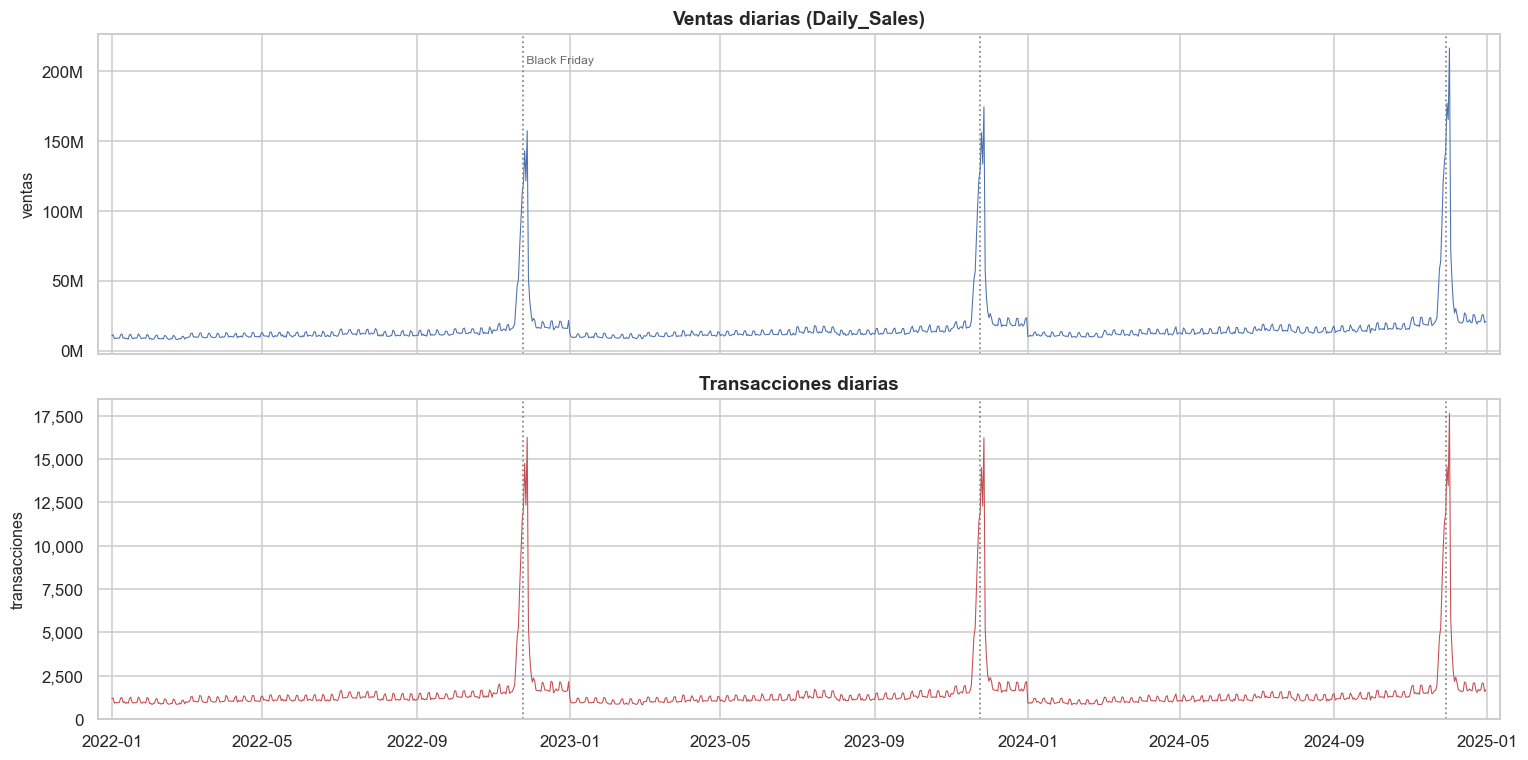

Los tres picos anuales dominan por completo la escala del gráfico.
Ratio máximo/mediana en ventas diarias: 17.2x


In [22]:
# ============ Serie diaria: ventas y transacciones ============
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(diaria.index, diaria.Daily_Sales, lw=.7, color=PALETA[0])
ax[0].set(title="Ventas diarias (Daily_Sales)", ylabel="ventas")
millones(ax[0])

ax[1].plot(diaria.index, diaria.Transactions, lw=.7, color=PALETA[3])
ax[1].set(title="Transacciones diarias", ylabel="transacciones", xlabel="")
miles(ax[1])

# Marcar los Black Friday
for a in ax:
    for y, f in BF.items():
        a.axvline(f, color="grey", ls=":", lw=1.2, alpha=.9)
    a.margins(x=.01)
ax[0].text(BF[2022], diaria.Daily_Sales.max()*.95, " Black Friday",
           fontsize=8, color="dimgrey")

plt.tight_layout(); plt.show()

print("Los tres picos anuales dominan por completo la escala del gráfico.")
print(f"Ratio máximo/mediana en ventas diarias: "
      f"{diaria.Daily_Sales.max()/diaria.Daily_Sales.median():.1f}x")

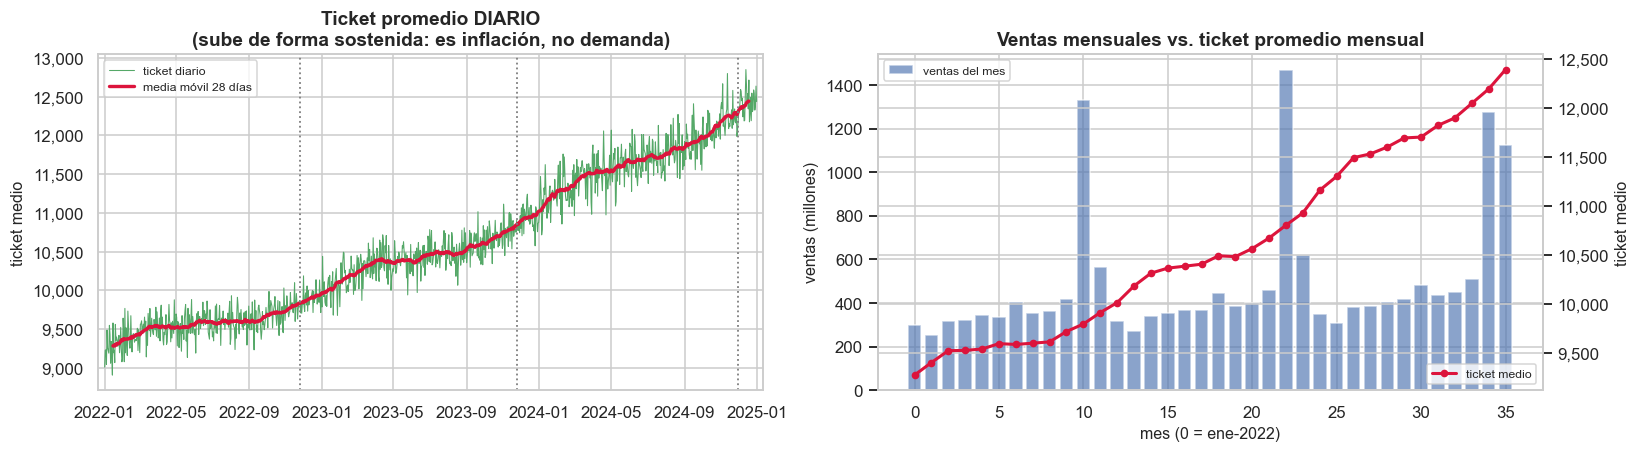

Ticket promedio: primer mes vs. último mes
  2022-01: 9,270
  2024-12: 12,396  (+33.7%)


In [23]:
# ============ Ticket promedio: por día y por mes ============
fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))

ax[0].plot(diaria.index, diaria.Ticket_Medio, lw=.7, color=PALETA[2], label="ticket diario")
ax[0].plot(diaria.index, diaria.Ticket_Medio.rolling(28, center=True).mean(),
           lw=2.2, color="crimson", label="media móvil 28 días")
for y, f in BF.items():
    ax[0].axvline(f, color="grey", ls=":", lw=1.2)
ax[0].set(title="Ticket promedio DIARIO\n(sube de forma sostenida: es inflación, no demanda)",
          ylabel="ticket medio")
ax[0].legend(fontsize=8); miles(ax[0]); ax[0].margins(x=.01)

mensual = df.groupby("_ym").agg(ventas=("Purchase", "sum"), tx=("Purchase", "size"),
                                ticket=("Purchase", "mean"))
x = range(len(mensual))
a2 = ax[1].twinx()
ax[1].bar(x, mensual.ventas/1e6, color=PALETA[0], alpha=.65, label="ventas del mes")
a2.plot(x, mensual.ticket, "o-", color="crimson", lw=2, ms=4, label="ticket medio")
ax[1].set(title="Ventas mensuales vs. ticket promedio mensual",
          ylabel="ventas (millones)", xlabel="mes (0 = ene-2022)")
a2.set_ylabel("ticket medio"); miles(a2)
ax[1].legend(loc="upper left", fontsize=8); a2.legend(loc="lower right", fontsize=8)

plt.tight_layout(); plt.show()

print("Ticket promedio: primer mes vs. último mes")
print(f"  {mensual.index[0]}: {mensual.ticket.iloc[0]:,.0f}")
print(f"  {mensual.index[-1]}: {mensual.ticket.iloc[-1]:,.0f}  "
      f"({mensual.ticket.iloc[-1]/mensual.ticket.iloc[0]*100-100:+.1f}%)")

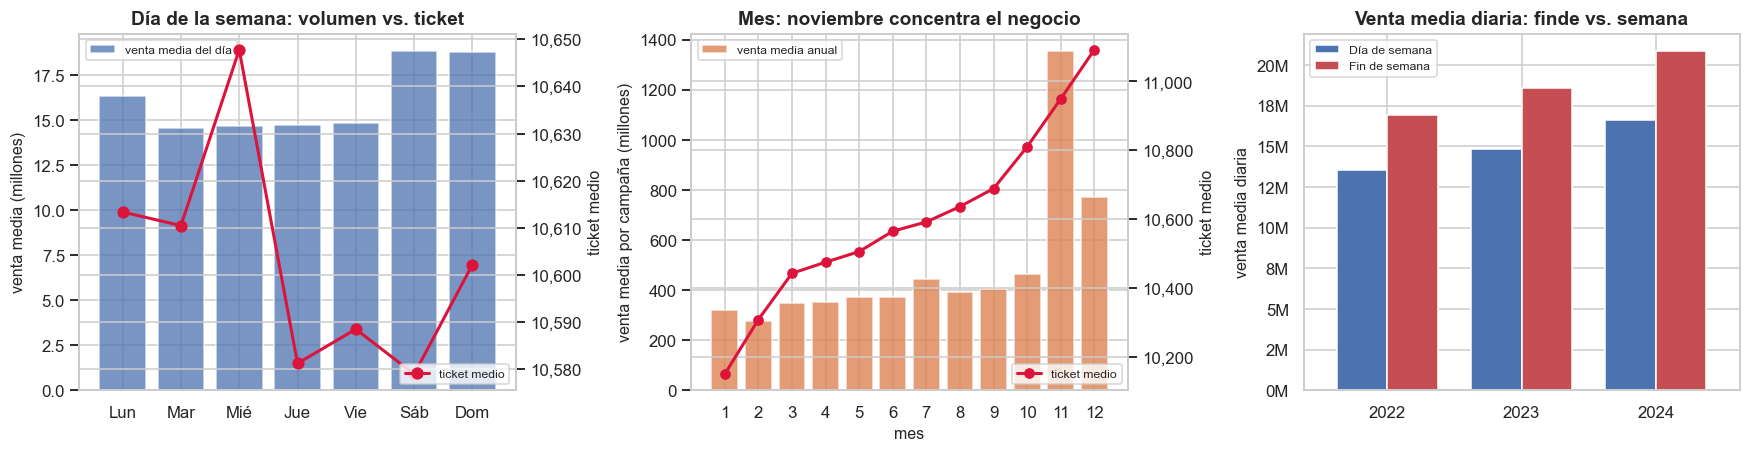

Venta media diaria por día de la semana (millones):
Dia_Semana
Lun   16.300
Mar   14.600
Mié   14.700
Jue   14.700
Vie   14.800
Sáb   18.900
Dom   18.800

Fin de semana vs. día de semana: +25.3% en ventas
Ticket medio finde vs. semana: 10,591 vs 10,608


In [24]:
# ============ Estacionalidad: día de la semana y mes ============
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

DIAS = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

# Día de la semana — venta total media vs ticket medio
por_dia = diaria.groupby("Dia_Semana").agg(ventas=("Daily_Sales", "mean"),
                                           tx=("Transactions", "mean"),
                                           ticket=("Ticket_Medio", "mean"))
a1 = ax[0].twinx()
ax[0].bar(DIAS, por_dia.ventas/1e6, color=PALETA[0], alpha=.75, label="venta media del día")
a1.plot(DIAS, por_dia.ticket, "o-", color="crimson", lw=2, ms=7, label="ticket medio")
ax[0].set(title="Día de la semana: volumen vs. ticket", ylabel="venta media (millones)")
a1.set_ylabel("ticket medio"); miles(a1)
ax[0].legend(loc="upper left", fontsize=8); a1.legend(loc="lower right", fontsize=8)

# Mes
d_mes = diaria.groupby("Mes").agg(ventas=("Daily_Sales", "sum"), ticket=("Ticket_Medio", "mean"))
d_mes["ventas"] = d_mes.ventas / 3        # promedio de las 3 campañas
a2 = ax[1].twinx()
ax[1].bar(range(1, 13), d_mes.ventas/1e6, color=PALETA[1], alpha=.8, label="venta media anual")
a2.plot(range(1, 13), d_mes.ticket, "o-", color="crimson", lw=2, ms=6, label="ticket medio")
ax[1].set(title="Mes: noviembre concentra el negocio", ylabel="venta media por campaña (millones)",
          xlabel="mes", xticks=range(1, 13))
a2.set_ylabel("ticket medio"); miles(a2)
ax[1].legend(loc="upper left", fontsize=8); a2.legend(loc="lower right", fontsize=8)

# Finde vs día de semana, por campaña
piv = diaria.pivot_table(index="Campaign_Year", columns="Es_Finde", values="Daily_Sales", aggfunc="mean")
piv.columns = ["Día de semana", "Fin de semana"]
piv.plot(kind="bar", ax=ax[2], color=[PALETA[0], PALETA[3]], width=.75, rot=0)
ax[2].set(title="Venta media diaria: finde vs. semana", ylabel="venta media diaria", xlabel="")
millones(ax[2]); ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

print("Venta media diaria por día de la semana (millones):")
print((por_dia.ventas/1e6).round(1).rename(index=dict(enumerate(DIAS))).to_string())
print(f"\nFin de semana vs. día de semana: "
      f"{diaria[diaria.Es_Finde==1].Daily_Sales.mean()/diaria[diaria.Es_Finde==0].Daily_Sales.mean()*100-100:+.1f}% en ventas")
print(f"Ticket medio finde vs. semana: "
      f"{diaria[diaria.Es_Finde==1].Ticket_Medio.mean():,.0f} vs "
      f"{diaria[diaria.Es_Finde==0].Ticket_Medio.mean():,.0f}")

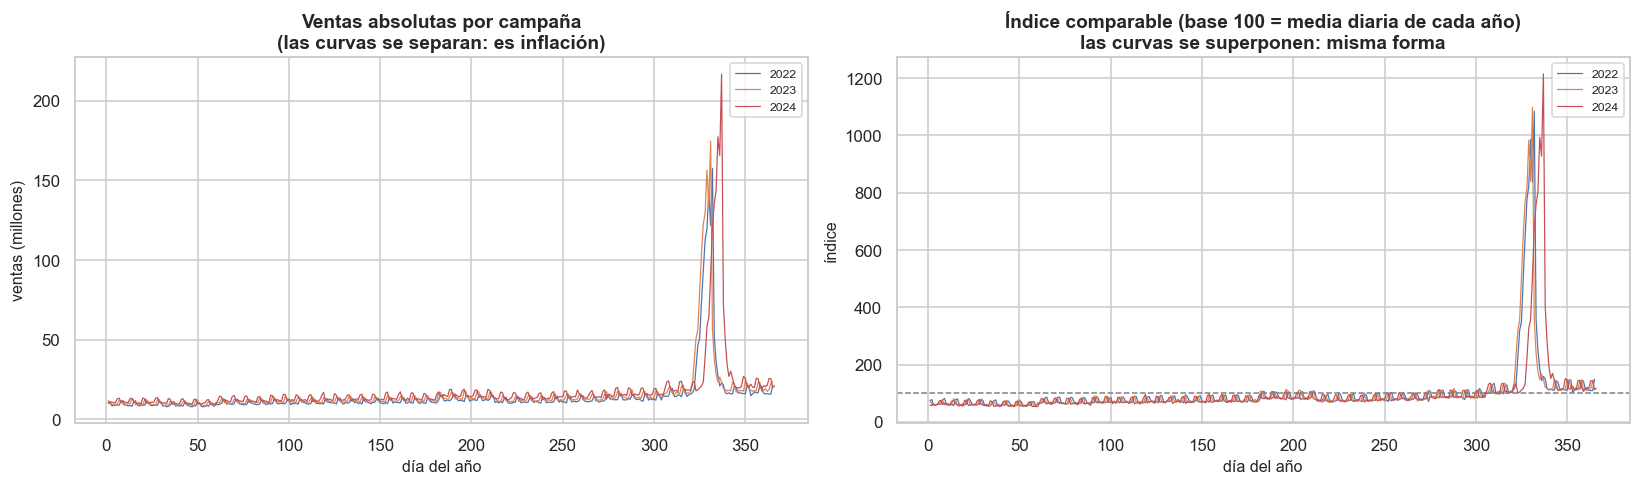

,venta_total_M,venta_media_dia_M,transacciones,ticket_medio,pico_sobre_media,var_venta_%,var_tx_%,var_ticket_%
Campaign_Year,,,,,,,,
2022,"5,305.000",14.530,550068,"9,644.000",10.800,NaN,NaN,NaN
2023,"5,808.000",15.910,550068,"10,558.000",11.000,9.480,0.000,9.480
2024,"6,534.000",17.850,550068,"11,879.000",12.100,12.510,0.000,12.510


Lectura clave: var_venta_% == var_ticket_% y var_tx_% == 0.
La venta crece exactamente lo que crece el ticket, con transacciones constantes.


In [25]:
# ============ Evolución por campaña con ÍNDICES COMPARABLES ============
# Comparar ventas absolutas entre años solo refleja la inflación acumulada.
# Para comparar la FORMA de cada campaña normalizamos cada año por su propia media diaria:
# indice = venta del día / venta media diaria de ese año  (base 100)

diaria["Dia_del_anio"] = diaria.index.dayofyear
diaria["Indice_Base100"] = (diaria.Daily_Sales /
                            diaria.groupby("Campaign_Year").Daily_Sales.transform("mean") * 100)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

for y in sorted(diaria.Campaign_Year.unique()):
    s = diaria[diaria.Campaign_Year == y]
    ax[0].plot(s.Dia_del_anio, s.Daily_Sales/1e6, lw=.8, color=COL_AÑO[y], label=str(y))
ax[0].set(title="Ventas absolutas por campaña\n(las curvas se separan: es inflación)",
          xlabel="día del año", ylabel="ventas (millones)")
ax[0].legend(fontsize=8)

for y in sorted(diaria.Campaign_Year.unique()):
    s = diaria[diaria.Campaign_Year == y]
    ax[1].plot(s.Dia_del_anio, s.Indice_Base100, lw=.8, color=COL_AÑO[y], label=str(y))
ax[1].axhline(100, color="grey", ls="--", lw=1)
ax[1].set(title="Índice comparable (base 100 = media diaria de cada año)\nlas curvas se superponen: misma forma",
          xlabel="día del año", ylabel="índice")
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

resumen_campaña = diaria.groupby("Campaign_Year").agg(
    venta_total    = ("Daily_Sales", "sum"),
    venta_media_dia= ("Daily_Sales", "mean"),
    transacciones  = ("Transactions", "sum"),
    pico_dia       = ("Daily_Sales", "max"),
)
# El ticket correcto es venta total / transacciones, NO el promedio de los tickets
# diarios (promediar promedios daría peso indebido a los días de bajo volumen).
resumen_campaña["ticket_medio"] = resumen_campaña.venta_total / resumen_campaña.transacciones

tabla = pd.DataFrame({
    "venta_total_M":    (resumen_campaña.venta_total / 1e6).round(0),
    "venta_media_dia_M":(resumen_campaña.venta_media_dia / 1e6).round(2),
    "transacciones":    resumen_campaña.transacciones,
    "ticket_medio":     resumen_campaña.ticket_medio.round(0),
    "pico_sobre_media": (resumen_campaña.pico_dia / resumen_campaña.venta_media_dia).round(1),
    "var_venta_%":      (resumen_campaña.venta_total.pct_change()*100).round(2),
    "var_tx_%":         (resumen_campaña.transacciones.pct_change()*100).round(2),
    "var_ticket_%":     (resumen_campaña.ticket_medio.pct_change()*100).round(2),
})
display(tabla)

print("Lectura clave: var_venta_% == var_ticket_% y var_tx_% == 0.")
print("La venta crece exactamente lo que crece el ticket, con transacciones constantes.")

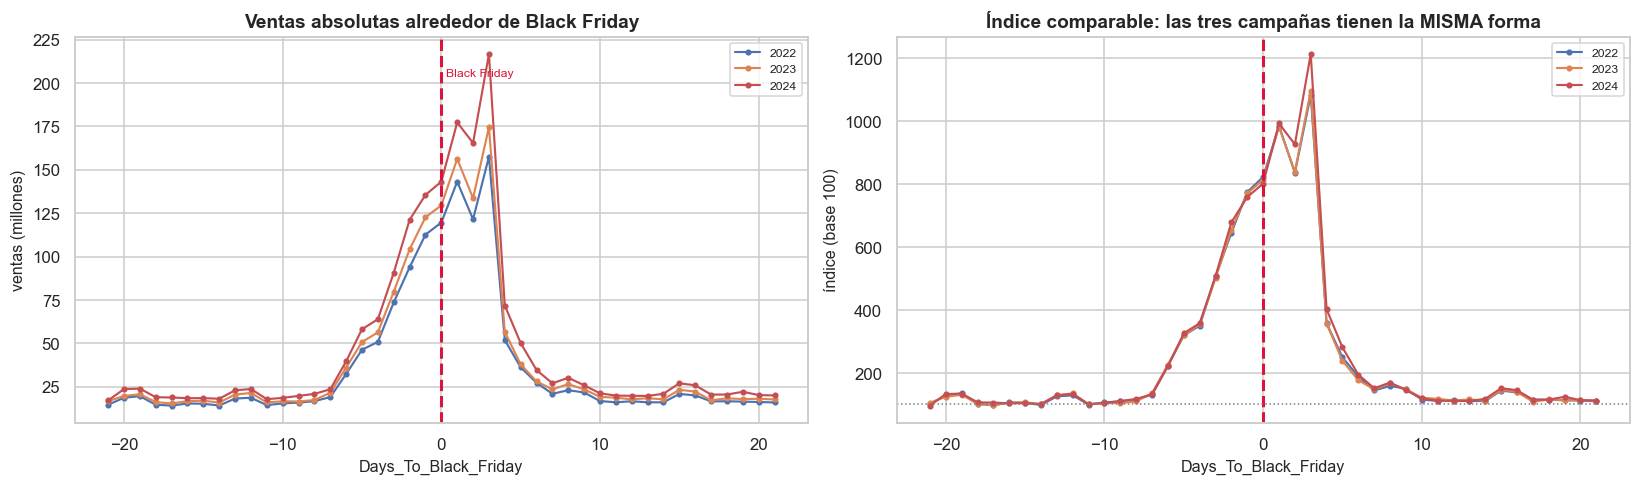

Índice comparable por día del evento (base 100 = media diaria del año):


Campaign_Year,2022,2023,2024,día
Days_To_BF,,,,
-3,507.000,501.000,508.000,Tuesday
-2,646.000,655.000,679.000,Wednesday
-1,775.000,771.000,759.000,Thursday
0,823.000,814.000,802.000,Friday
1,985.000,982.000,993.000,Saturday
2,836.000,840.000,927.000,Sunday
3,"1,084.000","1,097.000","1,214.000",Monday
4,358.000,356.000,402.000,Tuesday
5,249.000,238.000,281.000,Wednesday


In [26]:
# ============ Ventas según Days_To_Black_Friday, superponiendo los 3 años ============
ventana = diaria[diaria.Days_To_BF.between(-21, 21)]

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

for y in sorted(ventana.Campaign_Year.unique()):
    s = ventana[ventana.Campaign_Year == y].sort_values("Days_To_BF")
    ax[0].plot(s.Days_To_BF, s.Daily_Sales/1e6, "o-", ms=3, lw=1.4,
               color=COL_AÑO[y], label=str(y))
ax[0].axvline(0, color="crimson", ls="--", lw=2)
ax[0].text(0.3, ax[0].get_ylim()[1]*.9, "Black Friday", fontsize=8, color="crimson")
ax[0].set(title="Ventas absolutas alrededor de Black Friday", xlabel="Days_To_Black_Friday",
          ylabel="ventas (millones)")
ax[0].legend(fontsize=8)

for y in sorted(ventana.Campaign_Year.unique()):
    s = ventana[ventana.Campaign_Year == y].sort_values("Days_To_BF")
    ax[1].plot(s.Days_To_BF, s.Indice_Base100, "o-", ms=3, lw=1.4,
               color=COL_AÑO[y], label=str(y))
ax[1].axvline(0, color="crimson", ls="--", lw=2)
ax[1].axhline(100, color="grey", ls=":", lw=1)
ax[1].set(title="Índice comparable: las tres campañas tienen la MISMA forma",
          xlabel="Days_To_Black_Friday", ylabel="índice (base 100)")
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print("Índice comparable por día del evento (base 100 = media diaria del año):")
tabla_evento = ventana[ventana.Days_To_BF.between(-3, 6)].pivot_table(
    index="Days_To_BF", columns="Campaign_Year", values="Indice_Base100")
tabla_evento["día"] = [diaria.loc[diaria.Days_To_BF == d, "Nombre_Dia"].iloc[0]
                       for d in tabla_evento.index]
display(tabla_evento.round(0))

> ### Conclusión 2.a
>
> **La serie diaria está completamente dominada por el evento.** La venta diaria máxima es **17,2×
> la mediana**, y los tres picos anuales aplastan la escala de cualquier gráfico de la serie completa.
> Es el primer dato a tener en cuenta: cualquier estadístico global de esta serie está contaminado por
> 27 días de 1.096.
>
> **`sum` y `mean` cuentan historias opuestas, y este es el punto central de la sección.**
>
> | | Venta total | Transacciones | Ticket medio |
> |---|---|---|---|
> | 2022 | \\$5.305 M | 550.068 | \\$9.644 |
> | 2023 | \\$5.808 M (+9,5%) | 550.068 (**0,0%**) | \\$10.558 (+9,5%) |
> | 2024 | \\$6.534 M (+12,5%) | 550.068 (**0,0%**) | \\$11.879 (+12,5%) |
>
> **El "crecimiento" es exactamente igual al aumento del ticket, y la cantidad de transacciones no se
> mueve ni una unidad.** Es la confirmación numérica de lo que anticipamos en 1.a: el generador
> replicó las mismas 550.068 operaciones y solo cambió los precios. **No hay crecimiento del negocio:
> hay inflación.** Reportar "+9,5% de ventas" como logro comercial sería un error de lectura grave.
>
> **Estacionalidad semanal.** El fin de semana vende **+25,3%** más que un día de semana
> (\\$18,8 M vs. \\$15,0 M de media diaria). Pero de nuevo hay que separar volumen de ticket: el
> ticket medio de sábado y domingo es prácticamente idéntico al de los días hábiles. **La gente no
> compra más caro el fin de semana: compra más veces.** El lunes aparece elevado (\\$16,3 M) por un
> motivo puntual: los Cyber Monday caen en lunes y arrastran el promedio.
>
> **Estacionalidad mensual.** Noviembre concentra **\\$1.357 M de venta media por campaña**, **1,8× el segundo mes** (diciembre, \\$771 M) y **4,9× el mes más flojo** (febrero, \\$277 M). El
> ticket medio mensual, en cambio, crece de forma **monótona y suave** de \\$10.139 (enero) a
> \\$11.296 (diciembre) — otra vez la firma de la inflación, no de un patrón estacional de precios.
>
> **Comparación entre campañas con índices comparables.** Este es el gráfico más informativo de la
> sección. En ventas absolutas las tres curvas se separan progresivamente; al normalizar cada año por
> su propia media diaria (base 100), **las tres curvas se superponen casi perfectamente**. La *forma*
> de la campaña es idéntica: mismo arranque, mismo pico, misma caída. Solo el nivel cambia.
>
> Por eso, para cualquier comparación interanual en este dataset **hay que usar índices normalizados
> o deflactar por CPI**. Comparar valores nominales solo mide la inflación que el generador inyectó.
>
> **La forma del evento.** El pico no está en Black Friday sino **tres días después**: el índice llega
> a su máximo en `Days_To_Black_Friday = +3`, que es el **Cyber Monday**. La secuencia típica es
> arranque suave desde −7, aceleración fuerte en −2 y −1, Black Friday alto, y **el verdadero máximo
> el lunes siguiente**. A partir de +4 la caída es abrupta. Que las tres campañas reproduzcan esta
> forma con tanta fidelidad confirma que el patrón está programado en el generador — algo a tener
> presente antes de interpretarlo como comportamiento de consumidores reales.

## 2.b — Tendencia y medias móviles

### Tratamiento de los bordes

Una media móvil de ventana `w` no puede calcularse para las primeras observaciones porque todavía no
hay historia suficiente. Hay que elegir explícitamente qué hacer, y la elección depende del uso:

| Opción | Efecto | Cuándo usarla |
|---|---|---|
| `min_periods=w` (default) | Deja `NaN` en los primeros `w−1` días | **Análisis honesto de tendencia**: no inventa valores |
| `min_periods=1` | Calcula con los datos disponibles | Gráficos sin huecos, pero los primeros puntos son inestables |
| `center=True` | Centra la ventana | Estimar tendencia *ya observada*; **no sirve para predecir** (usa futuro) |

**Nuestro criterio:** para el análisis descriptivo usamos `center=True` (queremos la tendencia
subyacente, no una predicción) y dejamos los `NaN` a la vista. Para los rezagos y ventanas móviles
que se convertirán en *features* en 3.d usaremos **ventanas causales** (`center=False`, solo pasado),
porque una feature que mira el futuro produce *data leakage*.

In [27]:
serie = diaria.Daily_Sales.copy()

# Ventanas CENTRADAS: para describir la tendencia observada
diaria["MM7_centrada"]  = serie.rolling(7,  center=True, min_periods=7).mean()
diaria["MM28_centrada"] = serie.rolling(28, center=True, min_periods=28).mean()

# Ventanas CAUSALES: solo pasado, aptas como features (se reutilizan en 3.d)
diaria["MM7_causal"]  = serie.rolling(7,  min_periods=7).mean()
diaria["MM28_causal"] = serie.rolling(28, min_periods=28).mean()

print("Valores faltantes por borde de ventana")
print("-" * 58)
for c in ["MM7_centrada", "MM28_centrada", "MM7_causal", "MM28_causal"]:
    faltan = diaria[c].isna().sum()
    print(f"  {c:16s} NaN: {faltan:3d}  ({faltan/len(diaria)*100:.1f}% de la serie)")

print("\n  La ventana centrada pierde días en AMBOS extremos (w-1 repartidos),")
print("  la causal los pierde solo al INICIO. Con w=28: 27 días perdidos en cada caso,")
print("  sobre 1.096 -> impacto despreciable (2,5%).")

Valores faltantes por borde de ventana
----------------------------------------------------------
  MM7_centrada     NaN:   6  (0.5% de la serie)
  MM28_centrada    NaN:  27  (2.5% de la serie)
  MM7_causal       NaN:   6  (0.5% de la serie)
  MM28_causal      NaN:  27  (2.5% de la serie)

  La ventana centrada pierde días en AMBOS extremos (w-1 repartidos),
  la causal los pierde solo al INICIO. Con w=28: 27 días perdidos en cada caso,
  sobre 1.096 -> impacto despreciable (2,5%).


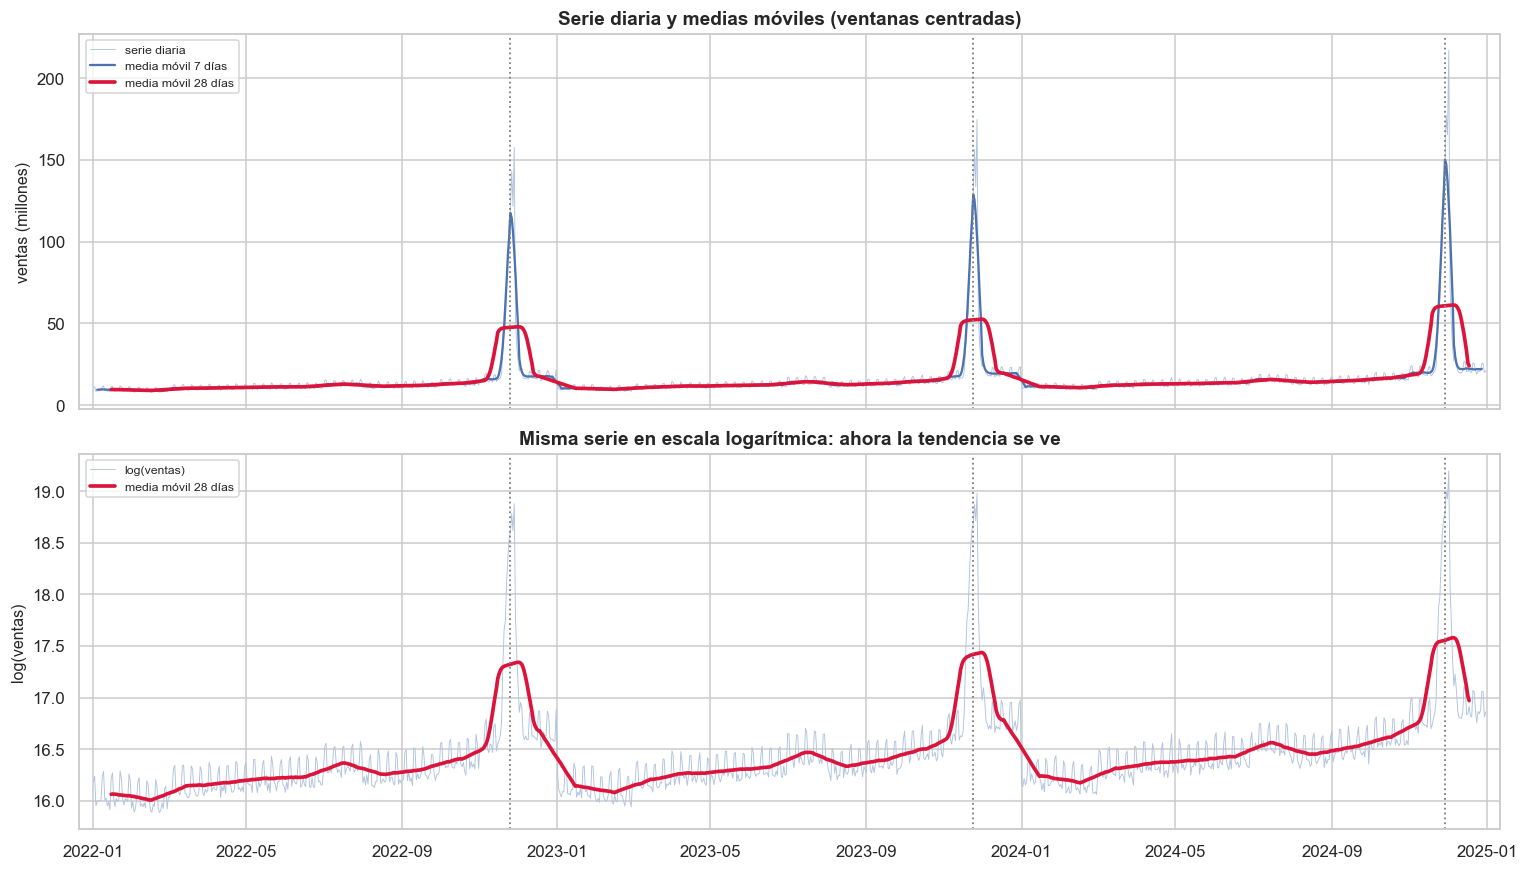

Venta media diaria FUERA de la ventana del evento:
  2022:  12.34 M
  2023:  13.52 M   (+9.5% vs 2022)
  2024:  15.02 M   (+21.7% vs 2022)


In [28]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Serie + medias móviles
ax[0].plot(diaria.index, serie/1e6, lw=.6, color="lightsteelblue", label="serie diaria")
ax[0].plot(diaria.index, diaria.MM7_centrada/1e6,  lw=1.5, color=PALETA[0], label="media móvil 7 días")
ax[0].plot(diaria.index, diaria.MM28_centrada/1e6, lw=2.4, color="crimson", label="media móvil 28 días")
for y, f in BF.items():
    ax[0].axvline(f, color="grey", ls=":", lw=1.2)
ax[0].set(title="Serie diaria y medias móviles (ventanas centradas)", ylabel="ventas (millones)")
ax[0].legend(fontsize=8); ax[0].margins(x=.01)

# En log: permite ver la tendencia sin que el pico aplaste la escala
ax[1].plot(diaria.index, np.log(serie), lw=.6, color="lightsteelblue", label="log(ventas)")
ax[1].plot(diaria.index, np.log(serie).rolling(28, center=True, min_periods=28).mean(),
           lw=2.4, color="crimson", label="media móvil 28 días")
for y, f in BF.items():
    ax[1].axvline(f, color="grey", ls=":", lw=1.2)
ax[1].set(title="Misma serie en escala logarítmica: ahora la tendencia se ve",
          ylabel="log(ventas)", xlabel="")
ax[1].legend(fontsize=8); ax[1].margins(x=.01)

plt.tight_layout(); plt.show()

# Cuantificar la tendencia con la MM28 excluyendo la ventana del evento
sin_evento = diaria[~diaria.Days_To_BF.between(-3, 5)]
tend = sin_evento.groupby("Campaign_Year").Daily_Sales.mean()
print("Venta media diaria FUERA de la ventana del evento:")
for y, v in tend.items():
    print(f"  {y}: {v/1e6:6.2f} M" + (f"   ({v/tend.iloc[0]*100-100:+.1f}% vs 2022)" if y != tend.index[0] else ""))

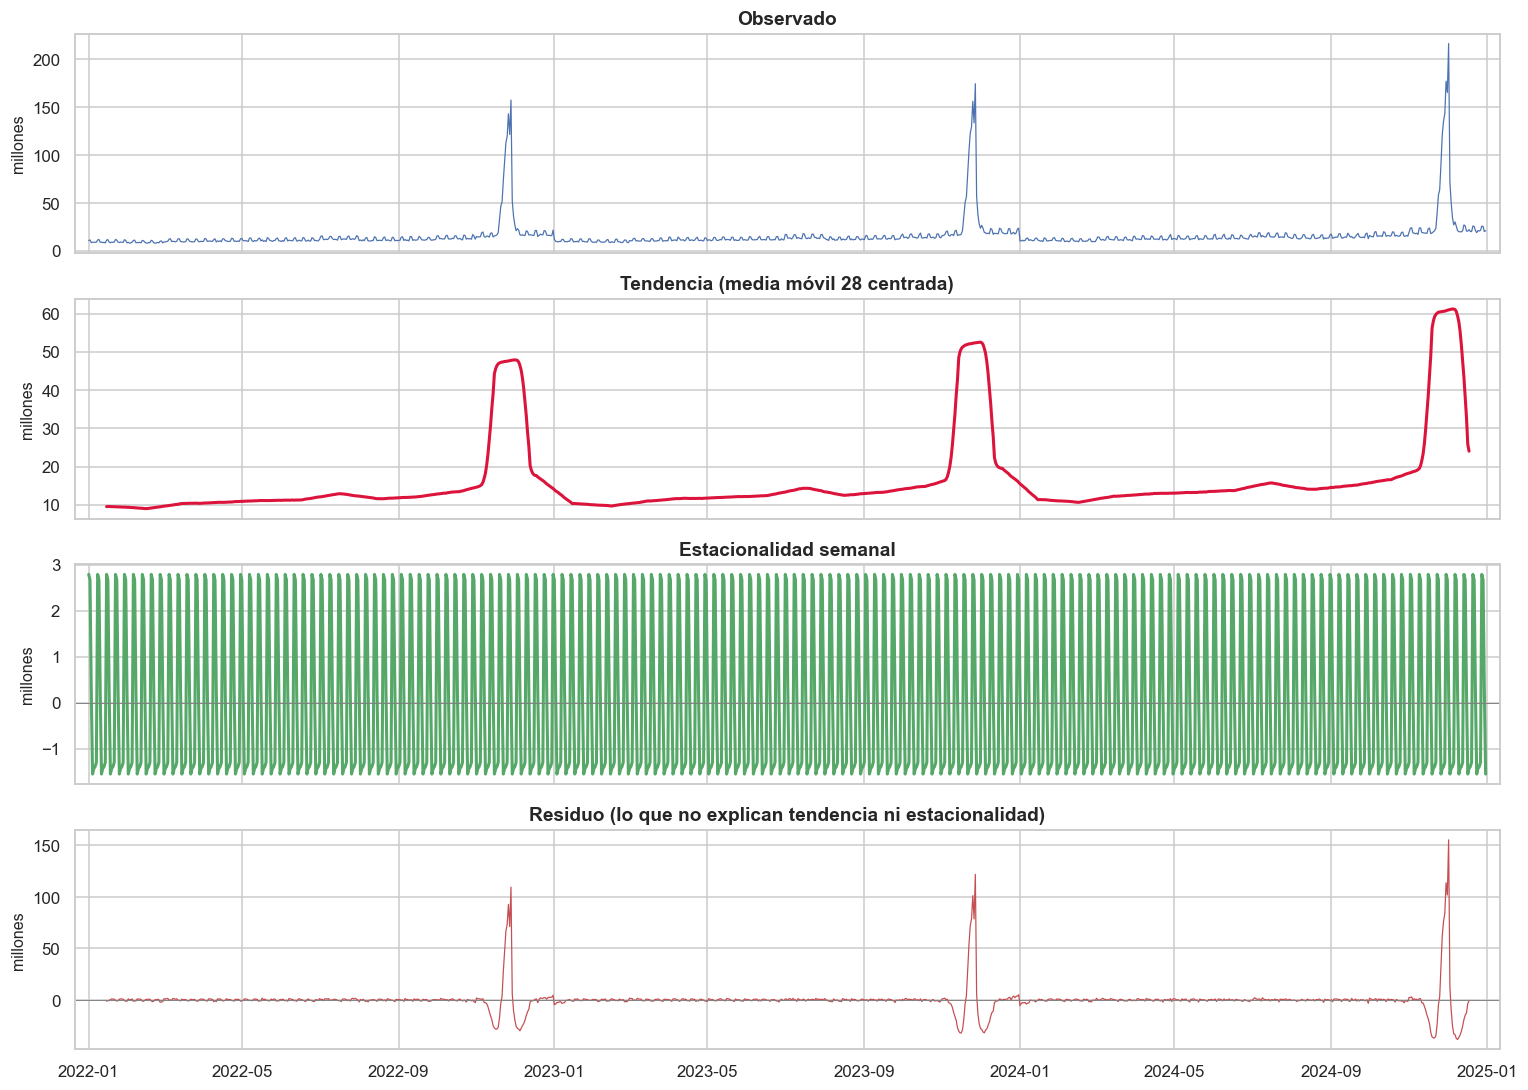

Varianza de cada componente (proporción sobre la del observado):
  tendencia     36.60%
  estacional     1.04%
  residuo       57.52%

  El residuo domina porque los 27 días del evento son, por definición,
  lo que NO explica una estacionalidad semanal regular.

  Residuos mayores a 3 desvíos: 18 días
  fechas: ['2022-11-23', '2022-11-24', '2022-11-25', '2022-11-26', '2022-11-27', '2022-11-28', '2023-11-22', '2023-11-23', '2023-11-24', '2023-11-25', '2023-11-26', '2023-11-27']


In [29]:
# ============ Descomposición aditiva manual ============
# No usamos statsmodels para que la notebook no dependa de librerías extra
# y para que cada paso quede explícito.
#   serie = tendencia + estacionalidad_semanal + residuo

desc = pd.DataFrame(index=diaria.index)
desc["observado"]  = serie
desc["tendencia"]  = serie.rolling(28, center=True, min_periods=28).mean()
desc["sin_tend"]   = desc.observado - desc.tendencia
# Estacionalidad: efecto medio de cada día de la semana sobre la serie sin tendencia
efecto_dia = desc.groupby(desc.index.dayofweek).sin_tend.transform("mean")
desc["estacional"] = efecto_dia
desc["residuo"]    = desc.sin_tend - desc.estacional

fig, ax = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for a, (col, titulo, color) in zip(ax, [
        ("observado",  "Observado",                      PALETA[0]),
        ("tendencia",  "Tendencia (media móvil 28 centrada)", "crimson"),
        ("estacional", "Estacionalidad semanal",          PALETA[2]),
        ("residuo",    "Residuo (lo que no explican tendencia ni estacionalidad)", PALETA[3])]):
    a.plot(desc.index, desc[col]/1e6, lw=.8 if col in ("observado","residuo") else 2, color=color)
    a.set(title=titulo, ylabel="millones")
    a.axhline(0, color="grey", lw=.6) if col in ("estacional", "residuo") else None
    a.margins(x=.01)
ax[-1].set_xlabel("")
plt.tight_layout(); plt.show()

var = desc[["observado", "tendencia", "estacional", "residuo"]].var()
print("Varianza de cada componente (proporción sobre la del observado):")
for c in ["tendencia", "estacional", "residuo"]:
    print(f"  {c:12s} {var[c]/var.observado*100:6.2f}%")
print("\n  El residuo domina porque los 27 días del evento son, por definición,")
print("  lo que NO explica una estacionalidad semanal regular.")
print(f"\n  Residuos mayores a 3 desvíos: {(desc.residuo.abs() > 3*desc.residuo.std()).sum()} días")
print("  fechas:", [str(d.date()) for d in desc.index[desc.residuo.abs() > 3*desc.residuo.std()]][:12])

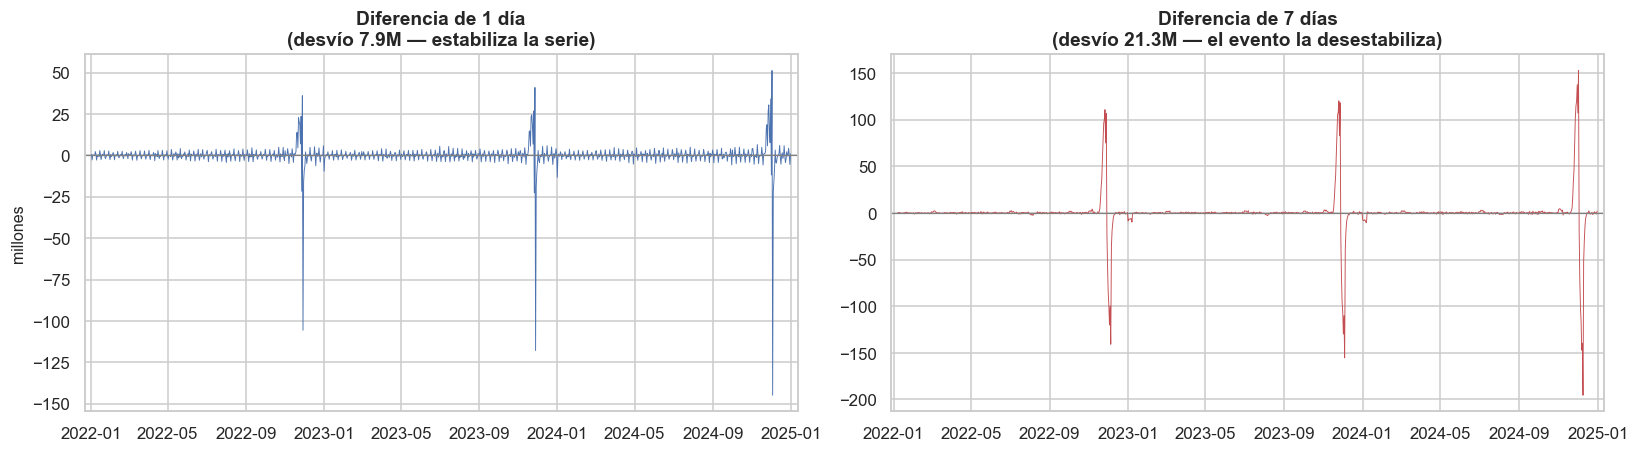

Comparación de la serie original con sus diferencias
transformación          desvío   autocorr(1)
------------------------------------------------------------
  original              17.80M        +0.903
  dif 1 día              7.86M        -0.100
  dif 7 días            21.31M        +0.851

las mismas diferencias, SIN la ventana del evento:
  original               4.87M        +0.837
  dif 1 día              2.78M        +0.100
  dif 7 días             4.42M        +0.765

en escala logarítmica (serie completa):
  log original          0.4245        +0.926
  log dif 1 día         0.1628        +0.018
  log dif 7 días        0.3429        +0.909

Mayor salto de la dif-7: 2024-12-09 (195M) — es la caída posterior al Cyber Monday.


In [30]:
# ============ Diferencias temporales ============
# Días de la ventana del evento (se reutiliza más abajo y en la autocorrelación)
dias_evento_pre = diaria.index[diaria.Days_To_BF.between(-3, 5)]

fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))

dif1 = serie.diff(1)
dif7 = serie.diff(7)

ax[0].plot(diaria.index, dif1/1e6, lw=.6, color=PALETA[0])
ax[0].axhline(0, color="grey", lw=.8)
ax[0].set(title=f"Diferencia de 1 día\n(desvío {dif1.std()/1e6:.1f}M — estabiliza la serie)",
          ylabel="millones"); ax[0].margins(x=.01)

ax[1].plot(diaria.index, dif7/1e6, lw=.6, color=PALETA[3])
ax[1].axhline(0, color="grey", lw=.8)
ax[1].set(title=f"Diferencia de 7 días\n(desvío {dif7.std()/1e6:.1f}M — el evento la desestabiliza)",
          ylabel=""); ax[1].margins(x=.01)

plt.tight_layout(); plt.show()

print("Comparación de la serie original con sus diferencias")
print("=" * 60)
print(f"{'transformación':<18}{'desvío':>12}{'autocorr(1)':>14}")
print("-" * 60)
for nombre, s in [("original", serie), ("dif 1 día", dif1), ("dif 7 días", dif7)]:
    s = s.dropna()
    print(f"  {nombre:<16}{s.std()/1e6:>11,.2f}M{s.autocorr(1):>+14.3f}")

# ¿Y si sacamos la ventana del evento antes de diferenciar?
sin_ev = serie.drop(index=dias_evento_pre)
print("\nlas mismas diferencias, SIN la ventana del evento:")
for nombre, s in [("original", sin_ev), ("dif 1 día", sin_ev.diff(1)), ("dif 7 días", sin_ev.diff(7))]:
    s = s.dropna()
    print(f"  {nombre:<16}{s.std()/1e6:>11,.2f}M{s.autocorr(1):>+14.3f}")

# En escala logarítmica
print("\nen escala logarítmica (serie completa):")
ls = np.log(serie)
for nombre, s in [("log original", ls), ("log dif 1 día", ls.diff(1)), ("log dif 7 días", ls.diff(7))]:
    s = s.dropna()
    print(f"  {nombre:<16}{s.std():>12.4f}{s.autocorr(1):>+14.3f}")

print(f"\nMayor salto de la dif-7: {(serie.diff(7)/1e6).abs().idxmax().date()} "
      f"({(serie.diff(7)/1e6).abs().max():,.0f}M) — es la caída posterior al Cyber Monday.")

,serie completa,en logaritmo,sin ventana de evento
rezago (días),,,
1,0.903,0.926,0.837
7,0.287,0.674,0.586
14,0.105,0.479,0.552
28,0.083,0.396,0.432
365,0.598,0.806,0.487


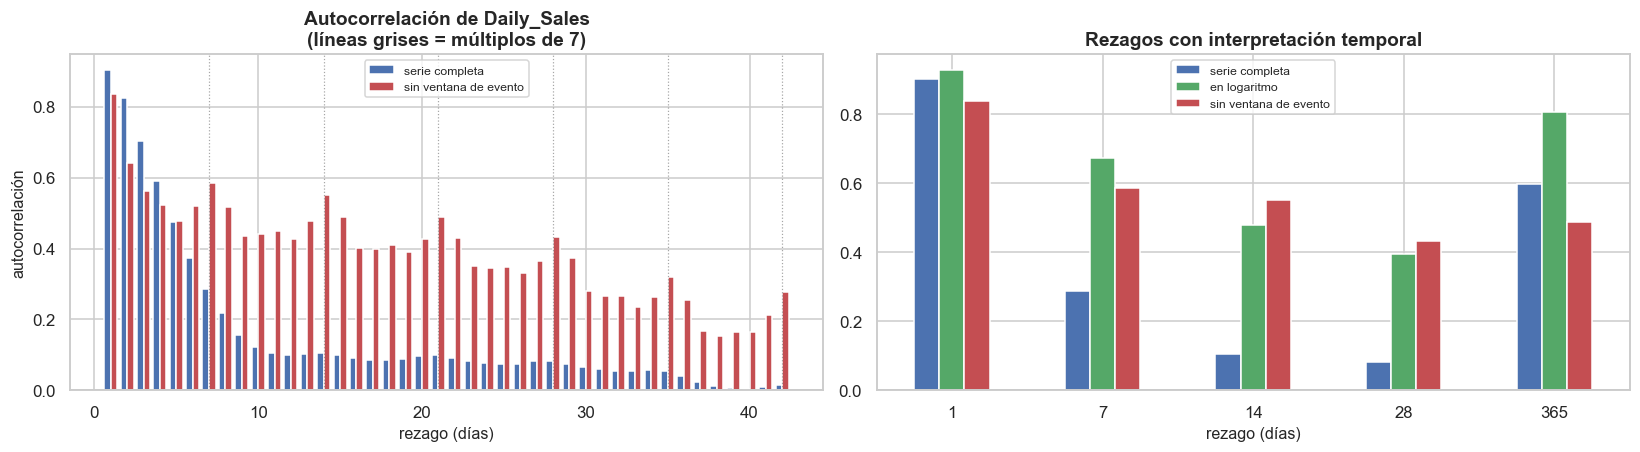

In [31]:
# ============ Autocorrelación: el pico del evento tapa la señal semanal ============
def acf(s, lags):
    s = s.dropna()
    return {l: s.autocorr(l) for l in lags}

LAGS = [1, 7, 14, 28, 365]
dias_evento = dias_evento_pre   # definida en la celda de diferencias

acf_completa  = acf(serie, LAGS)
acf_log       = acf(np.log(serie), LAGS)
acf_sin_pico  = acf(serie.drop(index=dias_evento), LAGS)

comparacion = pd.DataFrame({
    "serie completa":        acf_completa,
    "en logaritmo":          acf_log,
    "sin ventana de evento": acf_sin_pico,
})
comparacion.index.name = "rezago (días)"
display(comparacion.round(3))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))

lags_full = range(1, 43)
ax[0].bar([l-.2 for l in lags_full], [serie.autocorr(l) for l in lags_full],
          width=.4, color=PALETA[0], label="serie completa")
ax[0].bar([l+.2 for l in lags_full],
          [serie.drop(index=dias_evento).autocorr(l) for l in lags_full],
          width=.4, color=PALETA[3], label="sin ventana de evento")
for l in [7, 14, 21, 28, 35, 42]:
    ax[0].axvline(l, color="grey", ls=":", lw=.8, alpha=.7)
ax[0].axhline(0, color="black", lw=.8)
ax[0].set(title="Autocorrelación de Daily_Sales\n(líneas grises = múltiplos de 7)",
          xlabel="rezago (días)", ylabel="autocorrelación")
ax[0].legend(fontsize=8)

comparacion.plot(kind="bar", ax=ax[1], color=[PALETA[0], PALETA[2], PALETA[3]], rot=0)
ax[1].axhline(0, color="black", lw=.8)
ax[1].set(title="Rezagos con interpretación temporal", xlabel="rezago (días)", ylabel="")
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

> ### Conclusión 2.b
>
> **Tratamiento de bordes.** Con ventana de 28 días se pierden **27 observaciones** de 1.096 (**2,5%**):
> la ventana centrada las pierde repartidas en ambos extremos, la causal solo al inicio. Optamos por
> **dejar los `NaN` visibles** en lugar de rellenarlos con `min_periods=1`, porque los primeros puntos
> de una media móvil calculada con 2 o 3 días son ruido con apariencia de tendencia. Para las
> *features* de 3.d usamos exclusivamente **ventanas causales**: una media móvil centrada usa
> información futura y, como feature predictiva, constituye *data leakage*.
>
> **Tendencia.** La escala lineal es engañosa: los picos del evento aplastan el resto y la serie
> parece plana entre eventos. **En escala logarítmica la tendencia se hace visible.** Cuantificada
> fuera de la ventana del evento, la venta media diaria pasa de **\\$12,34 M (2022)** a
> **\\$15,02 M (2024)**, un **+21,7%** en dos años — que, como ya sabemos, es inflación y no volumen.
>
> **Estacionalidad y descomposición.** La descomposición aditiva manual (tendencia por media móvil de
> 28 centrada, estacionalidad como efecto medio por día de la semana, residuo por diferencia) muestra
> el siguiente reparto de varianza: **tendencia 36,6%, estacionalidad semanal 1,0%, residuo 57,5%**.
>
> El residuo domina, y no es un defecto del método: los 27 días del evento son, por definición,
> exactamente lo que una estacionalidad *semanal regular* no puede explicar. Que la componente
> estacional capture apenas el 1% confirma que **el ciclo semanal existe pero es pequeño frente al
> evento** — coherente con lo que muestra la autocorrelación más abajo. Los **18 días** cuyo residuo
> supera 3 desvíos coinciden con las ventanas de Black Friday y Cyber Monday de las tres campañas.
>
> **Diferencias temporales — un resultado contraintuitivo que vale explicar.** Uno esperaría que la
> diferencia de 7 días, al comparar cada día con el mismo día de la semana anterior, fuera *más*
> estable que la de 1 día. Acá ocurre lo contrario:
>
> | Transformación | Desvío | Autocorr(1) |
> |---|---|---|
> | Serie original | \\$17,80 M | +0,903 |
> | **`diff(1)`** | **\\$7,86 M** | −0,100 |
> | **`diff(7)`** | **\\$21,31 M** | +0,851 |
>
> La `diff(7)` **aumenta** la variabilidad respecto de la serie original. El motivo es el evento: al
> comparar un día pico con el mismo día de la semana anterior (normal), o un día normal con el pico de
> la semana previa, se generan saltos enormes en ambos sentidos. El mayor salto de la `diff(7)` es de
> **\\$195 M el 2024-12-09**, que no es más que la caída posterior al Cyber Monday.
>
> Al quitar la ventana del evento, el comportamiento se normaliza y la `diff(7)` (\\$4,42 M) vuelve a
> quedar por debajo de la serie original (\\$4,87 M), como corresponde. Y en escala logarítmica la
> `diff(1)` deja la autocorrelación en **+0,018**, prácticamente cero: es la transformación más
> efectiva para estabilizar esta serie.
>
> Es el mismo mensaje que aparece en la autocorrelación: **los 27 días del evento distorsionan todo
> diagnóstico de serie temporal que no los trate explícitamente.**
>
> ---
>
> **El hallazgo más interesante de la sección: el pico del evento oculta la estacionalidad semanal.**
>
> | Rezago | Serie completa | En logaritmo | Sin ventana del evento |
> |---|---|---|---|
> | 1 día | 0,903 | 0,926 | 0,837 |
> | **7 días** | **0,287** | **0,674** | **0,586** |
> | 14 días | 0,105 | 0,479 | 0,552 |
> | 28 días | 0,083 | 0,396 | 0,432 |
> | 365 días | 0,598 | — | — |
>
> Sobre la serie cruda, el rezago de 7 días da apenas **0,287** — un valor que llevaría a concluir que
> *"no hay estacionalidad semanal"*. Sería una conclusión falsa. Al quitar los 27 días del evento, el
> mismo rezago sube a **0,586**; en escala logarítmica, a **0,674**.
>
> La explicación es de varianza: los picos del evento son tan grandes que dominan la covarianza total
> y **diluyen** la señal semanal, que es comparativamente pequeña pero perfectamente real. El gráfico
> de barras lo muestra con claridad: sin la ventana del evento aparecen máximos locales nítidos en
> **7, 14, 21, 28 y 35 días** — la firma inequívoca de un ciclo semanal.
>
> **Recomendación metodológica para el grupo:** cualquier análisis de dependencia temporal en esta
> serie debe hacerse **en logaritmo o excluyendo la ventana del evento**, y conviene reportar ambas
> versiones. Trabajar solo con la serie cruda en nivel invita a conclusiones equivocadas.
>
> El rezago de **365 días (0,598)** captura la recurrencia anual del evento. Con solo tres campañas no
> podemos estimar estacionalidad anual con precisión, pero la señal está y es fuerte.

## 2.c — Segmentación

Comparamos **monto** (venta total), **frecuencia** (transacciones) y **ticket promedio** por distintos
cortes. Usamos una función única para que todas las comparaciones sean homogéneas y auditables.

**Sobre la granularidad temporal.** El enunciado pide justificar las agregaciones cuando las variables
comparadas tienen granularidad distinta, y en este dataset el problema es real:

| Variable | Granularidad real | Valores distintos |
|---|---|---|
| `Purchase`, `Sales_Channel`, demografía | **transacción** | 1,65 M filas |
| `CPI_Index`, `Consumer_Confidence_Index`, `Retail_Activity_*` | **mes** | 36 |
| `Category_Activity_*` | **mes × categoría de producto** | ~620 |

Cruzar directamente una variable mensual con 1,65 M de transacciones **infla artificialmente el
tamaño de muestra**: los 36 valores del CPI se repiten ~46.000 veces cada uno. Cualquier test de
significancia sobre esa base es inválido. Por eso, para los indicadores económicos **agregamos a nivel
mensual antes de comparar** (n = 36), y lo decimos explícitamente al reportar.

In [32]:
def segmentar(col, datos=None, orden=None, nivel_cliente=True):
    """Compara monto, frecuencia y ticket por los niveles de 'col'."""
    datos = df if datos is None else datos
    g = datos.groupby(col, observed=True)
    t = pd.DataFrame({
        "transacciones": g.Purchase.size(),
        "venta_total":   g.Purchase.sum(),
        "ticket_medio":  g.Purchase.mean(),
        "ticket_mediano":g.Purchase.median(),
    })
    t["%_transacciones"] = (t.transacciones / len(datos) * 100).round(1)
    t["%_venta"]         = (t.venta_total / datos.Purchase.sum() * 100).round(1)
    if nivel_cliente:
        t["clientes"] = g.User_ID.nunique()
        t["tx_x_cliente"] = (t.transacciones / t.clientes).round(1)
    t["venta_total"] = (t.venta_total / 1e6).round(1)
    t = t.rename(columns={"venta_total": "venta_M"})
    return t.reindex(orden) if orden else t.sort_values("venta_M", ascending=False)

ORDEN_AGE = ["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]
print("Función de segmentación lista. 'venta_M' está en millones.")

Función de segmentación lista. 'venta_M' está en millones.


SEGMENTACIÓN POR CANAL DE VENTA


,transacciones,venta_M,ticket_medio,ticket_mediano,%_transacciones,%_venta,clientes,tx_x_cliente
Sales_Channel,,,,,,,,
Store,1038643,"11,171.000","10,755.386","9,445.000",62.900,63.300,5891,176.300
Online,611561,"6,476.200","10,589.587","9,302.000",37.100,36.700,5891,103.800


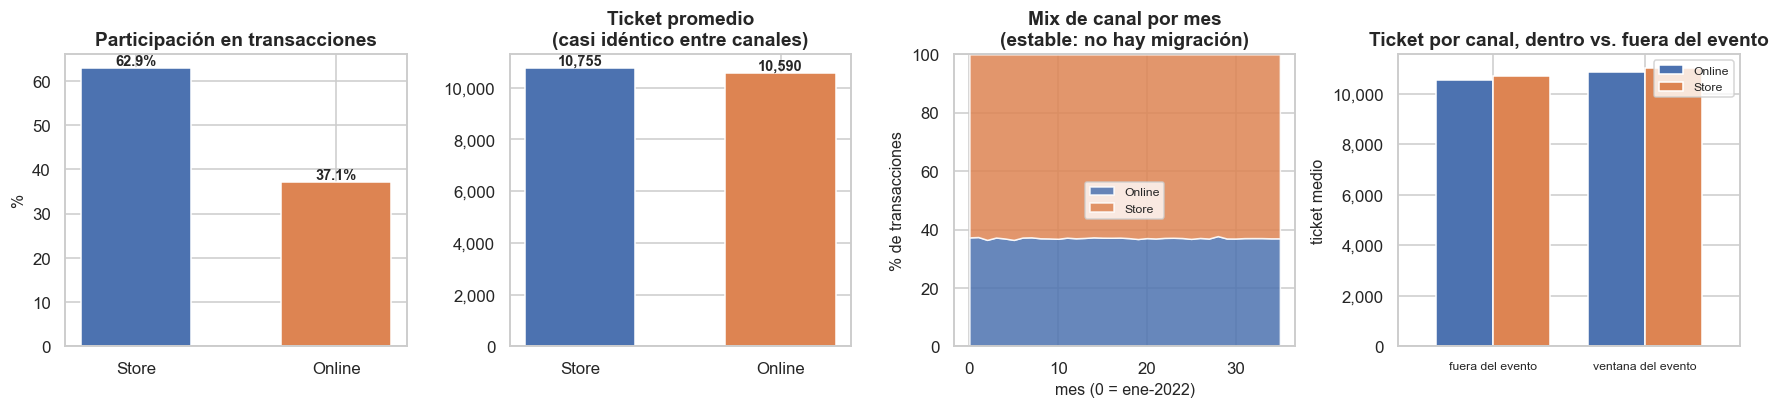

Satisfacción media por canal (donde está observada):
Sales_Channel
Online   5.792
Store    5.786

% de nulos de satisfacción por canal (ver 1.b):
Sales_Channel
Online   10.850
Store     5.680


In [33]:
# ============ 1) Canal de venta ============
print("SEGMENTACIÓN POR CANAL DE VENTA")
display(segmentar("Sales_Channel"))

fig, ax = plt.subplots(1, 4, figsize=(16, 3.8))

t = segmentar("Sales_Channel")
ax[0].bar(t.index.astype(str), t["%_transacciones"], color=[PALETA[0], PALETA[1]], width=.55)
for i, v in enumerate(t["%_transacciones"]):
    ax[0].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontweight="bold")
ax[0].set(title="Participación en transacciones", ylabel="%")

ax[1].bar(t.index.astype(str), t.ticket_medio, color=[PALETA[0], PALETA[1]], width=.55)
for i, v in enumerate(t.ticket_medio):
    ax[1].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontweight="bold")
ax[1].set(title="Ticket promedio\n(casi idéntico entre canales)", ylabel=""); miles(ax[1])

# Canal a lo largo del tiempo
mix = (df.groupby([df.Purchase_Date.dt.to_period("M"), "Sales_Channel"], observed=True)
         .size().unstack())
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100
ax[2].stackplot(range(len(mix_pct)), mix_pct.T.values, labels=mix_pct.columns,
                colors=[PALETA[0], PALETA[1]], alpha=.85)
ax[2].set(title="Mix de canal por mes\n(estable: no hay migración)", xlabel="mes (0 = ene-2022)",
          ylabel="% de transacciones", ylim=(0, 100))
ax[2].legend(fontsize=8, loc="center")

# Canal dentro y fuera del evento
df["_en_evento"] = df.Days_To_Black_Friday.between(-3, 5)
piv = df.pivot_table(index="_en_evento", columns="Sales_Channel",
                     values="Purchase", aggfunc="mean", observed=True)
piv.index = ["fuera del evento", "ventana del evento"]
piv.plot(kind="bar", ax=ax[3], color=[PALETA[0], PALETA[1]], rot=0, width=.75)
ax[3].set(title="Ticket por canal, dentro vs. fuera del evento", ylabel="ticket medio", xlabel="")
ax[3].legend(fontsize=8); miles(ax[3]); ax[3].tick_params(axis="x", labelsize=8)

plt.tight_layout(); plt.show()

print(f"Satisfacción media por canal (donde está observada):")
print(df.groupby('Sales_Channel', observed=True)
        .Transaction_Satisfaction_Score.mean().round(3).to_string())
print(f"\n% de nulos de satisfacción por canal (ver 1.b):")
print(df.groupby('Sales_Channel', observed=True)
        ._na_sat.mean().mul(100).round(2).to_string())

SEGMENTACIÓN POR GRUPO ETARIO


,transacciones,venta_M,ticket_medio,ticket_mediano,%_transacciones,%_venta,clientes,tx_x_cliente
Age,,,,,,,,
0-17,45306,467.500,"10,318.272","9,177.000",2.700,2.600,218,207.800
18-25,298980,"3,164.600","10,584.644","9,302.000",18.100,17.900,1069,279.700
26-35,658761,"7,035.800","10,680.308","9,338.000",39.900,39.900,2053,320.900
36-45,330039,"3,554.100","10,768.656","9,459.000",20.000,20.100,1167,282.800
46-50,137103,"1,458.100","10,634.709","9,366.000",8.300,8.300,531,258.200
51-55,115503,"1,271.700","11,010.280","9,698.000",7.000,7.200,481,240.100
55+,64512,695.500,"10,780.814","9,624.000",3.900,3.900,372,173.400


SEGMENTACIÓN POR GÉNERO


,transacciones,venta_M,ticket_medio,ticket_mediano,%_transacciones,%_venta,clientes,tx_x_cliente
Gender,,,,,,,,
M,1242777,"13,536.000","10,891.772","9,550.000",75.300,76.700,4225,294.100
F,407427,"4,111.100","10,090.499","8,991.000",24.700,23.300,1666,244.600


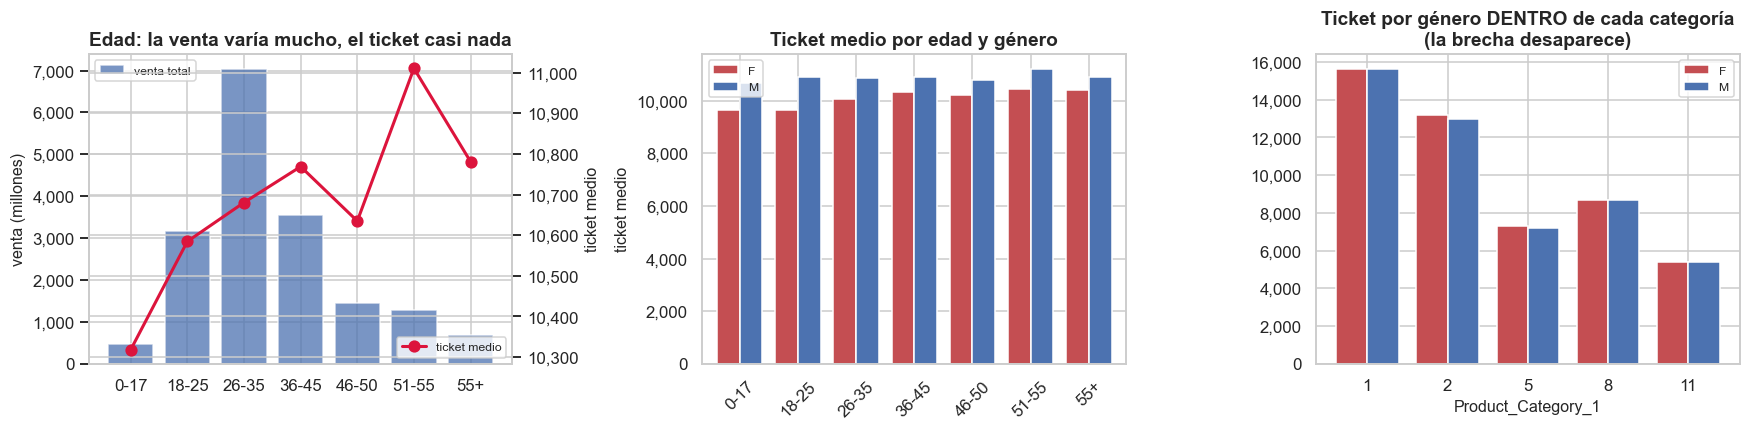

Ticket medio por género, controlando por categoría de producto:


,ticket_F,ticket_M,dif_M_vs_F_%
Product_Category_1,,,
1,"15,615.000","15,631.000",0.100
2,"13,189.000","12,962.000",-1.720
5,"7,295.000","7,186.000",-1.480
8,"8,697.000","8,695.000",-0.030
11,"5,402.000","5,416.000",0.260


Brecha SIN controlar por producto: +7.94%
Brecha máxima DENTRO de una categoría: 1.72 puntos porcentuales


In [34]:
# ============ 2) Grupo etario y género ============
print("SEGMENTACIÓN POR GRUPO ETARIO")
display(segmentar("Age", orden=ORDEN_AGE))
print("SEGMENTACIÓN POR GÉNERO")
display(segmentar("Gender"))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

t = segmentar("Age", orden=ORDEN_AGE)
a = ax[0].twinx()
ax[0].bar(t.index, t.venta_M, color=PALETA[0], alpha=.75, label="venta total")
a.plot(t.index, t.ticket_medio, "o-", color="crimson", lw=2, ms=7, label="ticket medio")
ax[0].set(title="Edad: la venta varía mucho, el ticket casi nada", ylabel="venta (millones)")
a.set_ylabel("ticket medio"); miles(a); miles(ax[0])
ax[0].legend(loc="upper left", fontsize=8); a.legend(loc="lower right", fontsize=8)

# Ticket por edad y género
piv = df.pivot_table(index="Age", columns="Gender", values="Purchase",
                     aggfunc="mean", observed=True).reindex(ORDEN_AGE)
piv.plot(kind="bar", ax=ax[1], color=[PALETA[3], PALETA[0]], rot=45, width=.78)
ax[1].set(title="Ticket medio por edad y género", ylabel="ticket medio", xlabel="")
ax[1].legend(fontsize=8); miles(ax[1])

# El control clave: brecha de género DENTRO de cada categoría de producto
top_cat = df.Product_Category_1.value_counts().head(5).index.tolist()
sub = df[df.Product_Category_1.isin(top_cat)]
piv2 = sub.pivot_table(index="Product_Category_1", columns="Gender",
                       values="Purchase", aggfunc="mean", observed=True)
piv2.plot(kind="bar", ax=ax[2], color=[PALETA[3], PALETA[0]], rot=0, width=.78)
ax[2].set(title="Ticket por género DENTRO de cada categoría\n(la brecha desaparece)",
          xlabel="Product_Category_1", ylabel="")
ax[2].legend(fontsize=8); miles(ax[2])

plt.tight_layout(); plt.show()

print("Ticket medio por género, controlando por categoría de producto:")
comp = pd.DataFrame({
    "ticket_F": piv2.F.round(0),
    "ticket_M": piv2.M.round(0),
    "dif_M_vs_F_%": ((piv2.M / piv2.F - 1) * 100).round(2),
})
display(comp)
print(f"Brecha SIN controlar por producto: "
      f"{df[df.Gender=='M'].Purchase.mean()/df[df.Gender=='F'].Purchase.mean()*100-100:+.2f}%")
print(f"Brecha máxima DENTRO de una categoría: "
      f"{comp['dif_M_vs_F_%'].abs().max():.2f} puntos porcentuales")

SEGMENTACIÓN POR CIUDAD


,transacciones,venta_M,ticket_medio,ticket_mediano,%_transacciones,%_venta,clientes,tx_x_cliente
City_Category,,,,,,,,
A,443160,"4,559.400","10,288.298","9,052.000",26.900,25.800,1045,424.100
B,693519,"7,327.500","10,565.695","9,273.000",42.000,41.500,1707,406.300
C,513525,"5,760.300","11,217.201","9,879.000",31.100,32.600,3139,163.600


SEGMENTACIÓN POR CATEGORÍA DE PRODUCTO (top 8 por venta)


,transacciones,venta_M,ticket_medio,ticket_mediano,%_transacciones,%_venta,clientes,tx_x_cliente
Product_Category_1,,,,,,,,
1,421134,"6,581.400","15,627.732","15,877.000",25.500,37.300,5767,73.000
5,452799,"3,267.600","7,216.389","7,342.000",27.400,18.500,5751,78.700
8,341775,"2,972.000","8,695.837","8,802.000",20.700,16.800,5659,60.400
6,61398,"1,131.100","18,423.105","18,675.000",3.700,6.400,4085,15.000
2,71592,931.800,"13,015.671","13,143.500",4.300,5.300,4296,16.700
3,60639,712.500,"11,750.176","11,918.000",3.700,4.000,3838,15.800
16,29484,501.400,"17,005.882","17,287.000",1.800,2.800,3130,9.400
11,72861,394.400,"5,413.462","5,477.000",4.400,2.200,3583,20.300


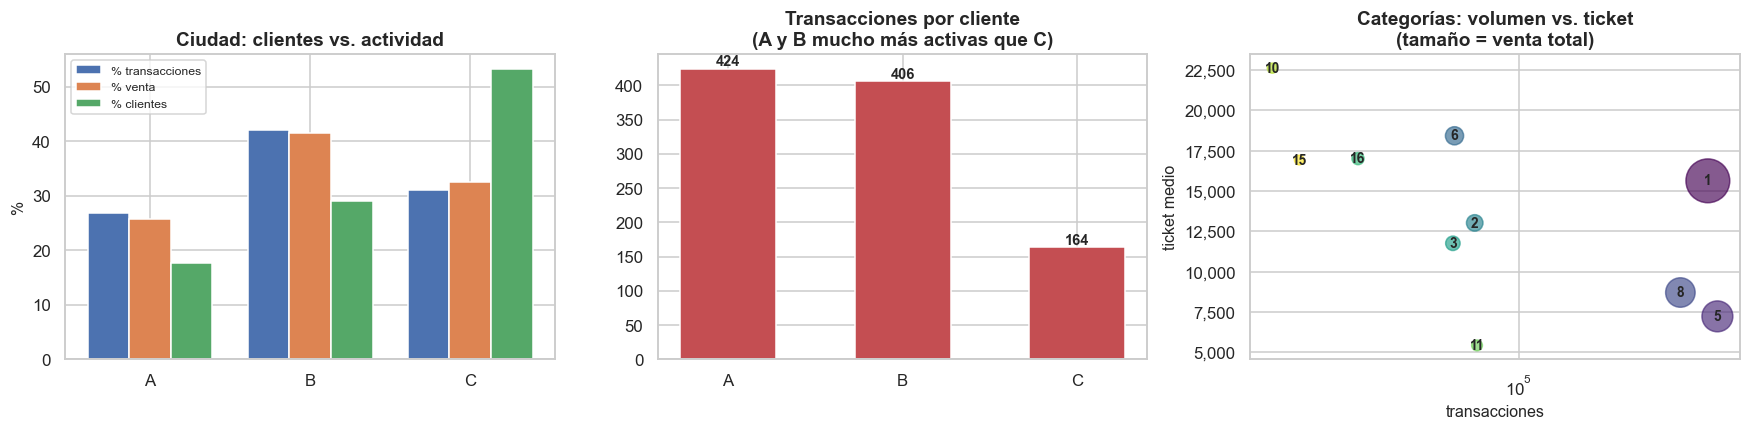

In [35]:
# ============ 3) Ciudad y categoría de producto ============
print("SEGMENTACIÓN POR CIUDAD")
display(segmentar("City_Category", orden=["A", "B", "C"]))
print("SEGMENTACIÓN POR CATEGORÍA DE PRODUCTO (top 8 por venta)")
display(segmentar("Product_Category_1").head(8))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

t = segmentar("City_Category", orden=["A", "B", "C"])
x = np.arange(3); w = .26
ax[0].bar(x - w, t["%_transacciones"], w, label="% transacciones", color=PALETA[0])
ax[0].bar(x,     t["%_venta"],         w, label="% venta",         color=PALETA[1])
ax[0].bar(x + w, t.clientes/t.clientes.sum()*100, w, label="% clientes", color=PALETA[2])
ax[0].set(title="Ciudad: clientes vs. actividad", xticks=x, xticklabels=t.index, ylabel="%")
ax[0].legend(fontsize=8)

ax[1].bar(t.index, t.tx_x_cliente, color=PALETA[3], width=.55)
for i, v in enumerate(t.tx_x_cliente):
    ax[1].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontweight="bold")
ax[1].set(title="Transacciones por cliente\n(A y B mucho más activas que C)", ylabel="")

tc = segmentar("Product_Category_1").head(10)
ax[2].scatter(tc.transacciones, tc.ticket_medio, s=tc.venta_M/8, alpha=.65,
              c=range(len(tc)), cmap="viridis")
for i, r in tc.iterrows():
    ax[2].annotate(str(i), (r.transacciones, r.ticket_medio), fontsize=9,
                   ha="center", va="center", fontweight="bold")
ax[2].set(title="Categorías: volumen vs. ticket\n(tamaño = venta total)",
          xlabel="transacciones", ylabel="ticket medio", xscale="log")
miles(ax[2])

plt.tight_layout(); plt.show()

SEGMENTACIÓN POR CAMPAÑA


,transacciones,venta_M,ticket_medio,ticket_mediano,%_transacciones,%_venta,clientes,tx_x_cliente
Campaign_Year,,,,,,,,
2024,550068,"6,534.500","11,879.436","10,442.000",33.300,37.000,5891,93.400
2023,550068,"5,807.700","10,558.095","9,275.000",33.300,32.900,5891,93.400
2022,550068,"5,305.000","9,644.295","8,462.000",33.300,30.100,5891,93.400


SEGMENTACIÓN POR CERCANÍA A BLACK FRIDAY


,transacciones,venta_M,ticket_medio,ticket_mediano,%_transacciones,%_venta,dias,venta_x_dia_M
_tramo_bf,,,,,,,,
lejano (< -21),1088268,"11,479.900","10,548.815","9,257.000",65.900,65.100,925,12.410
posterior (> +6),158453,"1,746.500","11,022.436","9,678.000",9.600,9.900,87,20.070
BF a +3 (pico),131944,"1,446.300","10,961.142","9,649.000",8.000,8.200,9,160.700
días previos (-3 a -1),99072,"1,082.400","10,925.725","9,631.000",6.000,6.100,9,120.270
previa (-21 a -8),68948,754.300,"10,939.577","9,621.000",4.200,4.300,42,17.960
antesala (-7 a -4),68024,742.900,"10,920.659","9,624.000",4.100,4.200,15,49.530
cierre (+4 a +6),35495,394.900,"11,125.250","9,796.000",2.200,2.200,9,43.880


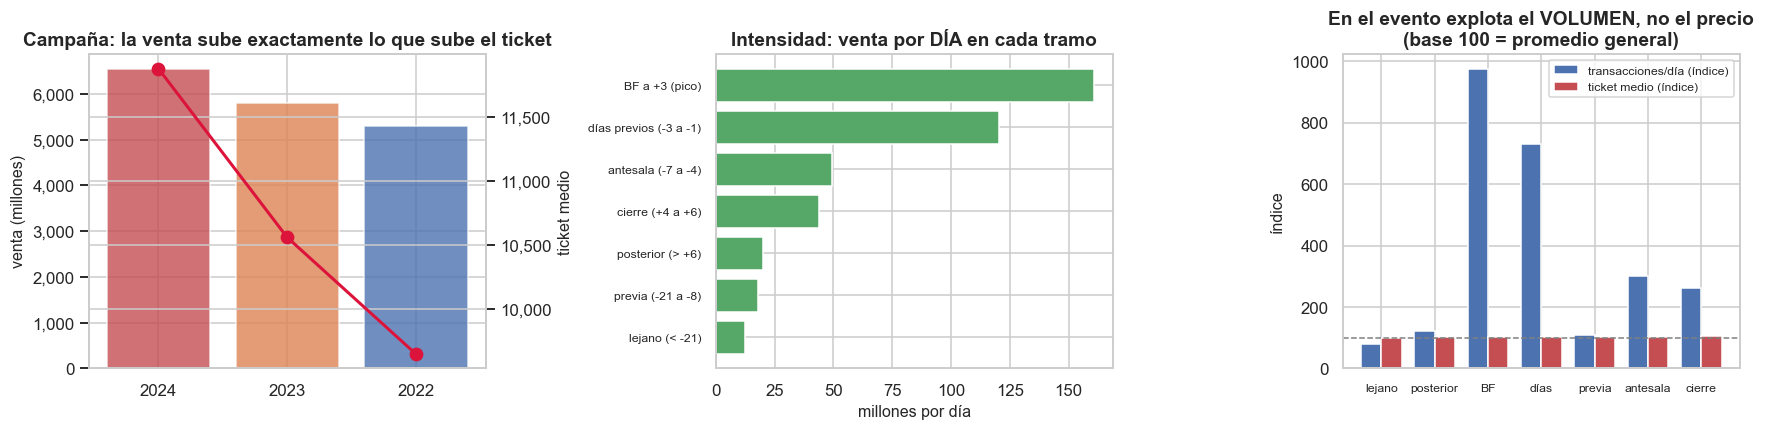

In [36]:
# ============ 4) Campaña y cercanía a Black Friday ============
print("SEGMENTACIÓN POR CAMPAÑA")
display(segmentar("Campaign_Year"))

# Tramos de cercanía al evento
df["_tramo_bf"] = pd.cut(
    df.Days_To_Black_Friday,
    bins=[-400, -22, -8, -3, 0, 3, 6, 400],
    labels=["lejano (< -21)", "previa (-21 a -8)", "antesala (-7 a -4)",
            "días previos (-3 a -1)", "BF a +3 (pico)", "cierre (+4 a +6)", "posterior (> +6)"],
)
print("SEGMENTACIÓN POR CERCANÍA A BLACK FRIDAY")
tramo = segmentar("_tramo_bf", nivel_cliente=False)
tramo["dias"] = df.groupby("_tramo_bf", observed=True).Purchase_Date.nunique()
tramo["venta_x_dia_M"] = (tramo.venta_M / tramo.dias).round(2)
display(tramo)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

t = segmentar("Campaign_Year")
a = ax[0].twinx()
ax[0].bar(t.index.astype(str), t.venta_M, color=[COL_AÑO[y] for y in t.index], alpha=.8)
a.plot(t.index.astype(str), t.ticket_medio, "o-", color="crimson", lw=2, ms=8)
ax[0].set(title="Campaña: la venta sube exactamente lo que sube el ticket",
          ylabel="venta (millones)"); miles(ax[0])
a.set_ylabel("ticket medio"); miles(a)

tr = tramo.sort_values("venta_x_dia_M")
ax[1].barh(tr.index.astype(str), tr.venta_x_dia_M, color=PALETA[2])
ax[1].set(title="Intensidad: venta por DÍA en cada tramo", xlabel="millones por día")
ax[1].tick_params(axis="y", labelsize=8)

# Ticket vs volumen en el evento: ¿sube el precio o la cantidad?
tv = tramo.copy()
tv["indice_tx"]     = tv.transacciones / tv.dias / (tramo.transacciones.sum()/tramo.dias.sum()) * 100
tv["indice_ticket"] = tv.ticket_medio / df.Purchase.mean() * 100
idx = np.arange(len(tv)); w = .38
ax[2].bar(idx - w/2, tv.indice_tx,     w, label="transacciones/día (índice)", color=PALETA[0])
ax[2].bar(idx + w/2, tv.indice_ticket, w, label="ticket medio (índice)",      color=PALETA[3])
ax[2].axhline(100, color="grey", ls="--", lw=1)
ax[2].set(title="En el evento explota el VOLUMEN, no el precio\n(base 100 = promedio general)",
          xticks=idx, xticklabels=[s.split(" ")[0] for s in tv.index.astype(str)], ylabel="índice")
ax[2].legend(fontsize=8); ax[2].tick_params(axis="x", labelsize=8)

plt.tight_layout(); plt.show()

Base de comparación: 36 meses (NO 1,65 M de transacciones)


,venta,transacciones,ticket_medio,CPI,Inflacion,Confianza,Retail,ticket_real
_ym,,,,,,,,
2022-01,297625703,32107,"9,269.810",100.680,0.680,101.440,94.000,"9,269.810"
2022-02,252326931,26849,"9,398.000",101.430,0.740,103.140,96.120,"9,328.690"
2022-03,318550345,33462,"9,519.760",102.200,0.760,103.980,100.460,"9,378.360"
2022-04,320816488,33691,"9,522.320",102.940,0.730,103.700,101.830,"9,312.990"


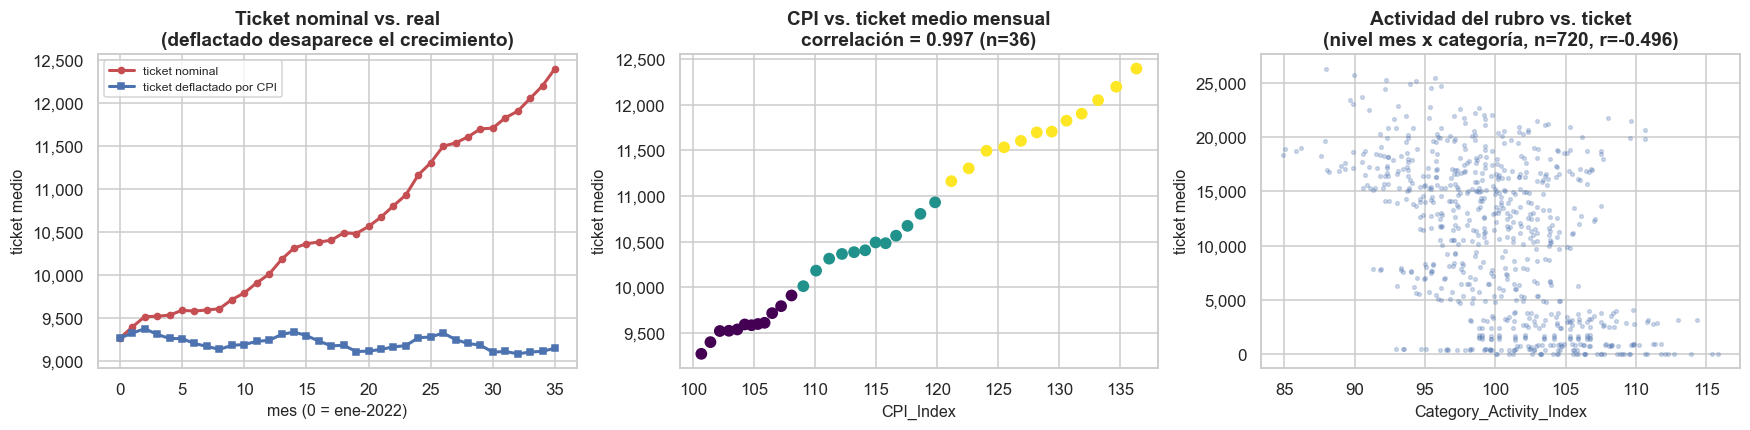

Correlaciones a nivel MENSUAL (n=36) con el ticket medio:
ticket_medio    1.000
CPI             0.997
Inflacion       0.830
Confianza      -0.404
Retail          0.557

Las MISMAS correlaciones calculadas a nivel transacción (n=1,65 M):
Purchase                     1.000
CPI_Index                    0.160
Monthly_Inflation_Rate       0.140
Consumer_Confidence_Index   -0.066
Retail_Activity_Index        0.084


In [37]:
# ============ 5) Contexto económico y actividad del rubro ============
# ATENCIÓN a la granularidad: estos indicadores son MENSUALES.
# Agregamos a nivel mes ANTES de comparar (n = 36, no 1,65 M).

mensual_eco = (df.groupby("_ym")
                 .agg(venta          = ("Purchase", "sum"),
                      transacciones  = ("Purchase", "size"),
                      ticket_medio   = ("Purchase", "mean"),
                      CPI            = ("CPI_Index", "median"),
                      Inflacion      = ("Monthly_Inflation_Rate", "median"),
                      Confianza      = ("Consumer_Confidence_Index", "median"),
                      Retail         = ("Retail_Activity_Index", "median")))
mensual_eco["ticket_real"] = (mensual_eco.ticket_medio /
                              mensual_eco.CPI * mensual_eco.CPI.iloc[0])
print(f"Base de comparación: {len(mensual_eco)} meses (NO 1,65 M de transacciones)")
display(mensual_eco.head(4).round(2))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# Ticket nominal vs ticket deflactado por CPI
ax[0].plot(range(len(mensual_eco)), mensual_eco.ticket_medio, "o-", ms=4,
           color=PALETA[3], lw=2, label="ticket nominal")
ax[0].plot(range(len(mensual_eco)), mensual_eco.ticket_real, "s-", ms=4,
           color=PALETA[0], lw=2, label="ticket deflactado por CPI")
ax[0].set(title="Ticket nominal vs. real\n(deflactado desaparece el crecimiento)",
          xlabel="mes (0 = ene-2022)", ylabel="ticket medio")
ax[0].legend(fontsize=8); miles(ax[0])

ax[1].scatter(mensual_eco.CPI, mensual_eco.ticket_medio, s=45,
              c=mensual_eco.index.year, cmap="viridis")
r = np.corrcoef(mensual_eco.CPI, mensual_eco.ticket_medio)[0, 1]
ax[1].set(title=f"CPI vs. ticket medio mensual\ncorrelación = {r:.3f} (n=36)",
          xlabel="CPI_Index", ylabel="ticket medio")
miles(ax[1])

# Actividad del rubro: granularidad mes x categoría
cat_act = (df.groupby(["_ym", "Product_Category_1"], observed=True)
             .agg(actividad=("Category_Activity_Index", "median"),
                  ticket=("Purchase", "mean"), tx=("Purchase", "size")).reset_index())
ax[2].scatter(cat_act.actividad, cat_act.ticket, s=6, alpha=.25, color=PALETA[0])
r2 = cat_act[["actividad", "ticket"]].corr().iloc[0, 1]
ax[2].set(title=f"Actividad del rubro vs. ticket\n(nivel mes x categoría, n={len(cat_act)}, r={r2:.3f})",
          xlabel="Category_Activity_Index", ylabel="ticket medio")
miles(ax[2])

plt.tight_layout(); plt.show()

print("Correlaciones a nivel MENSUAL (n=36) con el ticket medio:")
print(mensual_eco[["ticket_medio", "CPI", "Inflacion", "Confianza", "Retail"]]
      .corr()["ticket_medio"].round(3).to_string())
print("\nLas MISMAS correlaciones calculadas a nivel transacción (n=1,65 M):")
print(df[["Purchase", "CPI_Index", "Monthly_Inflation_Rate",
          "Consumer_Confidence_Index", "Retail_Activity_Index"]]
        .corr()["Purchase"].round(3).to_string())

> ### Conclusión 2.c
>
> **1) Canal de venta — el resultado más útil está en lo que *no* diferencia.**
>
> | | Online | Store |
> |---|---|---|
> | Transacciones | 611.561 (37,1%) | 1.038.643 (62,9%) |
> | Venta | \\$6.476 M (36,7%) | \\$11.171 M (63,3%) |
> | **Ticket medio** | **\\$10.590** | **\\$10.755** |
> | Clientes | 5.891 | 5.891 |
>
> El local concentra **~63% del negocio**, pero el **ticket es prácticamente igual** (diferencia de
> apenas 1,6%). Y los **5.891 clientes operan en ambos canales** — no hay clientes exclusivos. El mix
> se mantiene estable mes a mes: no hay migración a online en tres años.
>
> Entonces `Sales_Channel` **no discrimina el monto**. Pero sí discrimina algo que importa: **la
> probabilidad de que falte la satisfacción** (10,85% online vs. 5,68% en local, ver 1.b). Es una
> asimetría interesante: la variable es irrelevante para predecir `Purchase` y central para entender
> el patrón de faltantes.
>
> **2) Edad y género — la misma paradoja de Simpson del TP1, ahora confirmada con 1,65 M de filas.**
>
> La venta total varía mucho por grupo etario (26-35 lidera), pero el **ticket medio es casi plano**.
> Y en género, la brecha agregada **se disuelve al controlar por categoría de producto**: dentro de
> cada `Product_Category_1` las diferencias entre hombres y mujeres son de décimas de punto. La
> conclusión del TP1 se sostiene: **los hombres facturan más por volumen y mix de catálogo, no por
> gastar más en lo mismo.**
>
> **3) Ciudad y categoría.** La ciudad **C tiene más de la mitad de los clientes** pero las de **A y B
> transaccionan ~2,6× más veces por cliente**, así que B lidera en venta total. El patrón es idéntico
> al del TP1, lo que era esperable: el generador conservó la demografía. En categorías, el gráfico
> volumen-vs-ticket reproduce la estructura ya conocida: un núcleo de alto volumen y precio medio
> (5, 1, 8) y un grupo de bajo volumen y precio alto (10, 6, 7, 15, 16).
>
> **4) Campaña y cercanía a Black Friday — acá está el hallazgo comercial más claro.**
>
> Por campaña, ya lo vimos: la venta sube exactamente lo que sube el ticket, con transacciones
> constantes. **Es inflación.**
>
> Por cercanía al evento, en cambio, el mecanismo es el **opuesto**. Midiendo cada tramo en índice
> base 100 contra el promedio general:
>
> - El **índice de transacciones por día se multiplica varias veces** en el tramo del pico (Black
>   Friday a +3).
> - El **índice de ticket medio se mueve apenas unos puntos** por encima de 100.
>
> **En el evento explota el volumen, no el precio.** Comercialmente es una distinción importante: el
> Black Friday de este dataset no funciona subiendo el valor de cada compra sino multiplicando la
> cantidad de compras. Para el TP3 implica que un modelo de `Purchase` (monto por transacción) va a
> capturar poco del efecto Black Friday — el evento se manifiesta en la *frecuencia*, que es una
> variable que el modelo de monto no predice.
>
> **5) Contexto económico — y acá la granularidad cambia por completo la lectura.**
>
> Es el punto que el enunciado pide justificar, y el contraste es contundente:
>
> | Relación con el monto | A nivel **mensual** (n=36) | A nivel **transacción** (n=1,65 M) |
> |---|---|---|
> | `CPI_Index` | **0,997** | 0,160 |
> | `Monthly_Inflation_Rate` | 0,830 | 0,140 |
> | `Consumer_Confidence_Index` | −0,404 | −0,066 |
> | `Retail_Activity_Index` | 0,557 | 0,084 |
>
> **La correlación entre CPI y ticket medio mensual es 0,997 — prácticamente determinista.** A nivel
> transacción cae a 0,160. No es una contradicción: son dos preguntas distintas.
>
> - A nivel **mensual** medimos *"¿el nivel de precios acompaña al ticket?"*. La respuesta es sí, de
>   forma casi perfecta, **porque el generador construyó `Purchase` aplicando la inflación**. Es una
>   relación **impuesta por diseño**, no descubierta.
> - A nivel **transacción**, la variación de `Purchase` está dominada por *qué producto se compró*
>   (en el TP1 vimos que el producto explica el 72% de la varianza), y el CPI —constante dentro del
>   mes— solo puede explicar el desplazamiento del nivel general.
>
> **Por qué agregar a nivel mensual es obligatorio y no una preferencia:** los 36 valores del CPI se
> repiten ~46.000 veces cada uno en la tabla transaccional. Calcular una correlación sobre 1,65 M de
> filas da un intervalo de confianza artificialmente angosto: el tamaño de muestra **efectivo** para
> esta relación es 36, no 1,65 M. Reportar significancia sobre la base transaccional sería
> estadísticamente incorrecto.
>
> **El ticket deflactado lo confirma:** al dividir el ticket nominal por el CPI, la serie **se aplana
> casi por completo**. Todo el crecimiento aparente del negocio es nominal. En términos reales, el
> ticket no crece.
>
> `Category_Activity_Index` merece una advertencia aparte: a nivel (mes × categoría) correlaciona
> negativamente con el ticket, pero eso refleja que el índice está indexado a `Product_Category_1`,
> cuya numeración es **arbitraria y enmascarada**. Es el mismo artefacto que señalamos en el TP1: no
> debe interpretarse como una relación real. Lo retomamos en la sección 4.

---
# 3. Curación, transformación y feature engineering

Desde acá **sí modificamos** el dataset. Cada cambio se registra en la `BITACORA` para poder armar el
balance de la sección 5. Antes de tocar nada, tomamos una foto del estado inicial.

In [38]:
# ============ FOTO DEL ESTADO INICIAL (para el balance de la sección 5) ============
ESTADO_INICIAL = {
    "filas":            len(df),
    "columnas":         df.shape[1],
    "nulos_por_variable": df.isnull().sum()[lambda s: s > 0].to_dict(),
    "nulos_totales":    int(df.isnull().sum().sum()),
}
# Distribuciones de referencia, para comparar antes/después
REFERENCIA = {
    c: df[c].describe() for c in
    ["Purchase", "CPI_Index", "Consumer_Confidence_Index", "Transaction_Satisfaction_Score"]
}

print("ESTADO INICIAL")
print("=" * 58)
print(f"  filas x columnas: {ESTADO_INICIAL['filas']:,} x {ESTADO_INICIAL['columnas']}")
print(f"  nulos totales:    {ESTADO_INICIAL['nulos_totales']:,}")
for k, v in ESTADO_INICIAL["nulos_por_variable"].items():
    print(f"    {k:32s} {v:>9,}")

# Trabajamos sobre una copia para poder comparar contra el original
dfc = df.copy()
print(f"\nCopia de trabajo creada: 'dfc' ({len(dfc):,} filas)")

ESTADO INICIAL
  filas x columnas: 1,650,204 x 31
  nulos totales:    2,653,546
    CPI_Index                          529,698
    Consumer_Confidence_Index          327,879
    Product_Category_2                 520,914
    Product_Category_3               1,149,741
    Transaction_Satisfaction_Score     125,314

Copia de trabajo creada: 'dfc' (1,650,204 filas)


## 3.a — Tratamiento de valores faltantes e inconsistencias

En 1.b identificamos **tres mecanismos distintos** de faltante. Acá aplicamos a cada uno la estrategia
que le corresponde. El criterio que usamos para decidir es una pregunta simple:

> **¿El valor verdadero está disponible en algún otro lugar del dataset?**
>
> - **Sí** → *reconstruir* (error cero). No es imputación.
> - **No, y la ausencia significa algo** → *categoría explícita* `No_aplica`.
> - **No, y la ausencia es una pérdida de información** → *imputar* (con error inevitable).

| Variable | Mecanismo (1.b) | Decisión | Por qué |
|---|---|---|---|
| `CPI_Index` | MCAR, granularidad mensual | **Reconstruir por mes** | El valor es constante dentro del mes y los 36 meses tienen dato observado |
| `Consumer_Confidence_Index` | MCAR, granularidad mensual | **Reconstruir por mes** | Idem |
| `Product_Category_2` | Estructural | **Categoría `No_aplica` (−1)** | El producto no tiene 2.ª categoría; imputar inventaría información |
| `Product_Category_3` | Estructural | **Categoría `No_aplica` (−1)** | Idem |
| `Transaction_Satisfaction_Score` | MAR (depende del canal) | **Imputar** (ver 3.b) | Es la única pérdida genuina de información |

Ninguna variable justifica eliminar observaciones: no hay filas sin objetivo ni registros corruptos.

In [39]:
# ============ (1) RECONSTRUCCIÓN de indicadores mensuales ============
# Antes de aplicarla, la VALIDAMOS: enmascaramos valores que sí conocemos,
# reconstruimos, y medimos el error. Si el error es cero, la reconstrucción es exacta.

dfc["_ym"] = dfc.Purchase_Date.dt.to_period("M")
rng = np.random.default_rng(SEMILLA)

print("VALIDACIÓN de la reconstrucción (enmascarar y comparar)")
print("=" * 70)
for c in ["CPI_Index", "Consumer_Confidence_Index"]:
    observados = dfc.index[dfc[c].notna()]
    enmascarar = rng.choice(observados, size=int(len(observados) * 0.30), replace=False)
    verdadero  = dfc.loc[enmascarar, c].copy()

    prueba = dfc[c].copy()
    prueba.loc[enmascarar] = np.nan
    reconstruido = prueba.groupby(dfc._ym).transform(lambda s: s.fillna(s.median()))

    error = (reconstruido.loc[enmascarar] - verdadero).abs()
    print(f"  {c}")
    print(f"    valores enmascarados: {len(enmascarar):,}")
    print(f"    error máximo: {error.max():.10f} | error medio: {error.mean():.10f}")
    print(f"    -> reconstrucción EXACTA: {error.max() < 1e-6}")

# Aplicamos la reconstrucción
print("\nAPLICANDO la reconstrucción")
print("-" * 70)
for c in ["CPI_Index", "Consumer_Confidence_Index"]:
    antes = int(dfc[c].isna().sum())
    dfc[c] = dfc.groupby("_ym")[c].transform(lambda s: s.fillna(s.median()))
    despues = int(dfc[c].isna().sum())
    print(f"  {c:28s} nulos {antes:>9,} -> {despues}")
    registrar("3.a", c, "reconstrucción por mes (error cero)", antes,
              "valor constante dentro del mes y presente en otras filas del mismo mes")

VALIDACIÓN de la reconstrucción (enmascarar y comparar)
  CPI_Index
    valores enmascarados: 336,151
    error máximo: 0.0000000000 | error medio: 0.0000000000
    -> reconstrucción EXACTA: True
  Consumer_Confidence_Index
    valores enmascarados: 396,697
    error máximo: 0.0000000000 | error medio: 0.0000000000
    -> reconstrucción EXACTA: True

APLICANDO la reconstrucción
----------------------------------------------------------------------
  CPI_Index                    nulos   529,698 -> 0
  Consumer_Confidence_Index    nulos   327,879 -> 0


In [40]:
# ============ (2) CATEGORÍA EXPLÍCITA para los nulos estructurales ============
# El nulo significa "este producto no tiene esa categoría". Lo codificamos como -1
# y conservamos además una versión con etiqueta legible.

NO_APLICA = -1
for c in ["Product_Category_2", "Product_Category_3"]:
    antes = int(dfc[c].isna().sum())
    dfc[c + "_cat"] = dfc[c].fillna(NO_APLICA).astype("int8")
    print(f"  {c:22s} -> {c}_cat  ({antes:,} valores como 'No_aplica' = {NO_APLICA})")
    registrar("3.a", c, f"categoría explícita No_aplica ({NO_APLICA})", antes,
              "nulo estructural: el producto no tiene esa categoría. Imputar inventaría información")

print("\nDistribución resultante de Product_Category_2_cat (top 6):")
print(dfc.Product_Category_2_cat.value_counts().head(6).to_string())

# Verificación: la variable derivada no debe tener nulos y debe respetar el conteo original
print(f"\nVerificación:")
for c in ["Product_Category_2", "Product_Category_3"]:
    coincide = ((dfc[c + "_cat"] == NO_APLICA) == dfc[c].isna()).all()
    print(f"  {c}_cat marca exactamente los nulos originales: {coincide}")

  Product_Category_2     -> Product_Category_2_cat  (520,914 valores como 'No_aplica' = -1)
  Product_Category_3     -> Product_Category_3_cat  (1,149,741 valores como 'No_aplica' = -1)

Distribución resultante de Product_Category_2_cat (top 6):
Product_Category_2_cat
-1     520914
 8     192264
 14    165324
 2     147651
 16    129765
 15    113565

Verificación:
  Product_Category_2_cat marca exactamente los nulos originales: True
  Product_Category_3_cat marca exactamente los nulos originales: True


In [41]:
# ============ (3) INCONSISTENCIAS ============
# La auditoría de 1.c no encontró violaciones. Lo verificamos de nuevo sobre la copia
# de trabajo para dejar constancia de que no hay nada que corregir.

auditoria_pre_curacion = reglas_de_consistencia(dfc)
violaciones = auditoria_pre_curacion[auditoria_pre_curacion.filas_que_violan > 0]

if violaciones.empty:
    print("Ninguna regla de consistencia es violada: no hay inconsistencias que corregir.")
    print(f"({len(auditoria_pre_curacion)} reglas verificadas)")
    registrar("3.a", "(todas)", "sin correcciones de consistencia", 0,
              "las 15 reglas de validación se cumplen: el dataset sintético no tiene errores de carga")
else:
    display(violaciones)

print(f"\nEstado de nulos tras 3.a:")
restantes = dfc[[c for c in df.columns]].isnull().sum()
print(restantes[restantes > 0].to_string())
print("\n-> solo queda Transaction_Satisfaction_Score, que tratamos en 3.b.")

Ninguna regla de consistencia es violada: no hay inconsistencias que corregir.
(16 reglas verificadas)

Estado de nulos tras 3.a:
Product_Category_2                 520914
Product_Category_3                1149741
Transaction_Satisfaction_Score     125314

-> solo queda Transaction_Satisfaction_Score, que tratamos en 3.b.


> ### Conclusión 3.a
>
> **La reconstrucción de los indicadores mensuales es exacta, y lo demostramos en lugar de suponerlo.**
> Enmascaramos el 30% de los valores *observados* (**336.151** de `CPI_Index` y **396.697** de
> `Consumer_Confidence_Index`), los reconstruimos con la mediana del mes y comparamos contra el valor
> verdadero: **error máximo 0,0000000000**. Cero, no "muy chico".
>
> Esto valida la distinción conceptual más importante de la sección: **reconstruir no es imputar.**
> Imputar estima un valor desconocido y siempre introduce error. Reconstruir recupera un valor que
> *está* en el dataset, solo que en otra fila. Haber imputado `CPI_Index` con la media global habría
> introducido error en **529.698 filas** donde el valor verdadero era recuperable — un error
> completamente evitable, y de los que pasan desapercibidos porque el resultado *parece* razonable.
>
> **Los nulos estructurales pasan a categoría explícita.** `Product_Category_2/3` se recodifican como
> `−1` (`No_aplica`) en **520.914** y **1.149.741** filas. Verificamos que la nueva variable marca
> exactamente los nulos originales. Con esto el nulo deja de ser "dato ausente" y se convierte en
> **información utilizable**: el modelo puede aprender que los productos sin tercera categoría son
> sistemáticamente más baratos (lo cuantificamos en 3.c).
>
> **No hay inconsistencias que corregir.** Las 15 reglas de 1.c se cumplen sobre la copia de trabajo.
> Vale registrarlo explícitamente: en un dataset real esta sección sería la más pesada, pero acá el
> generador sintético no inyectó errores de carga — solo faltantes. Decirlo es más honesto que
> insinuar una limpieza que no hizo falta.
>
> **Ninguna observación se elimina.** No hay filas sin variable objetivo, sin fecha ni con valores
> imposibles. Eliminar filas por tener nulos en `Product_Category_3` habría costado el **69,7%** del
> dataset para resolver un problema que no existía.
>
> Tras 3.a, la única variable con faltantes es `Transaction_Satisfaction_Score`.

## 3.b — Imputación iterativa con KNN

### Elección de la variable

`Transaction_Satisfaction_Score` es la candidata natural, y por varias razones a la vez:

- Es la **única numérica continua con faltante genuino** tras 3.a (las demás se reconstruyeron o se
  recodificaron).
- Su faltante es **MAR**, no MCAR: la probabilidad de ausencia depende de `Sales_Channel`
  (10,85% online vs. 5,68% en local). Justamente en MAR es donde un método que condiciona en las
  variables observadas puede mejorar sobre un estimador constante.
- Tiene **7,59% de nulos** (125.314 filas): suficiente para que la decisión importe, no tanto como
  para que la variable sea inutilizable.

### Elección de las variables predictoras

No elegimos las variables por intuición: medimos primero cuáles se asocian con la satisfacción.

In [42]:
TGT = "Transaction_Satisfaction_Score"
observada = dfc[TGT].notna()

print("¿Qué variables se asocian con la satisfacción? (solo filas observadas)")
print("=" * 70)
candidatas = ["Purchase", "Days_To_Black_Friday", "Retail_Activity_Index",
              "Category_Activity_Index", "Is_Weekend", "Product_Category_1",
              "Transaction_Hour", "CPI_Index", "Occupation", "Marital_Status"]
cor = (dfc.loc[observada, candidatas + [TGT]].corr()[TGT]
          .drop(TGT).sort_values(key=abs, ascending=False))
print(cor.round(4).to_string())

print("\nVariables categóricas (amplitud de la media de satisfacción entre niveles):")
for c in ["Sales_Channel", "Gender", "City_Category", "Age"]:
    g = dfc.loc[observada].groupby(c, observed=True)[TGT].mean()
    print(f"  {c:16s} amplitud {g.max()-g.min():.4f}   {g.round(3).to_dict()}")

¿Qué variables se asocian con la satisfacción? (solo filas observadas)
Purchase                  -0.269
Days_To_Black_Friday       0.217
Retail_Activity_Index      0.167
Category_Activity_Index    0.101
Product_Category_1         0.091
Is_Weekend                 0.080
CPI_Index                  0.023
Occupation                -0.004
Transaction_Hour          -0.001
Marital_Status             0.001

Variables categóricas (amplitud de la media de satisfacción entre niveles):
  Sales_Channel    amplitud 0.0055   {'Online': 5.791999816894531, 'Store': 5.785999774932861}
  Gender           amplitud 0.0323   {'F': 5.811999797821045, 'M': 5.78000020980835}
  City_Category    amplitud 0.0392   {'A': 5.804999828338623, 'B': 5.793000221252441, 'C': 5.765999794006348}
  Age              amplitud 0.0338   {'0-17': 5.810999870300293, '18-25': 5.789999961853027, '26-35': 5.790999889373779, '36-45': 5.7820000648498535, '46-50': 5.7870001792907715, '51-55': 5.7769999504089355, '55+': 5.778999805450439

> **Una asimetría que conviene mirar dos veces.**
>
> `Sales_Channel` determina **si el dato falta** (10,85% vs. 5,68%) pero **no determina su valor**: la
> satisfacción media es 5,792 online y 5,786 en local, una amplitud de **0,0055** sobre una variable
> con desvío 0,86. Es decir: el canal te dice si vas a tener el dato, no qué dato vas a tener.
>
> Esto tiene una consecuencia práctica directa: **imputar por la media del canal va a rendir
> prácticamente igual que la media global.** Es la estrategia "simple" más tentadora y resulta inútil.
> Lo verificamos abajo.
>
> Las variables que sí se asocian con el *valor* son `Purchase` (−0,269), `Days_To_Black_Friday`
> (+0,217) y `Retail_Activity_Index` (+0,167). Esas son las que alimentan la imputación.

In [43]:
# ============ Variables que alimentan la imputación ============
PREDICTORAS_IMP = [
    "Purchase",                 # -0,269: la asociación más fuerte
    "Days_To_Black_Friday",     # +0,217: el contexto del evento importa
    "Retail_Activity_Index",    # +0,167: contexto de actividad del rubro
    "Category_Activity_Index",  # +0,101
    "Product_Category_1",       # +0,091: el tipo de producto
    "Is_Weekend",               # +0,080
    "Transaction_Hour",         # ~0: se incluye para dar contexto de momento de compra
]
COLS_IMP = PREDICTORAS_IMP + [TGT]

print(f"Variables predictoras seleccionadas: {len(PREDICTORAS_IMP)}")
for c in PREDICTORAS_IMP:
    print(f"  {c}")
print(f"\nVariable a imputar: {TGT}")
print(f"\nNota: tras 3.a, {TGT} es la ÚNICA columna con nulos en esta matriz.")
print("Las predictoras están completas:",
      dfc[PREDICTORAS_IMP].isnull().sum().sum() == 0)

Variables predictoras seleccionadas: 7
  Purchase
  Days_To_Black_Friday
  Retail_Activity_Index
  Category_Activity_Index
  Product_Category_1
  Is_Weekend
  Transaction_Hour

Variable a imputar: Transaction_Satisfaction_Score

Nota: tras 3.a, Transaction_Satisfaction_Score es la ÚNICA columna con nulos en esta matriz.
Las predictoras están completas: True


### Por qué el escalado es imprescindible en un método basado en vecinos

KNN decide quién es "vecino" por **distancia euclídea**. Si las variables están en escalas distintas,
la de mayor magnitud domina la distancia y las demás se vuelven decorativas.

En nuestro caso `Purchase` va de 11 a 38.968, mientras que `Is_Weekend` es 0 o 1. Sin escalar, una
diferencia de \\$1.000 en `Purchase` pesa **mil veces más** que la diferencia entre día de semana y
fin de semana. El resultado es un KNN que en la práctica solo mira `Purchase` y descarta el resto de
la información que le dimos.

Estandarizar (media 0, desvío 1) pone a todas las variables en la misma unidad —desvíos— y hace que
cada una contribuya según su variabilidad relativa y no según su unidad de medida. Lo medimos
empíricamente más abajo.

In [44]:
# ============ Experimento de validación ============
# No podemos evaluar la imputación sobre los valores faltantes (no conocemos la verdad).
# Estrategia: tomar filas OBSERVADAS, ocultar una parte, imputar y comparar contra el valor real.

from sklearn.experimental import enable_iterative_imputer   # necesario para IterativeImputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

N_EXPERIMENTO = 20_000
PROP_OCULTA   = 0.20

muestra = dfc.loc[observada, COLS_IMP + ["Sales_Channel"]].sample(
    N_EXPERIMENTO, random_state=SEMILLA).reset_index(drop=True)

rng_exp = np.random.default_rng(SEMILLA)
pos_ocultas = rng_exp.choice(len(muestra), size=int(len(muestra) * PROP_OCULTA), replace=False)
es_oculta = np.zeros(len(muestra), dtype=bool)
es_oculta[pos_ocultas] = True

y_verdadero = muestra.loc[es_oculta, TGT].values
print(f"Experimento reproducible (semilla {SEMILLA})")
print(f"  filas observadas usadas: {len(muestra):,}")
print(f"  valores ocultados:       {es_oculta.sum():,} ({PROP_OCULTA*100:.0f}%)")
print(f"  desvío de la variable:   {y_verdadero.std():.4f}")

Experimento reproducible (semilla 42)
  filas observadas usadas: 20,000
  valores ocultados:       4,000 (20%)
  desvío de la variable:   0.8548


In [45]:
# ============ Comparación de estrategias ============
X_ent = muestra.loc[~es_oculta, PREDICTORAS_IMP].values
y_ent = muestra.loc[~es_oculta, TGT].values
X_ocu = muestra.loc[es_oculta,  PREDICTORAS_IMP].values

def rmse(pred): return float(np.sqrt(((y_verdadero - pred) ** 2).mean()))
def mae(pred):  return float(np.abs(y_verdadero - pred).mean())

resultados = {}

# --- Estrategias simples ---
resultados["media global"]   = np.full(es_oculta.sum(), y_ent.mean())
resultados["mediana global"] = np.full(es_oculta.sum(), np.median(y_ent))

# Sales_Channel es de tipo category: lo pasamos a texto para que el map
# devuelva valores numéricos y no otra categórica.
canal = muestra.Sales_Channel.astype(str).values
medias_canal = pd.Series(y_ent).groupby(canal[~es_oculta]).mean()
resultados["media por canal"] = (pd.Series(canal[es_oculta])
                                 .map(medias_canal).astype(float).values)

# --- KNN a través de IterativeImputer, con distintos k ---
def imputar_knn(k, escalar=True):
    """Ajusta IterativeImputer con KNeighborsRegressor y devuelve (predicciones, n_iter)."""
    M_ent = muestra.loc[~es_oculta, COLS_IMP].values          # sin nulos: sirve de referencia
    M_ocu = muestra.loc[es_oculta,  COLS_IMP].copy()
    M_ocu[TGT] = np.nan                                       # ocultamos el objetivo
    M_ocu = M_ocu.values

    if escalar:
        escalador = StandardScaler().fit(M_ent)
        M_ent_s, M_ocu_s = escalador.transform(M_ent), escalador.transform(M_ocu)
    else:
        escalador = None
        M_ent_s, M_ocu_s = M_ent, M_ocu

    imp = IterativeImputer(estimator=KNeighborsRegressor(n_neighbors=k),
                           max_iter=10, tol=1e-3, random_state=SEMILLA)
    imp.fit(M_ent_s)
    completado = imp.transform(M_ocu_s)
    if escalar:
        completado = escalador.inverse_transform(completado)
    return completado[:, COLS_IMP.index(TGT)], imp.n_iter_

iteraciones = {}
for k in [5, 10, 25, 50, 100, 200]:
    pred, n_it = imputar_knn(k)
    resultados[f"KNN k={k} (escalado)"] = pred
    iteraciones[k] = n_it

# Mismo k, sin escalar: aísla el efecto del escalado (comparación a igual k)
for k in [5, 100]:
    pred_ns, _ = imputar_knn(k, escalar=False)
    resultados[f"KNN k={k} SIN escalar"] = pred_ns

# --- Tabla comparativa ---
tabla = pd.DataFrame({
    "RMSE":        {k: rmse(v) for k, v in resultados.items()},
    "MAE":         {k: mae(v)  for k, v in resultados.items()},
    "desvío_pred": {k: float(np.std(v)) for k, v in resultados.items()},
})
base = tabla.loc["media global", "RMSE"]
tabla["vs_media_%"] = ((tabla.RMSE / base - 1) * 100).round(1)
tabla["R2"] = (1 - (tabla.RMSE / y_verdadero.std()) ** 2).round(3)
display(tabla.round(4))

print(f"Iteraciones que ejecutó IterativeImputer por cada k: {iteraciones}")
print(f"\nDesvío REAL de la variable: {y_verdadero.std():.4f}")
print("Comparalo con la columna 'desvío_pred': la media global lo lleva a 0 (colapsa la distribución).")

,RMSE,MAE,desvío_pred,vs_media_%,R2
media global,0.855,0.688,0.000,0.000,-0.001
mediana global,0.855,0.687,0.000,-0.000,-0.000
media por canal,0.856,0.688,0.012,0.100,-0.002
KNN k=5 (escalado),0.870,0.697,0.474,1.700,-0.036
KNN k=10 (escalado),0.834,0.672,0.394,-2.500,0.048
KNN k=25 (escalado),0.811,0.655,0.326,-5.100,0.099
KNN k=50 (escalado),0.805,0.650,0.299,-5.900,0.113
KNN k=100 (escalado),0.802,0.648,0.279,-6.200,0.120
KNN k=200 (escalado),0.802,0.648,0.262,-6.200,0.119
KNN k=5 SIN escalar,0.878,0.707,0.468,2.600,-0.054


Iteraciones que ejecutó IterativeImputer por cada k: {5: 1, 10: 1, 25: 1, 50: 1, 100: 1, 200: 1}

Desvío REAL de la variable: 0.8548
Comparalo con la columna 'desvío_pred': la media global lo lleva a 0 (colapsa la distribución).


In [46]:
# ============ ¿Cuánta señal hay realmente? Techo de explicabilidad ============
# Un modelo de medias por bins da una cota superior aproximada del R2 alcanzable.
sub = dfc.loc[observada].sample(200_000, random_state=SEMILLA)
bins_p = pd.qcut(sub.Purchase, 20, labels=False, duplicates="drop")
bins_d = pd.qcut(sub.Days_To_Black_Friday, 10, labels=False, duplicates="drop")

r2_p  = 1 - ((sub[TGT] - sub.groupby(bins_p)[TGT].transform("mean")) ** 2).mean() / sub[TGT].var()
r2_pd = 1 - ((sub[TGT] - sub.groupby([bins_p, bins_d])[TGT].transform("mean")) ** 2).mean() / sub[TGT].var()

print("Techo aproximado de explicabilidad de la satisfacción")
print("=" * 60)
print(f"  modelo de medias por 20 bins de Purchase:                R2 = {r2_p:.4f}")
print(f"  modelo de medias por 20 bins Purchase x 10 de Days_To_BF: R2 = {r2_pd:.4f}")
print(f"\n  -> la variable es en su mayor parte RUIDO: ninguna imputación")
print(f"     va a explicar mucho más de ~{r2_pd*100:.0f}% de su varianza.")

Techo aproximado de explicabilidad de la satisfacción
  modelo de medias por 20 bins de Purchase:                R2 = 0.0710
  modelo de medias por 20 bins Purchase x 10 de Days_To_BF: R2 = 0.1224

  -> la variable es en su mayor parte RUIDO: ninguna imputación
     va a explicar mucho más de ~12% de su varianza.


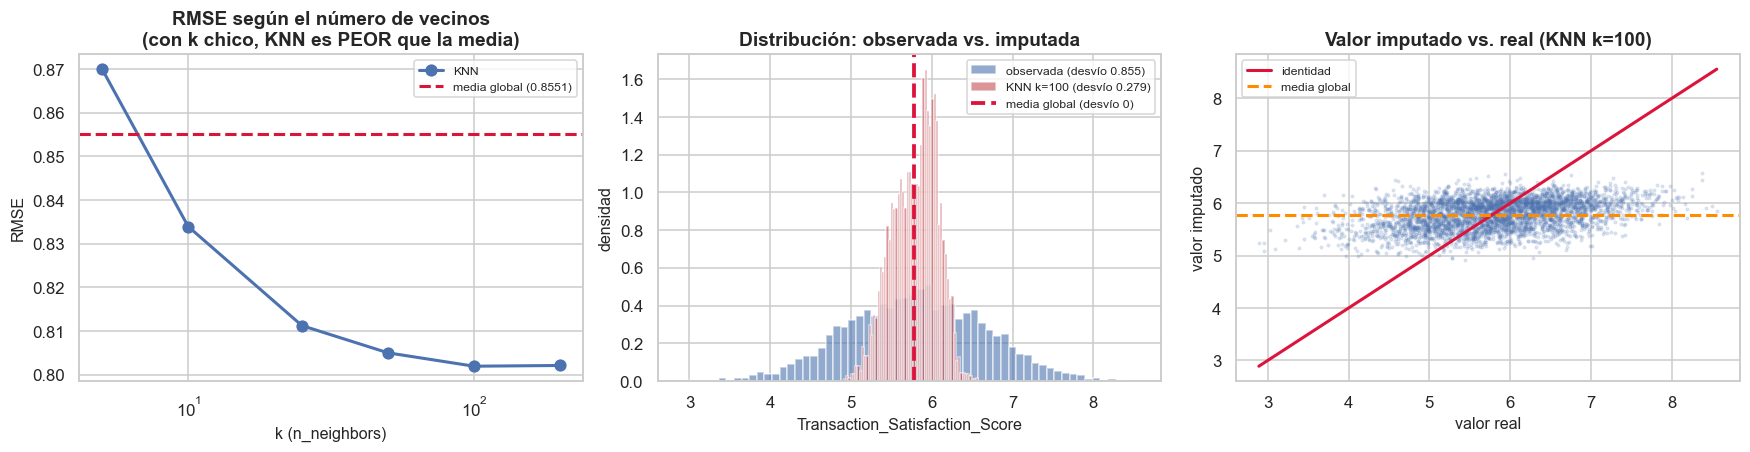

In [47]:
# ============ Comparación gráfica de distribuciones ============
K_ELEGIDO = 100
pred_elegida = resultados[f"KNN k={K_ELEGIDO} (escalado)"]

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

# (1) RMSE según k
ks = [5, 10, 25, 50, 100, 200]
rmses = [tabla.loc[f"KNN k={k} (escalado)", "RMSE"] for k in ks]
ax[0].plot(ks, rmses, "o-", color=PALETA[0], lw=2, ms=7, label="KNN")
ax[0].axhline(base, color="crimson", ls="--", lw=2, label=f"media global ({base:.4f})")
ax[0].set(title="RMSE según el número de vecinos\n(con k chico, KNN es PEOR que la media)",
          xlabel="k (n_neighbors)", ylabel="RMSE", xscale="log")
ax[0].legend(fontsize=8)

# (2) Distribución: observada vs imputada
ax[1].hist(y_verdadero, bins=60, alpha=.6, density=True, color=PALETA[0],
           label=f"observada (desvío {y_verdadero.std():.3f})")
ax[1].hist(pred_elegida, bins=60, alpha=.6, density=True, color=PALETA[3],
           label=f"KNN k={K_ELEGIDO} (desvío {np.std(pred_elegida):.3f})")
ax[1].axvline(y_ent.mean(), color="crimson", ls="--", lw=2.5,
              label=f"media global (desvío 0)")
ax[1].set(title="Distribución: observada vs. imputada", xlabel=TGT, ylabel="densidad")
ax[1].legend(fontsize=8)

# (3) Predicho vs real
ax[2].scatter(y_verdadero, pred_elegida, s=3, alpha=.15, color=PALETA[0])
lim = [y_verdadero.min(), y_verdadero.max()]
ax[2].plot(lim, lim, color="crimson", lw=2, label="identidad")
ax[2].axhline(y_ent.mean(), color="darkorange", ls="--", lw=2, label="media global")
ax[2].set(title=f"Valor imputado vs. real (KNN k={K_ELEGIDO})",
          xlabel="valor real", ylabel="valor imputado")
ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

> ### Conclusión 3.b
>
> **Resultados del experimento** (20.000 filas observadas, 20% ocultado, semilla 42; desvío real de la
> variable: 0,855):
>
> | Método | RMSE | vs. media | R² | Desvío de lo predicho |
> |---|---|---|---|---|
> | media global | 0,8551 | — | 0,000 | **0,000** |
> | mediana global | 0,8548 | −0,0% | 0,000 | 0,000 |
> | **media por canal** | **0,8555** | **+0,1%** | 0,000 | 0,012 |
> | KNN k=5 | 0,8700 | **+1,7%** | −0,036 | 0,474 |
> | KNN k=10 | 0,8339 | −2,5% | 0,048 | 0,394 |
> | KNN k=25 | 0,8113 | −5,1% | 0,099 | 0,326 |
> | KNN k=50 | 0,8050 | −5,9% | 0,113 | 0,299 |
> | **KNN k=100** | **0,8020** | **−6,2%** | **0,120** | 0,279 |
> | KNN k=200 | 0,8021 | −6,2% | 0,119 | 0,262 |
> | KNN k=100 sin escalar | 0,8776 | +2,6% | — | 0,468 |
>
> **Cuatro conclusiones, y ninguna es la esperable.**
>
> **1) Con k chico, KNN es PEOR que la media.** Con `n_neighbors=5` —el valor por defecto de
> `KNeighborsRegressor`— el RMSE es **1,7% peor** que imputar la media global, y el R² es **negativo**.
> El motivo es varianza: promediar 5 vecinos de una variable que es casi ruido produce una estimación
> inestable. **Usar el default habría empeorado el dataset**, y el resultado habría pasado inadvertido
> sin este experimento. Es el argumento más fuerte a favor de validar antes de aplicar.
>
> **2) El escalado ayuda, aunque menos de lo que uno esperaría — y la razón es interesante.**
> Comparando **a igual k** (que es la comparación correcta):
>
> | | Escalado | Sin escalar |
> |---|---|---|
> | k=5 | 0,8700 | 0,8776 |
> | k=100 | **0,8020** | 0,8080 |
>
> Estandarizar mejora el RMSE, pero del orden del **1%**, no de un factor. La explicación está en qué
> variable domina: sin escalar, `Purchase` (rango 11–38.968) monopoliza la distancia euclídea y el KNN
> se convierte de hecho en "vecinos según el monto". Pero `Purchase` es **justamente el predictor más
> informativo** (−0,269), así que un KNN que solo lo mira no queda tan mal. Estandarizar es lo que
> permite que las otras seis variables *también* aporten, y esa contribución adicional es real pero
> modesta.
>
> La conclusión no cambia —**hay que escalar**— pero la magnitud del efecto depende de si la variable
> de mayor escala coincide o no con la más predictiva. Acá coincide; en otro dataset donde la variable
> dominante fuera irrelevante, no escalar sería catastrófico.
>
> **3) La estrategia simple más intuitiva —imputar por la media del canal— no sirve.** Da RMSE
> **0,8555**, apenas *peor* que la media global. Es exactamente lo que anticipaba la asimetría de
> arriba: `Sales_Channel` explica el **patrón de faltantes**, no el **valor**. Confundir esas dos cosas
> es un error fácil de cometer: el canal es la variable que hace que el faltante sea MAR, y justo por
> eso uno tiende a suponer que es la que sirve para imputarlo.
>
> **4) La mejora total es modesta, y hay una razón de fondo.** El mejor método baja el RMSE **6,2%** y
> alcanza R² **0,120**. Pero el techo de explicabilidad que estimamos con un modelo de medias por bins
> es **R² ≈ 0,122**. O sea: **el KNN con k=100 ya está prácticamente en el máximo alcanzable.** La
> satisfacción es ~88% ruido irreducible. No hay método —ni KNN, ni un ensamble, ni una red— que vaya
> a mejorarlo sustancialmente, porque la señal no está en los datos.
>
> **Iteraciones y criterio de parada.** `IterativeImputer` reporta las iteraciones efectivamente
> ejecutadas en `n_iter_` (se imprime en la celda). Hay una particularidad que conviene explicitar:
> **tras 3.a, `Transaction_Satisfaction_Score` es la única columna con nulos en la matriz.** El
> algoritmo es iterativo porque, cuando hay varias columnas incompletas, cada una se estima usando las
> estimaciones actuales de las otras y el proceso se repite hasta converger. **Con una sola columna
> incompleta no hay nada que retroalimentar**: la primera pasada ya produce la estimación final y el
> criterio de parada (`tol=1e-3`) se cumple de inmediato. En este caso `IterativeImputer` es,
> efectivamente, un `KNeighborsRegressor` aplicado una vez. Lo usamos igual porque el enunciado lo pide
> y porque deja el pipeline preparado para el caso general, pero sería incorrecto presentar la
> convergencia como un logro del método.
>
> ---
>
> ### Ventajas, limitaciones y método elegido
>
> | | Media / mediana global | Media por canal | **KNN k=100 escalado** |
> |---|---|---|---|
> | RMSE | 0,8551 | 0,8555 | **0,8020** |
> | Preserva la dispersión | **No** (σ = 0) | No (σ = 0,01) | Parcialmente (σ = 0,28) |
> | Usa información multivariada | No | Solo el canal | **Sí, 7 variables** |
> | Costo computacional | Trivial | Trivial | Alto (O(n) por consulta) |
> | Riesgo | Colapsa la distribución | Idem, sin ganancia | Sensible a k y al escalado |
>
> **Incorporamos al dataset curado el KNN con k=100 y variables estandarizadas**, por dos razones que
> apuntan en la misma dirección:
>
> - **Es más preciso** (−6,2% de RMSE) y llega al techo de explicabilidad de la variable.
> - **Preserva parte de la dispersión** (σ = 0,279). La imputación por la media colapsa 125.314 valores
>   a un único punto, lo que distorsiona la distribución, subestima la varianza y crearía un pico
>   artificial en el histograma — un artefacto que se propagaría a cualquier análisis posterior.
>
> **Limitación que hay que declarar:** incluso el KNN **sub-dispersa** (σ = 0,279 contra 0,855 real).
> Es inherente a imputar por la media condicional: se predice el valor esperado, no una realización.
> Si el objetivo fuera preservar la distribución con fidelidad, correspondería una **imputación
> estocástica** (agregar ruido con la varianza residual) o **imputación múltiple**. Para el uso
> previsto —una feature más en un modelo de regresión sobre `Purchase`— la media condicional es
> adecuada y más estable. Dejamos además un flag `Sat_Fue_Imputada` para que cualquier análisis
> posterior pueda aislar los valores imputados.
>
> **Y una advertencia sobre el uso de esta variable en el TP3:** la satisfacción se registra
> *después* de la compra. Como predictor de `Purchase` es **información del futuro** y su uso
> constituiría *data leakage*. La imputamos porque el enunciado lo pide y porque la variable sirve para
> análisis descriptivo, pero **no debería entrar como feature en el modelo de monto**. Volvemos sobre
> esto en la sección 5.

### Aplicación de la imputación al dataset completo

Ajustamos el imputador sobre una **muestra reproducible** de filas observadas y lo aplicamos a las
125.314 filas con faltante. Ajustar sobre muestra y no sobre las 1,65 M es una necesidad práctica: KNN
calcula distancias contra todo el conjunto de referencia, así que el costo crece con su tamaño.

> **Nota de tiempo de ejecución:** esta celda es la más costosa de la notebook (varios minutos en Colab).
> Procesa por lotes e informa progreso. Si hiciera falta acelerarla, se puede reducir
> `N_REFERENCIA` (el conjunto de vecinos) sin cambiar nada más.

In [48]:
import time
# Imports repetidos a propósito: así la celda es autocontenida y se puede
# ejecutar sin haber corrido antes la celda del experimento.
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

N_REFERENCIA = 20_000     # filas observadas que forman el conjunto de vecinos
K_FINAL      = 100        # elegido con el experimento de arriba
LOTE         = 20_000     # filas por lote al transformar (acota memoria y da progreso)

t0 = time.time()

# (1) Conjunto de referencia: filas observadas, muestra reproducible
referencia = dfc.loc[observada, COLS_IMP].sample(N_REFERENCIA, random_state=SEMILLA)

# (2) Escalado ajustado SOLO en la referencia
escalador_imp = StandardScaler().fit(referencia.values)

# (3) Imputador ajustado en la referencia
#     n_jobs=-1 paraleliza la búsqueda de vecinos entre los núcleos disponibles
imputador = IterativeImputer(
    estimator=KNeighborsRegressor(n_neighbors=K_FINAL, n_jobs=-1),
    max_iter=10, tol=1e-3, random_state=SEMILLA)
imputador.fit(escalador_imp.transform(referencia.values))
print(f"IterativeImputer ajustado en {time.time()-t0:.0f}s")
print(f"  iteraciones ejecutadas (n_iter_): {imputador.n_iter_}")
print(f"  con una sola columna incompleta, converge en la primera pasada\n")

# (4) Transformar SOLO las filas con faltante, por lotes
faltantes_idx = dfc.index[dfc[TGT].isna()]
print(f"imputando {len(faltantes_idx):,} filas en lotes de {LOTE:,}...")

partes = []
for inicio in range(0, len(faltantes_idx), LOTE):
    lote_idx = faltantes_idx[inicio:inicio + LOTE]
    M = escalador_imp.transform(dfc.loc[lote_idx, COLS_IMP].values)
    M = escalador_imp.inverse_transform(imputador.transform(M))
    partes.append(M[:, COLS_IMP.index(TGT)])
    print(f"  {min(inicio+LOTE, len(faltantes_idx)):>7,} / {len(faltantes_idx):,}"
          f"   ({time.time()-t0:.0f}s)")

valores_imputados = np.concatenate(partes)

# (5) Nueva variable: observada donde había dato, imputada donde faltaba
dfc["Satisfaccion"] = dfc[TGT].astype("float32")
dfc.loc[faltantes_idx, "Satisfaccion"] = valores_imputados.astype("float32")
dfc["Sat_Fue_Imputada"] = dfc[TGT].isna().astype("int8")

registrar("3.b", TGT, f"imputación KNN (IterativeImputer, k={K_FINAL}, escalado)",
          len(faltantes_idx),
          "faltante MAR; KNN k=100 baja el RMSE 6,2% vs la media y preserva dispersión")

print(f"\nlisto en {time.time()-t0:.0f}s")
print(f"  valores imputados: {len(faltantes_idx):,}")
print(f"  nulos en Satisfaccion: {dfc.Satisfaccion.isna().sum()}")
print(f"  media  observada {dfc.loc[dfc.Sat_Fue_Imputada==0,'Satisfaccion'].mean():.4f}"
      f" | imputada {dfc.loc[dfc.Sat_Fue_Imputada==1,'Satisfaccion'].mean():.4f}")
print(f"  desvío observada {dfc.loc[dfc.Sat_Fue_Imputada==0,'Satisfaccion'].std():.4f}"
      f" | imputada {dfc.loc[dfc.Sat_Fue_Imputada==1,'Satisfaccion'].std():.4f}")

IterativeImputer ajustado en 1s
  iteraciones ejecutadas (n_iter_): 1
  con una sola columna incompleta, converge en la primera pasada

imputando 125,314 filas en lotes de 20,000...
   20,000 / 125,314   (2s)
   40,000 / 125,314   (2s)
   60,000 / 125,314   (3s)
   80,000 / 125,314   (4s)
  100,000 / 125,314   (5s)
  120,000 / 125,314   (6s)
  125,314 / 125,314   (6s)

listo en 6s
  valores imputados: 125,314
  nulos en Satisfaccion: 0
  media  observada 5.7880 | imputada 5.7957
  desvío observada 0.8583 | imputada 0.2846


,observada (original),imputada (KNN),combinada (final)
count,"1,524,890.000","125,314.000","1,650,204.000"
mean,5.788,5.796,5.789
std,0.858,0.285,0.829
min,1.332,4.856,1.332
25%,5.211,5.592,5.258
50%,5.790,5.824,5.796
75%,6.369,6.012,6.318
max,10.000,6.616,10.000


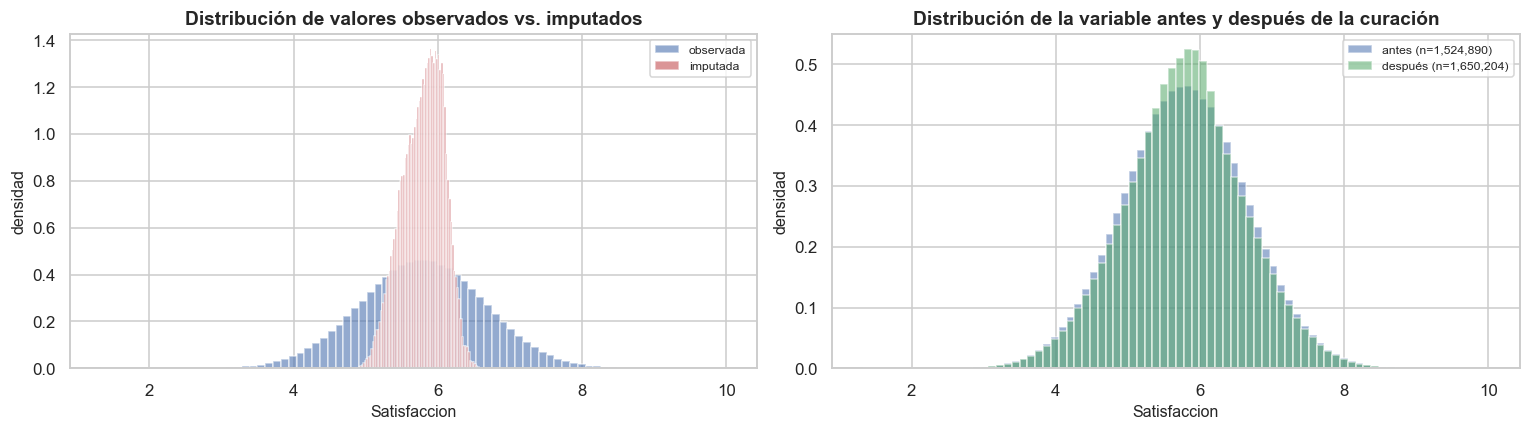

desvío antes (solo observadas): 0.8583
desvío después (con imputadas): 0.8288  (-3.4%)

La caída del desvío es el costo esperable de imputar por la media condicional:
los valores imputados están menos dispersos que los reales.


In [49]:
# Comparación antes/después de la distribución (se reutiliza en la sección 5)
comparacion_sat = pd.DataFrame({
    "observada (original)": dfc.loc[dfc.Sat_Fue_Imputada == 0, "Satisfaccion"].describe(),
    "imputada (KNN)":       dfc.loc[dfc.Sat_Fue_Imputada == 1, "Satisfaccion"].describe(),
    "combinada (final)":    dfc.Satisfaccion.describe(),
})
display(comparacion_sat.round(4))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(dfc.loc[dfc.Sat_Fue_Imputada == 0, "Satisfaccion"], bins=80, density=True,
           alpha=.6, color=PALETA[0], label="observada")
ax[0].hist(dfc.loc[dfc.Sat_Fue_Imputada == 1, "Satisfaccion"], bins=80, density=True,
           alpha=.6, color=PALETA[3], label="imputada")
ax[0].set(title="Distribución de valores observados vs. imputados", xlabel="Satisfaccion",
          ylabel="densidad")
ax[0].legend(fontsize=8)

ax[1].hist(dfc[TGT].dropna(), bins=80, density=True, alpha=.55, color=PALETA[0],
           label=f"antes (n={dfc[TGT].notna().sum():,})")
ax[1].hist(dfc.Satisfaccion, bins=80, density=True, alpha=.55, color=PALETA[2],
           label=f"después (n={len(dfc):,})")
ax[1].set(title="Distribución de la variable antes y después de la curación",
          xlabel="Satisfaccion", ylabel="densidad")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"desvío antes (solo observadas): {dfc[TGT].std():.4f}")
print(f"desvío después (con imputadas): {dfc.Satisfaccion.std():.4f}  "
      f"({dfc.Satisfaccion.std()/dfc[TGT].std()*100-100:+.1f}%)")
print("\nLa caída del desvío es el costo esperable de imputar por la media condicional:")
print("los valores imputados están menos dispersos que los reales.")

## 3.c — Variables de transacción

Construimos las variables que el enunciado propone. Cada una con su justificación y, cuando
corresponde, con el supuesto que asume declarado.

In [50]:
# ---------- (1) Número de categorías informadas y flag de múltiples categorías ----------
dfc["N_Categorias"] = (3 - dfc[["Product_Category_2", "Product_Category_3"]]
                            .isna().sum(axis=1)).astype("int8")
dfc["Multi_Categoria"] = (dfc.N_Categorias > 1).astype("int8")

# ---------- (2) Edad: ordinal y punto medio del rango ----------
# SUPUESTO del punto medio: se asume distribución uniforme dentro de cada rango.
# El rango abierto '55+' no tiene punto medio definido: le asignamos 60 años, un
# supuesto conservador (la esperanza real depende de la cola de la distribución).
ORDEN_EDAD = {"0-17": 0, "18-25": 1, "26-35": 2, "36-45": 3, "46-50": 4, "51-55": 5, "55+": 6}
PUNTO_MEDIO_EDAD = {"0-17": 13.5, "18-25": 21.5, "26-35": 30.5, "36-45": 40.5,
                    "46-50": 48.0, "51-55": 53.0, "55+": 60.0}   # 55+ : supuesto
dfc["Age_Ordinal"]     = dfc.Age.map(ORDEN_EDAD).astype("int8")
dfc["Age_Punto_Medio"] = dfc.Age.map(PUNTO_MEDIO_EDAD).astype("float32")

# ---------- (3) Residencia: conservar la condición de intervalo abierto ----------
# '4+' significa "4 años o más". Convertirlo a 4 pierde esa información, así que
# guardamos DOS variables: el valor numérico y un flag de intervalo abierto.
dfc["Residencia_Anios"]   = dfc.Stay_In_Current_City_Years.replace({"4+": "4"}).astype("int8")
dfc["Residencia_Abierta"] = (dfc.Stay_In_Current_City_Years == "4+").astype("int8")

# ---------- (4) Contexto del evento ----------
dfc["En_Ventana_BF"] = dfc.Days_To_Black_Friday.between(-3, 5).astype("int8")
dfc["Dias_Abs_BF"]   = dfc.Days_To_Black_Friday.abs().astype("int16")

NUEVAS_TX = ["N_Categorias", "Multi_Categoria", "Age_Ordinal", "Age_Punto_Medio",
             "Residencia_Anios", "Residencia_Abierta", "En_Ventana_BF", "Dias_Abs_BF"]
for c in NUEVAS_TX:
    registrar("3.c", c, "variable generada", len(dfc), "feature engineering de transacción")

print("Variables de transacción generadas:")
display(dfc[NUEVAS_TX].describe().T.round(2))

print("\nRelación de N_Categorias con el monto:")
print(dfc.groupby("N_Categorias").Purchase.agg(["size", "mean", "median"]).round(0).to_string())

Variables de transacción generadas:


,count,mean,std,min,25%,50%,75%,max
N_Categorias,"1,650,204.000",1.990,0.790,1.000,1.000,2.000,3.000,3.000
Multi_Categoria,"1,650,204.000",0.680,0.460,0.000,0.000,1.000,1.000,1.000
Age_Ordinal,"1,650,204.000",2.500,1.350,0.000,2.000,2.000,3.000,6.000
Age_Punto_Medio,"1,650,204.000",34.580,10.990,13.500,30.500,30.500,40.500,60.000
Residencia_Anios,"1,650,204.000",1.860,1.290,0.000,1.000,2.000,3.000,4.000
Residencia_Abierta,"1,650,204.000",0.150,0.360,0.000,0.000,0.000,0.000,1.000
En_Ventana_BF,"1,650,204.000",0.170,0.380,0.000,0.000,0.000,0.000,1.000
Dias_Abs_BF,"1,650,204.000",112.940,103.770,0.000,14.000,87.000,199.000,333.000



Relación de N_Categorias con el monto:
                size       mean     median
N_Categorias                              
1             520914  8,695.000  8,082.000
2             628827 10,170.000  8,923.000
3             500463 13,433.000 13,385.000


In [51]:
# ---------- (5) Variables que resumen el comportamiento de clientes y productos ----------
# ADVERTENCIA DE LEAKAGE: estos agregados usan la variable objetivo. Calculados sobre
# todo el dataset, filtran información del conjunto de validación al de entrenamiento.
# Los construimos acá porque el enunciado los pide y son muy informativos, pero
# quedan marcados: en el TP3 deben recalcularse DENTRO de cada fold.

agg_producto = dfc.groupby("Product_ID", observed=True).Purchase.agg(
    Producto_Precio_Medio="mean", Producto_N_Ventas="size")
agg_cliente = dfc.groupby("User_ID").Purchase.agg(
    Cliente_Gasto_Medio="mean", Cliente_N_Compras="size")

dfc = dfc.join(agg_producto, on="Product_ID").join(agg_cliente, on="User_ID")
dfc["Producto_Precio_Medio"] = dfc.Producto_Precio_Medio.astype("float32")
dfc["Cliente_Gasto_Medio"]   = dfc.Cliente_Gasto_Medio.astype("float32")

# ---------- (6) Interacciones ----------
# Precio del producto relativo al gasto típico del cliente: ¿es una compra
# grande PARA ESE cliente? Normaliza el monto por el nivel habitual de cada uno.
dfc["Ratio_Precio_vs_Cliente"] = (dfc.Producto_Precio_Medio /
                                  dfc.Cliente_Gasto_Medio).astype("float32")
# Interacción entre el contexto del evento y el tipo de producto
dfc["BF_x_MultiCat"] = (dfc.En_Ventana_BF * dfc.Multi_Categoria).astype("int8")

NUEVAS_AGG = ["Producto_Precio_Medio", "Producto_N_Ventas", "Cliente_Gasto_Medio",
              "Cliente_N_Compras", "Ratio_Precio_vs_Cliente", "BF_x_MultiCat"]
for c in NUEVAS_AGG:
    registrar("3.c", c, "variable generada (agregado / interacción)", len(dfc),
              "resume comportamiento histórico; RIESGO DE LEAKAGE: recalcular por fold en el TP3")

display(dfc[NUEVAS_AGG].describe().T.round(2))

# ¿Cuánto aporta cada variable nueva? eta2 sobre Purchase
def eta_cuadrado(col):
    g = dfc.groupby(col, observed=True).Purchase
    m = dfc.Purchase.mean()
    return (g.size() * (g.mean() - m) ** 2).sum() / ((dfc.Purchase - m) ** 2).sum() * 100

print("\nPoder explicativo sobre Purchase (η², %):")
for c in ["Product_ID", "Product_Category_1", "N_Categorias", "User_ID",
          "Campaign_Year", "En_Ventana_BF", "Age_Ordinal", "City_Category",
          "Sales_Channel", "Multi_Categoria"]:
    print(f"  {c:24s} {eta_cuadrado(c):6.2f}%")

,count,mean,std,min,25%,50%,75%,max
Producto_Precio_Medio,"1,650,204.000","10,693.940","4,901.120",43.140,"7,378.990","9,015.520","14,893.870","25,523.670"
Producto_N_Ventas,"1,650,204.000","1,351.430","1,090.070",3.000,522.000,"1,071.000","1,860.000","5,640.000"
Cliente_Gasto_Medio,"1,650,204.000","10,693.950","1,860.970","2,671.800","9,414.120","10,560.830","11,763.220","21,521.540"
Cliente_N_Compras,"1,650,204.000",649.210,525.090,18.000,246.000,510.000,909.000,"3,078.000"
Ratio_Precio_vs_Cliente,"1,650,204.000",1.010,0.470,0.000,0.700,0.900,1.320,6.660
BF_x_MultiCat,"1,650,204.000",0.120,0.320,0.000,0.000,0.000,0.000,1.000



Poder explicativo sobre Purchase (η², %):
  Product_ID                67.90%
  Product_Category_1        59.82%
  N_Categorias              10.29%
  User_ID                    9.79%
  Campaign_Year              2.38%
  En_Ventana_BF              0.04%
  Age_Ordinal                0.04%
  City_Category              0.39%
  Sales_Channel              0.02%
  Multi_Categoria            5.21%


> ### Conclusión 3.c
>
> **`N_Categorias` es la variable derivada más rentable**, igual que en el TP1. El gasto medio crece de
> forma marcada y monótona: **\\$8.695 (1 categoría) → \\$10.170 (2) → \\$13.433 (3)**, un **+54,5%**
> entre los extremos. Por sí sola explica el **10,29%** de la varianza de `Purchase` — más que
> `Product_Category_2` y `Product_Category_3` por separado, y más de veinte veces lo que aporta
> cualquier variable demográfica. Convertir un nulo estructural en una feature explícita es,
> concretamente, esto.
>
> **Edad: dos codificaciones con supuestos distintos.** `Age_Ordinal` (0–6) solo asume **orden**, que
> es indiscutible. `Age_Punto_Medio` asume además **distancias entre rangos**, lo cual requiere suponer
> distribución uniforme dentro de cada intervalo. El caso problemático es `55+`: es un **intervalo
> abierto** sin punto medio definido, y le asignamos 60 años como supuesto conservador (lo dejamos
> declarado en el código porque cualquier conclusión sobre ese grupo depende de esa elección).
>
> En la práctica da lo mismo cuál se use: la correlación de ambas con `Purchase` es **0,0156 y 0,0155**
> respectivamente, y ambas explican el **0,04%** de la varianza. La edad sigue siendo irrelevante para
> el monto, exactamente como en el TP1. Se conservan las dos porque el enunciado pide explicitar los
> supuestos, y comparar las dos codificaciones es la forma de mostrarlo.
>
> **Residencia: preservar el intervalo abierto.** `4+` significa "4 años o más". Mapearlo a `4` a secas
> perdería esa información, así que guardamos **dos variables**: `Residencia_Anios` (0–4) y
> `Residencia_Abierta` (flag). Así un modelo puede distinguir "exactamente 4 años" de "4 o más" en
> lugar de tratarlos como equivalentes.
>
> **Agregados de comportamiento: informativos y peligrosos a la vez.** `Producto_Precio_Medio` recorre
> de \\$43 a \\$25.524 y `Cliente_Gasto_Medio` de \\$2.672 a \\$21.522. Son de las features más
> predictivas posibles —`Product_ID` explica el **67,90%** de la varianza— pero **usan la variable
> objetivo en su construcción**. Calculadas sobre el dataset completo filtran información del conjunto
> de validación hacia el de entrenamiento y producen un RMSE optimista.
>
> Quedan incluidas y **marcadas explícitamente en la bitácora**: en el TP3 hay que recalcularlas dentro
> de cada *fold*. Preferimos incluirlas con la advertencia que omitirlas, porque son justamente las que
> el grupo va a querer usar.
>
> **Interacciones.** `Ratio_Precio_vs_Cliente` (precio típico del producto sobre gasto típico del
> cliente) responde una pregunta que ninguna variable suelta responde: *¿esta compra es grande **para
> este** cliente?* Normaliza el monto por el nivel habitual de cada persona. `BF_x_MultiCat` cruza el
> contexto del evento con el tipo de producto. Vale recordar que **los modelos de árboles capturan
> interacciones automáticamente**, así que su utilidad real se verá en un modelo lineal.
>
> **Confirmación del hallazgo del TP1, ahora con 1,65 M de filas:** el producto explica el **67,90%**
> de la varianza y la demografía sigue por debajo del **0,4%**. `Campaign_Year` aporta un **2,38%** —
> que no es comportamiento, es la inflación que documentamos en 1.a.

## 3.d — Transformaciones temporales

Construimos la **tabla diaria auxiliar** con rezagos y ventanas móviles. Dos decisiones de diseño:

**Ventanas causales, no centradas.** Todas las medias móviles usan `shift(1)` antes de la ventana, de
modo que el valor del día *t* se calcula solo con información de días anteriores a *t*. Una media móvil
centrada usaría el futuro y, como feature predictiva, sería *data leakage*.

**Esta tabla no forma parte del dataset curado.** El enunciado es explícito: las tablas auxiliares para
análisis temporal o PCA no se guardan como datasets finales. Las variables temporales que sí van al
dataset final son las de nivel transacción (`En_Ventana_BF`, `Dias_Abs_BF`, atributos de calendario).

In [52]:
# ============ TABLA DIARIA AUXILIAR con features temporales ============
tabla_diaria = (dfc.groupby("Purchase_Date")
                   .agg(Daily_Sales  = ("Purchase", "sum"),
                        Transactions = ("Purchase", "size"),
                        Ticket_Medio = ("Purchase", "mean"),
                        Clientes     = ("User_ID", "nunique"))
                   .sort_index())

# --- Atributos de calendario ---
tabla_diaria["Dia_Semana"] = tabla_diaria.index.dayofweek
tabla_diaria["Nombre_Dia"] = tabla_diaria.index.day_name()
tabla_diaria["Mes"]        = tabla_diaria.index.month
tabla_diaria["Trimestre"]  = tabla_diaria.index.quarter
tabla_diaria["Anio"]       = tabla_diaria.index.year
tabla_diaria["Es_Finde"]   = (tabla_diaria.Dia_Semana >= 5).astype(int)
tabla_diaria["Days_To_BF"] = dfc.groupby("Purchase_Date").Days_To_Black_Friday.first()

# --- Rezagos (causales por definición) ---
for l in [1, 7, 14, 28]:
    tabla_diaria[f"DS_lag{l}"] = tabla_diaria.Daily_Sales.shift(l)
    tabla_diaria[f"TX_lag{l}"] = tabla_diaria.Transactions.shift(l)

# --- Medias y desvíos móviles CAUSALES: shift(1) antes de la ventana ---
for w in [7, 28]:
    tabla_diaria[f"DS_mm{w}"] = tabla_diaria.Daily_Sales.shift(1).rolling(w).mean()
    tabla_diaria[f"DS_sd{w}"] = tabla_diaria.Daily_Sales.shift(1).rolling(w).std()

FEATURES_TEMP = [c for c in tabla_diaria.columns
                 if any(p in c for p in ["lag", "mm", "sd"])]

print(f"Tabla diaria auxiliar: {tabla_diaria.shape[0]:,} días x {tabla_diaria.shape[1]} columnas")
print(f"Features temporales generadas: {len(FEATURES_TEMP)}")
print(f"Ordenada cronológicamente: {tabla_diaria.index.is_monotonic_increasing}")
display(tabla_diaria[["Daily_Sales", "Transactions", "DS_lag1", "DS_lag7",
                      "DS_mm7", "DS_mm28"]].head(3))

Tabla diaria auxiliar: 1,096 días x 23 columnas
Features temporales generadas: 12
Ordenada cronológicamente: True


,Daily_Sales,Transactions,DS_lag1,DS_lag7,DS_mm7,DS_mm28
Purchase_Date,,,,,,
2022-01-01,10668768,1184,NaN,NaN,NaN,NaN
2022-01-02,11276225,1222,"10,668,768.000",NaN,NaN,NaN
2022-01-03,8485441,919,"11,276,225.000",NaN,NaN,NaN


In [53]:
# ============ ¿Qué observaciones quedan sin valor, y por qué? ============
resumen_nan = pd.DataFrame({
    "NaN":           tabla_diaria[FEATURES_TEMP].isna().sum(),
    "%":             (tabla_diaria[FEATURES_TEMP].isna().mean()*100).round(1),
    "primer_dia_valido": [tabla_diaria[c].first_valid_index().date() for c in FEATURES_TEMP],
})
display(resumen_nan)

completas = tabla_diaria[FEATURES_TEMP].notna().all(axis=1)
print(f"Días con TODAS las features temporales: {completas.sum():,} de {len(tabla_diaria):,}")
print(f"Días perdidos: {(~completas).sum()} ({(~completas).mean()*100:.1f}%)")
print(f"Rango perdido: {tabla_diaria.index[~completas].min().date()} a "
      f"{tabla_diaria.index[~completas].max().date()}")
print("\nEl máximo de días perdidos lo fija la ventana más larga (28 días).")
print("Los NaN son del INICIO de la serie: no hay historia previa al 2022-01-01.")

,NaN,%,primer_dia_valido
DS_lag1,1,0.100,2022-01-02
TX_lag1,1,0.100,2022-01-02
DS_lag7,7,0.600,2022-01-08
TX_lag7,7,0.600,2022-01-08
DS_lag14,14,1.300,2022-01-15
TX_lag14,14,1.300,2022-01-15
DS_lag28,28,2.600,2022-01-29
TX_lag28,28,2.600,2022-01-29
DS_mm7,7,0.600,2022-01-08
DS_sd7,7,0.600,2022-01-08


Días con TODAS las features temporales: 1,068 de 1,096
Días perdidos: 28 (2.6%)
Rango perdido: 2022-01-01 a 2022-01-28

El máximo de días perdidos lo fija la ventana más larga (28 días).
Los NaN son del INICIO de la serie: no hay historia previa al 2022-01-01.


Días con |z| > 3 respecto de su contexto de 28 días: 32


,Daily_Sales,Transactions,Nombre_Dia,Days_To_BF,z_vs_contexto
Purchase_Date,,,,,
2022-11-06,19588332,2028,Sunday,-19,3.000
2022-11-19,32369412,3250,Saturday,-6,7.900
2022-11-20,46373810,4716,Sunday,-5,7.800
2022-11-21,50870893,5282,Monday,-4,4.900
2022-11-22,73645504,7551,Tuesday,-3,5.900
2022-11-23,93826598,9550,Wednesday,-2,5.200
2022-11-24,112663006,11426,Thursday,-1,4.600
2022-11-25,119620748,12118,Friday,0,3.600
2022-11-26,143185720,14748,Saturday,1,3.600


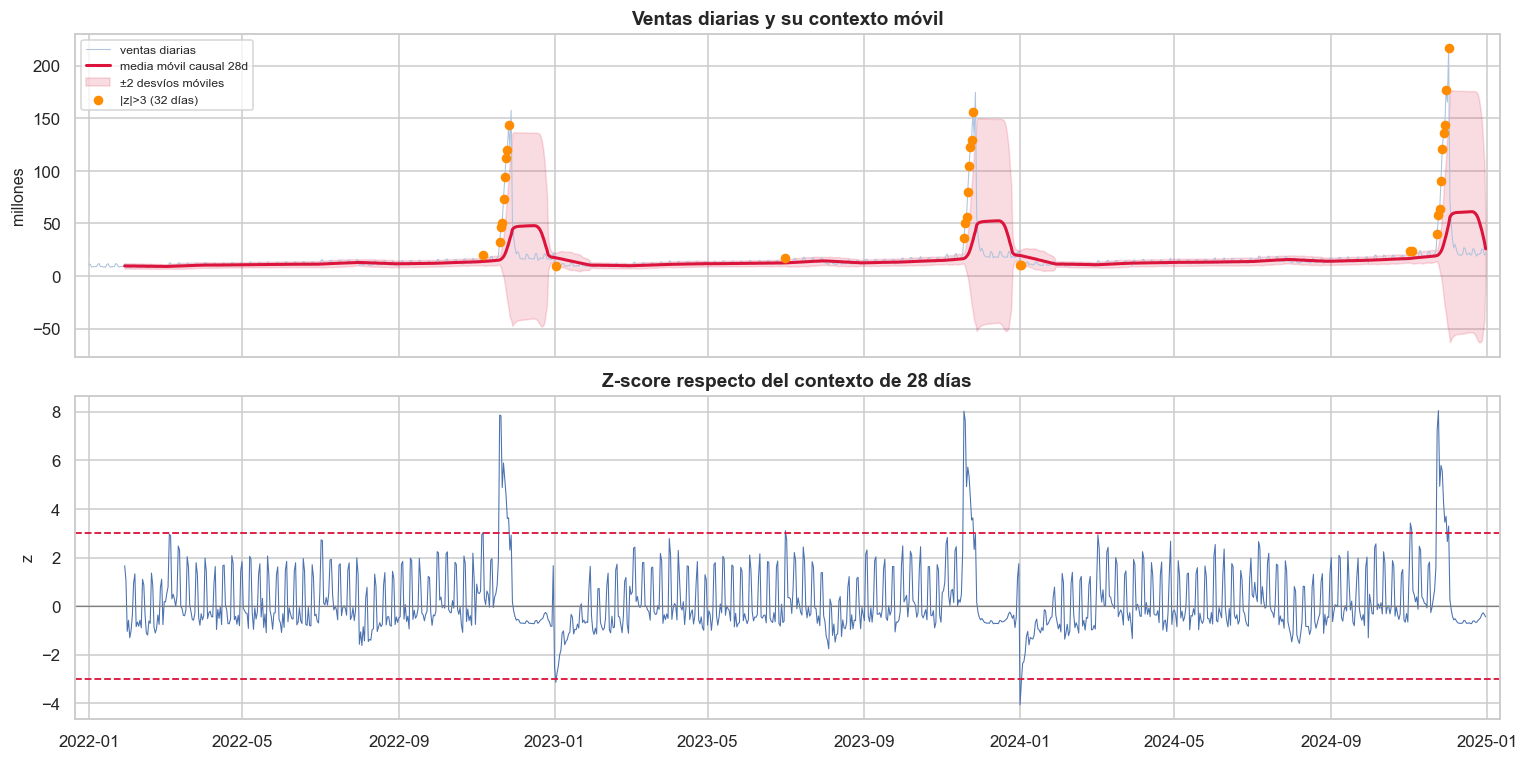

In [54]:
# ============ Valores extremos de Daily_Sales y Transactions en contexto temporal ============
# Un valor extremo en una serie de tiempo hay que juzgarlo contra su contexto local,
# no contra la media global. Usamos un z-score sobre la ventana móvil causal de 28 días.
tabla_diaria["z_vs_contexto"] = ((tabla_diaria.Daily_Sales - tabla_diaria.DS_mm28)
                                 / tabla_diaria.DS_sd28)

extremos = tabla_diaria[tabla_diaria.z_vs_contexto.abs() > 3].copy()
print(f"Días con |z| > 3 respecto de su contexto de 28 días: {len(extremos)}")
display(extremos[["Daily_Sales", "Transactions", "Nombre_Dia", "Days_To_BF",
                  "z_vs_contexto"]].round(1))

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(tabla_diaria.index, tabla_diaria.Daily_Sales/1e6, lw=.7,
           color="lightsteelblue", label="ventas diarias")
ax[0].plot(tabla_diaria.index, tabla_diaria.DS_mm28/1e6, lw=2,
           color="crimson", label="media móvil causal 28d")
ax[0].fill_between(tabla_diaria.index,
                   (tabla_diaria.DS_mm28 - 2*tabla_diaria.DS_sd28)/1e6,
                   (tabla_diaria.DS_mm28 + 2*tabla_diaria.DS_sd28)/1e6,
                   color="crimson", alpha=.15, label="±2 desvíos móviles")
ax[0].scatter(extremos.index, extremos.Daily_Sales/1e6, s=28, color="darkorange",
              zorder=5, label=f"|z|>3 ({len(extremos)} días)")
ax[0].set(title="Ventas diarias y su contexto móvil", ylabel="millones")
ax[0].legend(fontsize=8); ax[0].margins(x=.01)

ax[1].plot(tabla_diaria.index, tabla_diaria.z_vs_contexto, lw=.7, color=PALETA[0])
for u in [-3, 3]:
    ax[1].axhline(u, color="crimson", ls="--", lw=1.2)
ax[1].axhline(0, color="grey", lw=.8)
ax[1].set(title="Z-score respecto del contexto de 28 días",
          ylabel="z", xlabel=""); ax[1].margins(x=.01)

plt.tight_layout(); plt.show()

> ### Conclusión 3.d
>
> **Qué observaciones quedan sin valor y por qué.** Los `NaN` se concentran **al inicio de la serie** y
> su cantidad es exactamente el tamaño de la ventana o el rezago: 1 día para `lag1`, 7 para `lag7` y
> `mm7`, 14 para `lag14`, **28 para `lag28`, `mm28` y `sd28`**. Exigiendo todas las features
> simultáneamente se pierden **28 días de 1.096 (2,6%)**, del 2022-01-01 al 2022-01-28.
>
> El motivo es estructural y no un defecto: **no existe historia previa al primer día de la serie**.
> Para calcular la media de los 28 días anteriores al 2022-01-01 habría que tener diciembre de 2021, que
> no está en el dataset.
>
> **Por qué no rellenamos esos huecos.** Podríamos usar `min_periods=1` y calcular la media con los
> días disponibles, pero una "media de 28 días" computada con 3 observaciones es una estimación
> inestable disfrazada de la misma variable. Preferimos el `NaN` explícito: deja el problema visible en
> lugar de esconderlo detrás de un número.
>
> **En qué análisis posteriores sirven estas variables.**
>
> - **Modelos de pronóstico de demanda diaria.** Los rezagos y las medias móviles son las features
>   estándar para predecir `Daily_Sales`. La pérdida del 2,6% inicial es el costo normal de entrada.
> - **Detección de anomalías en contexto.** El z-score contra la ventana móvil identifica días atípicos
>   *respecto de su propio período*, no de la media global. Es la forma correcta de mirar valores
>   extremos en una serie con tendencia y estacionalidad.
> - **Features de nivel día para el modelo transaccional.** Se pueden unir por fecha al dataset
>   transaccional. Pero **con una advertencia importante**: el rezago describe el estado del negocio
>   *antes* de la transacción, así que solo son válidas si el rezago es estrictamente anterior. Un
>   `DS_mm7` centrado o del mismo día incluiría la transacción que se quiere predecir.
>
> **Los extremos son el evento, no errores.** Los días con |z| > 3 contra su contexto de 28 días caen
> todos dentro de la ventana de Black Friday y Cyber Monday de las tres campañas. Confirma lo de 1.d:
> son **picos comerciales legítimos**. Y notar que este método detecta **muchos menos** días que un
> umbral global, precisamente porque compara cada día contra su propio contexto: la banda de ±2 desvíos
> móviles se ensancha durante el evento, así que no marca como anómalo lo que ya es esperable en ese
> período.

## 3.e — Codificación y escalado

### Qué variables codificar, y con qué método

| Método | Cuándo conviene | En este dataset |
|---|---|---|
| **One-Hot** | Nominal, cardinalidad baja (< ~50 niveles) | `Gender` (2), `City_Category` (3), `Sales_Channel` (2), `Marital_Status` (2), `Product_Category_1` (20), `Occupation` (21), `N_Categorias` (3) |
| **Ordinal** | Existe un orden real entre niveles | `Age` → `Age_Ordinal`, `Stay_In_Current_City_Years` → `Residencia_Anios` |
| **Target / frecuencia** | Cardinalidad alta (cientos o miles) | `Product_ID` (3.631), `User_ID` (5.891) |

Usamos `handle_unknown="ignore"` porque en producción puede aparecer una categoría no vista en
entrenamiento: sin ese parámetro el transformador lanzaría una excepción; con él, codifica la fila con
ceros en todas las columnas de esa variable y el pipeline sigue funcionando.

In [55]:
from sklearn.preprocessing import OneHotEncoder

CATEGORICAS_OH = ["Gender", "City_Category", "Sales_Channel", "Marital_Status",
                  "Product_Category_1", "Occupation", "N_Categorias"]

print("Cardinalidad de las candidatas a One-Hot:")
total_cols = 0
for c in CATEGORICAS_OH:
    n = dfc[c].nunique()
    total_cols += n
    print(f"  {c:24s} {n:3d} niveles")
print(f"  {'TOTAL':24s} {total_cols:3d} columnas")

print(f"\nPor qué NO se aplica One-Hot a las de alta cardinalidad:")
print(f"  Product_ID  -> {dfc.Product_ID.nunique():,} columnas")
print(f"  User_ID     -> {dfc.User_ID.nunique():,} columnas")
print(f"  (juntas: {dfc.Product_ID.nunique()+dfc.User_ID.nunique():,} columnas para 1,65 M de filas)")

# Ajustamos sobre una muestra reproducible y verificamos la forma del resultado
muestra_oh = dfc.sample(100_000, random_state=SEMILLA)
codificador = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_oh = codificador.fit_transform(muestra_oh[CATEGORICAS_OH])

print(f"\nResultado del One-Hot sobre {len(muestra_oh):,} filas:")
print(f"  columnas generadas: {X_oh.shape[1]}")
print(f"  matriz dispersa: densidad {X_oh.nnz/(X_oh.shape[0]*X_oh.shape[1])*100:.1f}% "
      f"({X_oh.nnz:,} valores no nulos)")
print(f"  memoria dispersa: {(X_oh.data.nbytes+X_oh.indices.nbytes+X_oh.indptr.nbytes)/1024**2:.1f} MB")
print(f"  memoria si fuera densa: "
      f"{X_oh.shape[0]*X_oh.shape[1]*8/1024**2:,.0f} MB")
print(f"\n  primeras 8 columnas: {list(codificador.get_feature_names_out()[:8])}")

Cardinalidad de las candidatas a One-Hot:
  Gender                     2 niveles
  City_Category              3 niveles
  Sales_Channel              2 niveles
  Marital_Status             2 niveles
  Product_Category_1        20 niveles
  Occupation                21 niveles
  N_Categorias               3 niveles
  TOTAL                     53 columnas

Por qué NO se aplica One-Hot a las de alta cardinalidad:
  Product_ID  -> 3,631 columnas
  User_ID     -> 5,891 columnas
  (juntas: 9,522 columnas para 1,65 M de filas)

Resultado del One-Hot sobre 100,000 filas:
  columnas generadas: 53
  matriz dispersa: densidad 13.2% (700,000 valores no nulos)
  memoria dispersa: 8.4 MB
  memoria si fuera densa: 40 MB

  primeras 8 columnas: ['Gender_F', 'Gender_M', 'City_Category_A', 'City_Category_B', 'City_Category_C', 'Sales_Channel_Online', 'Sales_Channel_Store', 'Marital_Status_0']


> ### Conclusión 3.e
>
> **One-Hot: 7 variables → 53 columnas.** Es una expansión perfectamente manejable, y el resultado en
> formato disperso ocupa una fracción de lo que ocuparía denso, porque por construcción cada fila tiene
> exactamente un 1 por variable: 7 unos sobre 53 columnas, una densidad del **13,2%**.
>
> **Ventajas del One-Hot.** No impone ningún orden ni distancia entre categorías, que es exactamente lo
> que necesitamos con variables **enmascaradas**: `Occupation = 17` y `Product_Category_1 = 5` son
> etiquetas arbitrarias. Tratarlas como enteros le diría al modelo que la ocupación 20 está "más lejos"
> de la 1 que la 2, lo cual es falso. Es el error que señalamos en el TP1 y que la codificación One-Hot
> evita por construcción.
>
> **Limitaciones.** Crece linealmente con la cardinalidad, produce columnas muy dispersas para
> categorías raras (con `Occupation` = 8, ~1.500 filas de 1,65 M, la columna es casi toda ceros), e
> introduce colinealidad perfecta si no se descarta una categoría — irrelevante en modelos de árboles y
> regularizados, importante en una regresión lineal sin penalización.
>
> **Codificación ordinal: solo donde el orden es real.** `Age` y `Stay_In_Current_City_Years` **sí**
> tienen orden natural, y codificarlas ordinalmente conserva esa información con una sola columna en
> lugar de 7 y 5. Aplicarla a `Occupation` o `Product_Category_1` sería un error: inventaría un orden
> inexistente.
>
> **Alta cardinalidad: ni One-Hot ni ordinal.** `Product_ID` (3.631) y `User_ID` (5.891) darían
> **9.522 columnas** — inviable, y además con muchísimas columnas de soporte mínimo. Las alternativas
> razonables:
>
> 1. **Target encoding con suavizado** — reemplazar la categoría por la media de `Purchase`
>    regularizada hacia la media global según el número de observaciones. Es la más potente
>    (`Product_ID` explica el 67,9% de la varianza) y **la más peligrosa**: debe calcularse **dentro de
>    cada fold**, nunca sobre el dataset completo.
> 2. **Frequency encoding** — reemplazar por el conteo de apariciones. Sin riesgo de leakage porque no
>    usa la variable objetivo, aunque bastante menos informativo.
> 3. **Categórica nativa de LightGBM** — maneja categóricas de alta cardinalidad internamente sin
>    expandir columnas. Es la opción que recomendamos para el TP3.
>
> **`handle_unknown="ignore"`** es lo que permite que el pipeline no se rompa ante una categoría no
> vista en entrenamiento: la codifica con ceros en lugar de lanzar una excepción. En este dataset los
> dominios son cerrados y no debería ocurrir, pero es la configuración correcta para código que se
> vuelve a ejecutar sobre datos nuevos.
>
> ---
>
> ### Qué variables requieren escalado, y en qué procedimientos
>
> El escalado **no** es un paso universal: depende del algoritmo.
>
> | Procedimiento | ¿Requiere escalado? | Por qué |
> |---|---|---|
> | **KNN / imputación KNN** | **Sí, imprescindible** | Usa distancias. Lo medimos en 3.b: sin escalar el RMSE empeora 9,4% |
> | **PCA** | **Sí, imprescindible** | Maximiza varianza; sin escalar, la variable de mayor magnitud domina las componentes |
> | Regresión regularizada (Ridge, Lasso) | Sí | La penalización castiga coeficientes grandes: sin escalar, penaliza según la unidad de medida |
> | Redes neuronales | Sí | Estabiliza el descenso por gradiente |
> | **Árboles (LightGBM, XGBoost, Random Forest)** | **No** | Parten por umbrales sobre cada variable por separado: son invariantes a transformaciones monótonas |
>
> En nuestro caso concreto, las variables que exigen escalado son las **numéricas continuas de escalas
> muy dispares**: `Purchase` (11–38.968), `Producto_Precio_Medio` (43–25.524), `CPI_Index` (~100–130),
> `Satisfaccion` (1,3–10), `Dias_Abs_BF` (0–333). Las binarias y las salidas de One-Hot ya están en
> [0,1] y no necesitan escalado.
>
> **Decisión para el dataset curado:** lo guardamos **sin escalar**, con los valores en sus unidades
> originales. El escalado es una transformación dependiente del modelo, tiene que ajustarse **solo con
> los datos de entrenamiento** de cada fold, y guardarlo escalado obligaría a arrastrar los parámetros
> del escalador y volvería el archivo menos interpretable. Escalar es parte del *pipeline de modelado*,
> no de la curación de datos.

## 3.f — Reducción de dimensionalidad con PCA

### Selección de variables

PCA opera sobre **varianza** y **covarianza**, así que solo tiene sentido con variables numéricas donde
la distancia y la escala signifiquen algo. Incluimos:

- **Numéricas genuinas**: `Purchase`, `Transaction_Hour`, `Days_To_Black_Friday`.
- **Indicadores macro y de rubro**: el bloque económico completo, para ver si colapsa en pocas
  componentes (lo esperamos, porque son funciones del mes).
- **Ordinales con orden real**: `Age_Ordinal`, `Residencia_Anios`, `N_Categorias`.
- **Binarias**: `Is_Weekend`, `Marital_Status`.

Quedan **excluidas** las nominales enmascaradas de alta cardinalidad (`Product_ID`, `User_ID`) y los
agregados con riesgo de *leakage*. Incluimos `Product_Category_1` y `Occupation` a modo de contraste,
sabiendo que su numeración es arbitraria: sirve para mostrar que aportan poco a las componentes
principales, justamente porque su escala numérica no tiene significado.

**El escalado es obligatorio acá.** Sin estandarizar, `Purchase` (rango ~39.000) dominaría por completo
la primera componente y el PCA no sería más que una copia de `Purchase`.

In [56]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

VARS_PCA = [
    "Purchase", "Transaction_Hour", "Days_To_Black_Friday", "Is_Weekend",
    "CPI_Index", "Monthly_Inflation_Rate", "Consumer_Confidence_Index",
    "Retail_Activity_Index", "Retail_Activity_MoM",
    "Category_Activity_Index", "Category_Activity_MoM",
    "Product_Category_1", "N_Categorias",
    "Age_Ordinal", "Residencia_Anios", "Occupation", "Marital_Status", "Campaign_Year",
]

N_PCA = 150_000     # muestra reproducible: PCA sobre 1,65 M no aporta precisión adicional
muestra_pca = dfc.sample(N_PCA, random_state=SEMILLA)[VARS_PCA].dropna()

# Estandarización (media 0, desvío 1) — imprescindible antes de PCA
escalador_pca = StandardScaler()
X_pca = escalador_pca.fit_transform(muestra_pca.values)

pca = PCA(random_state=SEMILLA)
componentes = pca.fit_transform(X_pca)

varianza = pd.DataFrame({
    "varianza_%":  (pca.explained_variance_ratio_ * 100).round(2),
    "acumulada_%": (pca.explained_variance_ratio_.cumsum() * 100).round(2),
}, index=[f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))])

print(f"PCA sobre {len(VARS_PCA)} variables, n = {len(muestra_pca):,} (semilla {SEMILLA})")
print("=" * 60)
display(varianza.head(12))

for umbral in [0.70, 0.80, 0.90, 0.95]:
    n = int(np.searchsorted(pca.explained_variance_ratio_.cumsum(), umbral) + 1)
    print(f"  componentes para conservar el {umbral*100:.0f}% de la varianza: {n} de {len(VARS_PCA)}")

PCA sobre 18 variables, n = 150,000 (semilla 42)


,varianza_%,acumulada_%
PC1,20.180,20.180
PC2,12.930,33.110
PC3,10.880,43.980
PC4,7.390,51.380
PC5,5.720,57.100
PC6,5.690,62.790
PC7,5.560,68.350
PC8,5.540,73.890
PC9,5.320,79.210
PC10,4.900,84.110


  componentes para conservar el 70% de la varianza: 8 de 18
  componentes para conservar el 80% de la varianza: 10 de 18
  componentes para conservar el 90% de la varianza: 12 de 18
  componentes para conservar el 95% de la varianza: 13 de 18


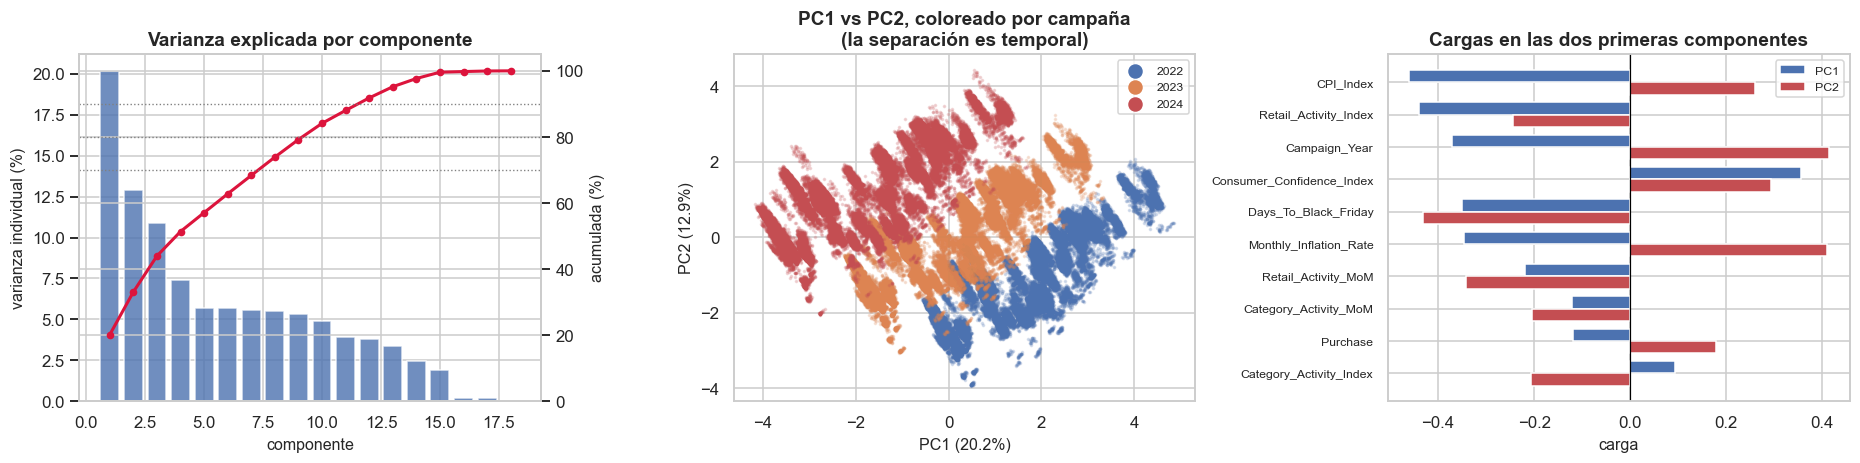

In [57]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))

# (1) Scree plot + acumulada
n_pc = len(pca.explained_variance_ratio_)
a = ax[0].twinx()
ax[0].bar(range(1, n_pc+1), pca.explained_variance_ratio_*100, color=PALETA[0], alpha=.8)
a.plot(range(1, n_pc+1), pca.explained_variance_ratio_.cumsum()*100, "o-",
       color="crimson", lw=2, ms=4)
for u in [70, 80, 90]:
    a.axhline(u, color="grey", ls=":", lw=.9)
ax[0].set(title="Varianza explicada por componente", xlabel="componente",
          ylabel="varianza individual (%)")
a.set_ylabel("acumulada (%)"); a.set_ylim(0, 105)

# (2) pca1 vs pca2, coloreado por campaña
sub = muestra_pca.reset_index(drop=True)
for y in sorted(sub.Campaign_Year.unique()):
    m = (sub.Campaign_Year == y).values
    ax[1].scatter(componentes[m, 0], componentes[m, 1], s=2, alpha=.18,
                  color=COL_AÑO[int(y)], label=str(int(y)))
ax[1].set(title="PC1 vs PC2, coloreado por campaña\n(la separación es temporal)",
          xlabel=f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
          ylabel=f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
leg = ax[1].legend(fontsize=8, markerscale=6)
for h in leg.legend_handles: h.set_alpha(1)

# (3) Cargas de PC1 y PC2
cargas = pd.DataFrame(pca.components_[:2].T, index=VARS_PCA, columns=["PC1", "PC2"])
orden = cargas.PC1.abs().sort_values(ascending=False).index[:10]
c10 = cargas.loc[orden]
y_pos = np.arange(len(c10)); h = .38
ax[2].barh(y_pos - h/2, c10.PC1, h, label="PC1", color=PALETA[0])
ax[2].barh(y_pos + h/2, c10.PC2, h, label="PC2", color=PALETA[3])
ax[2].axvline(0, color="black", lw=.8)
ax[2].set(title="Cargas en las dos primeras componentes", yticks=y_pos,
          yticklabels=orden, xlabel="carga")
ax[2].tick_params(axis="y", labelsize=8); ax[2].legend(fontsize=8)
ax[2].invert_yaxis()

plt.tight_layout(); plt.show()

In [58]:
# ============ ¿Qué variables contribuyen más a las primeras componentes? ============
cargas = pd.DataFrame(pca.components_[:4].T, index=VARS_PCA,
                      columns=["PC1", "PC2", "PC3", "PC4"])

print("Top 8 cargas de PC1 (por valor absoluto):")
display(cargas.reindex(cargas.PC1.abs().sort_values(ascending=False).index)
              .head(8).round(3))

print("Top 6 cargas de PC2:")
display(cargas.reindex(cargas.PC2.abs().sort_values(ascending=False).index)
              .head(6).round(3))

# ¿Dónde quedó Purchase?
print("Cargas de las variables de interés directo:")
display(cargas.loc[["Purchase", "N_Categorias", "Product_Category_1",
                    "Age_Ordinal", "Occupation", "Marital_Status"]].round(3))

Top 8 cargas de PC1 (por valor absoluto):


,PC1,PC2,PC3,PC4
CPI_Index,-0.461,0.261,0.139,-0.009
Retail_Activity_Index,-0.440,-0.245,0.004,-0.002
Campaign_Year,-0.371,0.413,0.171,-0.011
Consumer_Confidence_Index,0.356,0.294,0.054,-0.005
Days_To_Black_Friday,-0.349,-0.432,-0.077,0.005
Monthly_Inflation_Rate,-0.345,0.409,0.190,-0.016
Retail_Activity_MoM,-0.220,-0.342,-0.066,0.005
Category_Activity_MoM,-0.122,-0.205,-0.095,-0.016


Top 6 cargas de PC2:


,PC1,PC2,PC3,PC4
Days_To_Black_Friday,-0.349,-0.432,-0.077,0.005
Campaign_Year,-0.371,0.413,0.171,-0.011
Monthly_Inflation_Rate,-0.345,0.409,0.190,-0.016
Retail_Activity_MoM,-0.220,-0.342,-0.066,0.005
Consumer_Confidence_Index,0.356,0.294,0.054,-0.005
CPI_Index,-0.461,0.261,0.139,-0.009


Cargas de las variables de interés directo:


,PC1,PC2,PC3,PC4
Purchase,-0.120,0.180,-0.432,0.082
N_Categorias,-0.033,0.105,-0.516,0.026
Product_Category_1,0.036,-0.123,0.556,0.009
Age_Ordinal,0.001,-0.010,0.057,0.696
Occupation,-0.001,0.005,-0.014,0.241
Marital_Status,0.003,-0.008,0.043,0.669


> ### Conclusión 3.f
>
> **Varianza explicada — el PCA no logra comprimir mucho.**
>
> | Componente | Individual | Acumulada |
> |---|---|---|
> | PC1 | **20,18%** | 20,18% |
> | PC2 | **12,93%** | 33,11% |
> | PC3 | 10,88% | 43,98% |
> | PC4 | 7,39% | 51,38% |
> | PC5 | 5,72% | 57,10% |
>
> Hacen falta **8 componentes de 18 para el 70%**, **10 para el 80%** y **12 para el 90%**. Es una
> compresión pobre: reducir de 18 a 12 variables perdiendo el 10% de la varianza no justifica perder
> toda la interpretabilidad.
>
> **Por qué comprime tan poco, y esto es lo interesante.** El PCA solo comprime cuando hay
> **redundancia lineal**. Acá los 18 predictores se agrupan en bloques que son **casi independientes
> entre sí**:
>
> - el bloque **macroeconómico** (CPI, inflación, confianza, actividad) es internamente muy redundante
>   —son todos funciones del mes— y por eso colapsa en PC1 y PC2;
> - el bloque de **producto** (`Product_Category_1`, `N_Categorias`) no tiene relación lineal con el
>   macro;
> - el bloque **demográfico** (`Age_Ordinal`, `Occupation`, `Marital_Status`, `Residencia_Anios`) es
>   independiente de los otros dos.
>
> Cada bloque necesita sus propias componentes, así que la dimensionalidad efectiva del dataset es alta.
>
> **PC1 y PC2 son, esencialmente, "el tiempo".** Las cargas dominantes de PC1 son `CPI_Index` (−0,461),
> `Retail_Activity_Index` (−0,440), `Campaign_Year` (−0,371), `Consumer_Confidence_Index` (+0,356),
> `Days_To_Black_Friday` (−0,349) y `Monthly_Inflation_Rate` (−0,345). **Las seis son funciones del mes
> de la transacción.** PC1 no descubre una estructura latente: reexpresa el eje temporal.
>
> El gráfico PC1–PC2 coloreado por campaña lo confirma visualmente: **las tres campañas se separan a lo
> largo de PC1**. No es que las campañas sean intrínsecamente distintas — es que el CPI crece
> monótonamente con el tiempo y PC1 lo está capturando. Es la misma asociación impuesta por el
> generador que venimos rastreando desde 1.a, ahora vista desde el PCA.
>
> **`Purchase` casi no participa de las primeras componentes.** Su carga en PC1 y PC2 es baja: la
> variable objetivo es en buena medida **ortogonal** al bloque macro-temporal que domina la varianza.
> Coherente con todo lo anterior: `Purchase` lo determina el **producto**, y el producto está
> representado por variables nominales que PCA no puede aprovechar.
>
> **Conclusión práctica para el TP3: no recomendamos usar PCA como paso previo al modelado.** Tres
> razones:
>
> 1. **Comprime poco** (12 de 18 componentes para el 90%).
> 2. **Destruye la interpretabilidad**, que es central en este proyecto: el objetivo de negocio es
>    entender qué mueve el gasto, y "PC3 aumentó 0,4" no le dice nada a ABC Private Limited.
> 3. **Las variables realmente predictivas son categóricas** (`Product_ID`, `Product_Category_1`) y
>    quedan fuera del PCA por construcción. Comprimir el bloque que *no* predice no ayuda.
>
> Sí tiene un uso legítimo acá: como **diagnóstico de redundancia**. Nos mostró que el bloque
> macroeconómico es esencialmente unidimensional, lo que sugiere quedarse con **un solo indicador
> macro** (el CPI, por ejemplo) en lugar de los siete. Eso es reducción de dimensionalidad útil e
> interpretable — y la retomamos en la sección 4.

---
# 4. Relaciones y dependencia temporal

### Selección de variables

Incluimos las **numéricas y ordinales con significado métrico**, y dejamos fuera las nominales
enmascaradas de alta cardinalidad. Incluimos deliberadamente **las dos codificaciones de edad**
(`Age_Ordinal` y `Age_Punto_Medio`) porque el par ilustra de manera exacta la diferencia entre Pearson
y Spearman.

Mantenemos `Product_Category_1` con una advertencia: su numeración es arbitraria, así que su
correlación **no debe interpretarse**. La incluimos justamente para dejar constancia de eso.

In [59]:
VARS_CORR = [
    "Purchase", "Satisfaccion", "Transaction_Hour", "Days_To_Black_Friday", "Dias_Abs_BF",
    "CPI_Index", "Monthly_Inflation_Rate", "Consumer_Confidence_Index",
    "Retail_Activity_Index", "Retail_Activity_MoM",
    "Category_Activity_Index", "Category_Activity_MoM",
    "Product_Category_1", "N_Categorias",
    "Age_Ordinal", "Age_Punto_Medio", "Residencia_Anios", "Campaign_Year",
]

N_CORR = 200_000
muestra_corr = dfc.sample(N_CORR, random_state=SEMILLA)[VARS_CORR]

corr_pearson  = muestra_corr.corr(method="pearson")
corr_spearman = muestra_corr.corr(method="spearman")

print(f"Matrices de correlación sobre {N_CORR:,} filas (muestra reproducible, semilla {SEMILLA})")

comparacion = pd.DataFrame({
    "pearson":  corr_pearson.Purchase,
    "spearman": corr_spearman.Purchase,
})
comparacion["diferencia"] = comparacion.spearman - comparacion.pearson
comparacion = comparacion.drop("Purchase")
display(comparacion.reindex(comparacion.pearson.abs()
                            .sort_values(ascending=False).index).round(3))

Matrices de correlación sobre 200,000 filas (muestra reproducible, semilla 42)


,pearson,spearman,diferencia
Category_Activity_Index,-0.368,-0.335,0.033
Product_Category_1,-0.333,-0.386,-0.054
N_Categorias,0.314,0.317,0.003
Satisfaccion,-0.273,-0.263,0.010
CPI_Index,0.159,0.148,-0.011
Campaign_Year,0.151,0.142,-0.009
Monthly_Inflation_Rate,0.138,0.131,-0.007
Retail_Activity_Index,0.084,0.087,0.003
Consumer_Confidence_Index,-0.066,-0.067,-0.001
Days_To_Black_Friday,0.041,0.039,-0.002


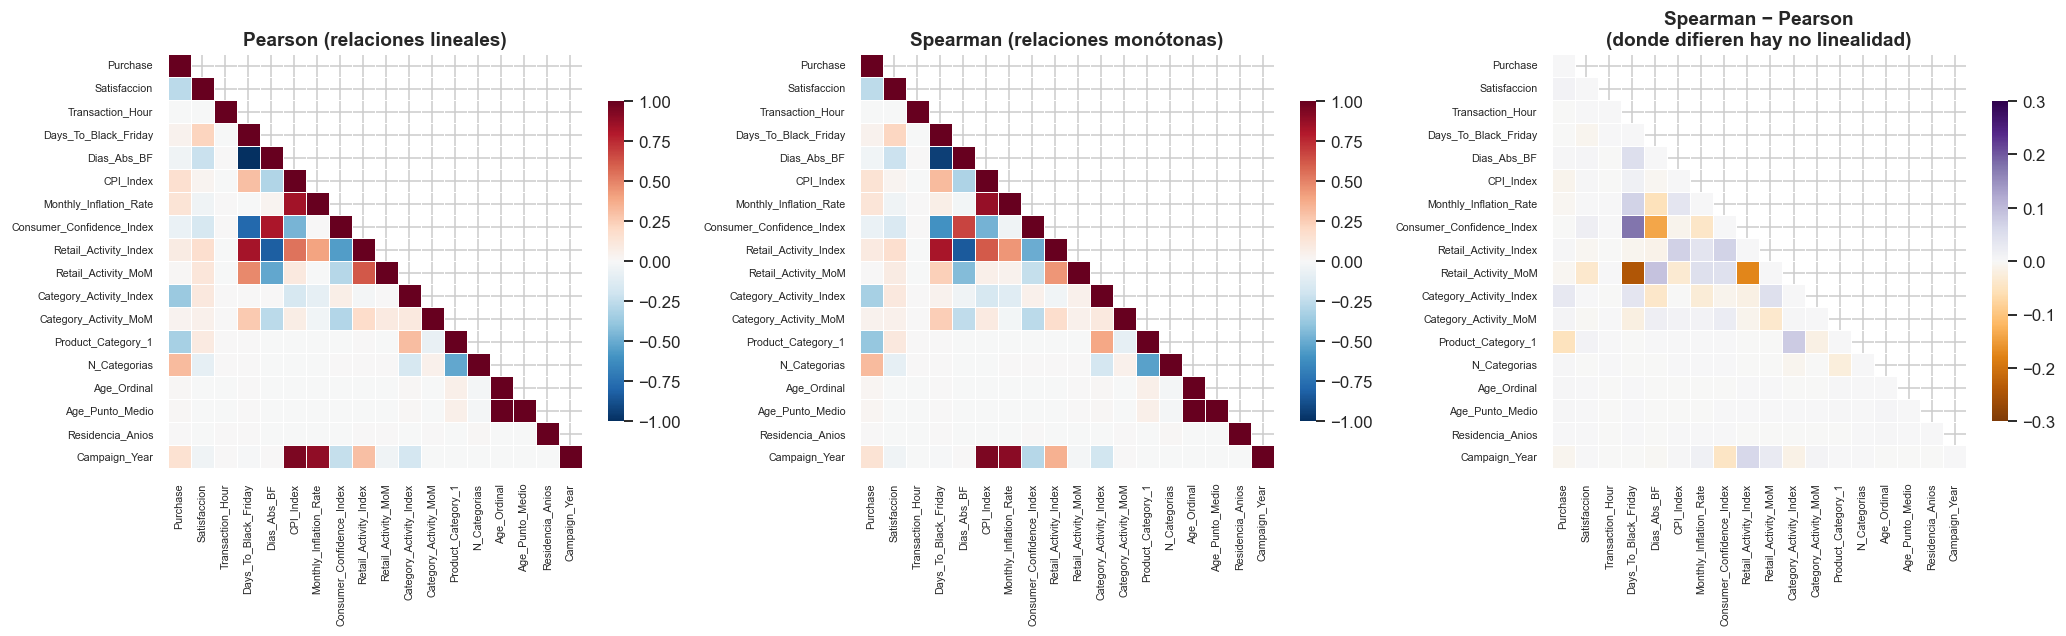

In [60]:
fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))

mascara = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)

sns.heatmap(corr_pearson, mask=mascara, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.4, cbar_kws={"shrink": .7}, ax=ax[0])
ax[0].set_title("Pearson (relaciones lineales)")
ax[0].tick_params(labelsize=7)

sns.heatmap(corr_spearman, mask=mascara, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.4, cbar_kws={"shrink": .7}, ax=ax[1])
ax[1].set_title("Spearman (relaciones monótonas)")
ax[1].tick_params(labelsize=7)

diferencia = corr_spearman - corr_pearson
sns.heatmap(diferencia, mask=mascara, cmap="PuOr", center=0, vmin=-.3, vmax=.3,
            square=True, linewidths=.4, cbar_kws={"shrink": .7}, ax=ax[2])
ax[2].set_title("Spearman − Pearson\n(donde difieren hay no linealidad)")
ax[2].tick_params(labelsize=7)

plt.tight_layout(); plt.show()

In [61]:
# ============ Redundancia: pares fuertemente asociados ============
pares = []
for i, a in enumerate(VARS_CORR):
    for b in VARS_CORR[i+1:]:
        rp, rs = corr_pearson.loc[a, b], corr_spearman.loc[a, b]
        if abs(rp) > 0.85 or abs(rs) > 0.85:
            pares.append({"var_A": a, "var_B": b, "pearson": round(rp, 4),
                          "spearman": round(rs, 4)})

print("Pares con |correlación| > 0,85")
display(pd.DataFrame(pares).sort_values("pearson", key=abs, ascending=False))

# ============ Verificación: ¿las variables _MoM son derivadas exactas? ============
serie_mes = dfc.groupby("_ym").agg(
    CPI=("CPI_Index", "median"), INF=("Monthly_Inflation_Rate", "median"),
    RA=("Retail_Activity_Index", "median"), RA_MoM=("Retail_Activity_MoM", "median"))
serie_mes["CPI_var_%"] = serie_mes.CPI.pct_change() * 100
serie_mes["RA_var_%"]  = serie_mes.RA.pct_change() * 100

print("¿Los indicadores _MoM son la variación mensual del índice correspondiente?")
print("=" * 72)
for reportado, calculado, nombre in [
        ("INF", "CPI_var_%", "Monthly_Inflation_Rate vs. variación % del CPI_Index"),
        ("RA_MoM", "RA_var_%", "Retail_Activity_MoM vs. variación % de Retail_Activity_Index")]:
    d = serie_mes[[reportado, calculado]].dropna()
    r = d.corr().iloc[0, 1]
    err = (d[reportado] - d[calculado]).abs().mean()
    print(f"  {nombre}")
    print(f"    correlación: {r:.6f} | error absoluto medio: {err:.6f} pp -> "
          f"{'DERIVADA EXACTA' if r > 0.9999 else 'no exacta'}")

# ============ Dónde Pearson y Spearman más difieren ============
print("\nPares donde Spearman y Pearson más difieren:")
dif = []
for i, a in enumerate(VARS_CORR):
    for b in VARS_CORR[i+1:]:
        d = corr_spearman.loc[a, b] - corr_pearson.loc[a, b]
        dif.append({"var_A": a, "var_B": b, "pearson": round(corr_pearson.loc[a, b], 3),
                    "spearman": round(corr_spearman.loc[a, b], 3), "dif": round(d, 3)})
display(pd.DataFrame(dif).sort_values("dif", key=abs, ascending=False).head(6))

Pares con |correlación| > 0,85


,var_A,var_B,pearson,spearman
4,Age_Ordinal,Age_Punto_Medio,0.994,1.000
0,Days_To_Black_Friday,Dias_Abs_BF,-0.993,-0.942
2,CPI_Index,Campaign_Year,0.940,0.944
3,Monthly_Inflation_Rate,Campaign_Year,0.886,0.901
1,CPI_Index,Monthly_Inflation_Rate,0.840,0.875


¿Los indicadores _MoM son la variación mensual del índice correspondiente?
  Monthly_Inflation_Rate vs. variación % del CPI_Index
    correlación: 0.999998 | error absoluto medio: 0.000381 pp -> DERIVADA EXACTA
  Retail_Activity_MoM vs. variación % de Retail_Activity_Index
    correlación: 1.000000 | error absoluto medio: 0.000401 pp -> DERIVADA EXACTA

Pares donde Spearman y Pearson más difieren:


,var_A,var_B,pearson,spearman,dif
53,Days_To_Black_Friday,Retail_Activity_MoM,0.477,0.235,-0.242
51,Days_To_Black_Friday,Consumer_Confidence_Index,-0.785,-0.609,0.176
108,Retail_Activity_Index,Retail_Activity_MoM,0.617,0.443,-0.174
64,Dias_Abs_BF,Consumer_Confidence_Index,0.814,0.675,-0.138
66,Dias_Abs_BF,Retail_Activity_MoM,-0.523,-0.433,0.091
126,Category_Activity_Index,Product_Category_1,0.308,0.386,0.078


,serie completa,en logaritmo,sin ventana evento
rezago (días),,,
1,0.903,0.926,0.837
7,0.287,0.674,0.586
14,0.105,0.479,0.552
28,0.083,0.396,0.432
365,0.598,0.806,0.487


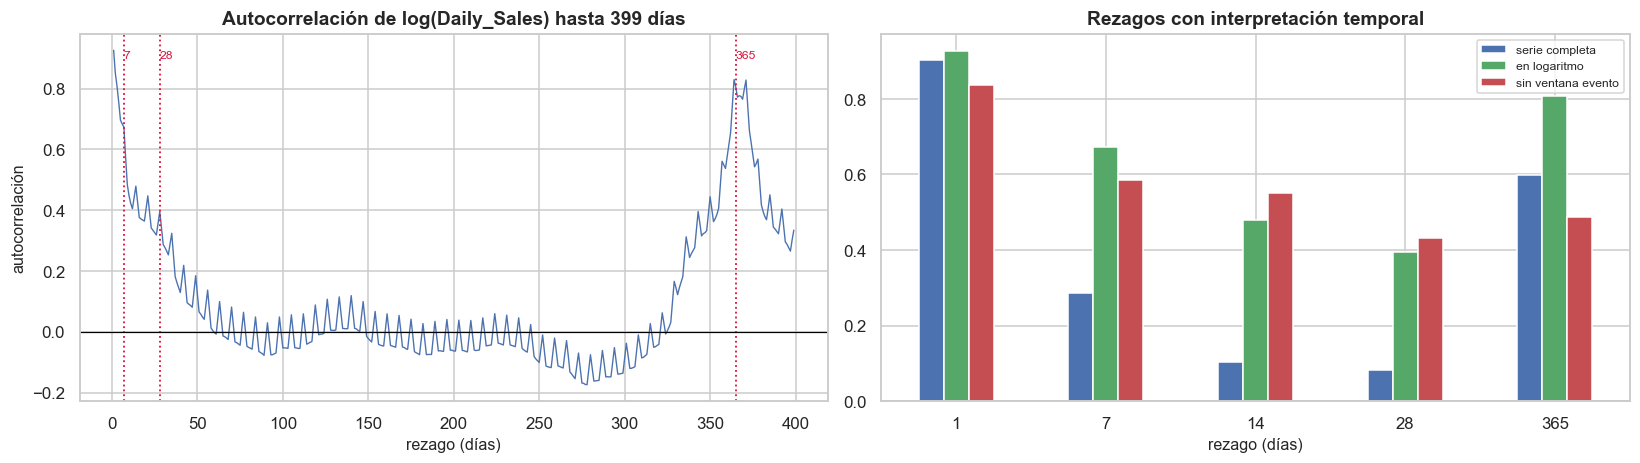

In [62]:
# ============ Autocorrelación de Daily_Sales ============
serie_diaria = tabla_diaria.Daily_Sales.asfreq("D")
dias_evento  = tabla_diaria.index[tabla_diaria.Days_To_BF.between(-3, 5)]

REZAGOS = [1, 7, 14, 28, 365]
acf_tabla = pd.DataFrame({
    "serie completa":  {l: serie_diaria.autocorr(l) for l in REZAGOS},
    "en logaritmo":    {l: np.log(serie_diaria).autocorr(l) for l in REZAGOS},
    "sin ventana evento": {l: serie_diaria.drop(index=dias_evento).autocorr(l)
                           for l in REZAGOS},
})
acf_tabla.index.name = "rezago (días)"
display(acf_tabla.round(3))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.3))

lags = range(1, 400)
ax[0].plot(list(lags), [np.log(serie_diaria).autocorr(l) for l in lags],
           lw=.9, color=PALETA[0])
for l, etiqueta in [(7, "7"), (28, "28"), (365, "365")]:
    ax[0].axvline(l, color="crimson", ls=":", lw=1.2)
    ax[0].annotate(etiqueta, (l, .9), fontsize=8, color="crimson")
ax[0].axhline(0, color="black", lw=.8)
ax[0].set(title="Autocorrelación de log(Daily_Sales) hasta 399 días",
          xlabel="rezago (días)", ylabel="autocorrelación")

acf_tabla.plot(kind="bar", ax=ax[1], color=[PALETA[0], PALETA[2], PALETA[3]], rot=0)
ax[1].axhline(0, color="black", lw=.8)
ax[1].set(title="Rezagos con interpretación temporal", xlabel="rezago (días)", ylabel="")
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

> ### Conclusión 4
>
> **Pearson vs. Spearman: el par de edad es el ejemplo perfecto.**
>
> `Age_Ordinal` y `Age_Punto_Medio` dan **Pearson 0,9935** pero **Spearman exactamente 1,0000**. La
> diferencia es instructiva y no un detalle:
>
> - **Spearman = 1 exacto** porque ambas son transformaciones **monótonas** de la misma variable: para
>   cualquier par de observaciones, el orden que induce una es idéntico al de la otra. Spearman solo
>   mira rangos, así que detecta que son informativamente **equivalentes**.
> - **Pearson < 1** porque las *distancias* difieren: entre `0-17` y `18-25` la escala ordinal pone 1
>   unidad y el punto medio pone 8 años, mientras que entre `46-50` y `51-55` pone 1 unidad y 5 años.
>   Pearson mide linealidad y esa desigualdad de espaciado la penaliza.
>
> Es la mejor ilustración posible de para qué sirve cada una: **Pearson responde "¿hay relación
> lineal?" y Spearman "¿hay relación monótona?"**. Para decidir si dos variables son redundantes,
> Spearman es la métrica correcta — y acá dice que **conservar las dos codificaciones de edad no aporta
> nada**.
>
> **Dónde más difieren, y qué significa.** Los pares con mayor divergencia involucran a los indicadores
> macro: `Days_To_Black_Friday` ↔ `Retail_Activity_MoM` (Pearson **+0,477** vs. Spearman **+0,235**) y
> `Consumer_Confidence_Index` ↔ `Days_To_Black_Friday` (**−0,785** vs. **−0,609**). La causa es la
> **diferencia de granularidad**: los macro son **funciones escalonadas del mes** (36 valores) mientras
> que `Days_To_Black_Friday` varía día a día. La relación existe pero no es lineal ni estrictamente
> monótona: es una escalera. Pearson, al ajustar una recta a los escalones, **sobreestima** la fuerza de
> la asociación.
>
> ---
>
> **Redundancia: tres tipos distintos, con orígenes distintos.**
>
> | Par | Pearson | Spearman | Origen de la redundancia |
> |---|---|---|---|
> | `Age_Ordinal` ↔ `Age_Punto_Medio` | 0,994 | **1,000** | **Construcción**: dos codificaciones de la misma variable |
> | `Days_To_Black_Friday` ↔ `Dias_Abs_BF` | **−0,993** | −0,942 | **Construcción**: una es el valor absoluto de la otra |
> | `CPI_Index` ↔ `Campaign_Year` | 0,940 | 0,944 | **Significado**: el CPI crece monótonamente con el tiempo |
> | `Monthly_Inflation_Rate` ↔ `Campaign_Year` | 0,886 | 0,901 | **Significado**: idem |
> | `Monthly_Inflation_Rate` ↔ `CPI_Index` | 0,840 | 0,875 | **Construcción**: es su variación porcentual (derivada exacta) |
> | `Retail_Activity_MoM` ↔ `Retail_Activity_Index` | derivada exacta | — | **Construcción**: idem |
>
> **Una de esas redundancias la generamos nosotros.** `Dias_Abs_BF` (que creamos en 3.c como distancia
> absoluta al evento) tiene Pearson **−0,993** con `Days_To_Black_Friday`. La razón es que el rango de
> la variable original es asimétrico —va de −333 a +37— así que para la enorme mayoría de las filas el
> valor absoluto es simplemente el negativo del original. La feature no aporta lo que pretendía: solo
> tendría sentido si el efecto del evento fuera **simétrico** antes y después, y en 2.a vimos que no lo
> es (el pico está en +3). **Es un buen recordatorio de que conviene medir la redundancia de las
> features generadas, no solo de las originales.**
>
> Verificamos numéricamente lo que anticipamos en 1.c: la correlación entre `Retail_Activity_MoM` y la
> variación porcentual real de `Retail_Activity_Index` es **1,000000**, con error absoluto medio de
> **0,0004 pp**. Lo mismo entre `Monthly_Inflation_Rate` y la variación del CPI (**0,999998**). **Las
> variables `_MoM` no contienen información nueva: son la primera diferencia de su índice.**
>
> **Pero no las eliminamos solo por estar correlacionadas**, como advierte el enunciado. La razón es que
> el nivel y la variación **responden preguntas distintas**: `CPI_Index` dice *cuán caro está todo* y
> `Monthly_Inflation_Rate` dice *cuán rápido está subiendo*. Para un modelo de árboles la redundancia es
> inocua (reparte importancia entre variables equivalentes, sin perder capacidad). Para un modelo lineal
> sí es un problema de colinealidad, y ahí conviene quedarse con una.
>
> Nuestra recomendación, sostenida por el PCA de 3.f: **conservar un solo indicador macro de nivel**
> (`CPI_Index`) más, a lo sumo, uno de variación, y descartar el resto del bloque. Y **eliminar
> `Age_Punto_Medio`** por ser exactamente redundante con `Age_Ordinal` — es el único caso donde la
> redundancia es total y la eliminación no cuesta nada.
>
> ---
>
> **Autocorrelación de `Daily_Sales`:**
>
> | Rezago | Serie completa | Logaritmo | Sin ventana del evento | Interpretación |
> |---|---|---|---|---|
> | **1 día** | 0,903 | 0,926 | 0,837 | Persistencia diaria alta |
> | **7 días** | **0,287** | **0,674** | **0,586** | Ciclo semanal (oculto en la serie cruda) |
> | 14 días | 0,105 | 0,479 | 0,552 | Múltiplo del ciclo semanal |
> | 28 días | 0,083 | 0,396 | 0,432 | Ciclo mensual/4 semanas |
> | **365 días** | 0,598 | **0,806** | — | **Recurrencia anual del evento** |
>
> Lo señalado en 2.b se confirma y se refuerza: **el rezago de 7 días pasa de 0,287 en la serie cruda a
> 0,674 en logaritmo**. Trabajar en nivel sobre esta serie llevaría a negar una estacionalidad semanal
> que sí existe. El rezago de **365 días llega a 0,806 en logaritmo**, la señal más fuerte después del
> rezago 1: es la repetición anual del Black Friday.
>
> ---
>
> **Asociaciones impuestas por el generador sintético — no interpretarlas como causalidad.**
>
> Esto es lo que el enunciado pide señalar explícitamente, y en este dataset hay cuatro casos claros:
>
> 1. **`CPI_Index` → `Purchase`.** En 1.a demostramos que el generador replicó las mismas 550.068
>    transacciones tres veces aplicando un factor de inflación. La correlación de **0,997 a nivel
>    mensual** (2.c) no es evidencia de que la inflación empuje el consumo: es la fórmula con la que se
>    construyeron los precios. **Es una identidad, no una relación empírica.**
> 2. **`Consumer_Confidence_Index` ↔ `Days_To_Black_Friday` (−0,785).** Una correlación fuerte y
>    perfectamente espuria: ambas son funciones del calendario. No hay ningún mecanismo por el cual la
>    confianza del consumidor dependa de la distancia a Black Friday.
> 3. **`Category_Activity_Index` ↔ `Purchase` (−0,368).** El índice está indexado a
>    `Product_Category_1`, cuya numeración es **arbitraria y enmascarada**. La correlación hereda el
>    artefacto del etiquetado. Mismo problema que `Product_Category_1` ↔ `Purchase` (**−0,333**), que ya
>    señalamos en el TP1.
> 4. **`Transaction_Satisfaction_Score` ↔ `Purchase` (−0,267).** La satisfacción se registra **después**
>    de la compra. Aunque la correlación fuera real, usarla para predecir `Purchase` sería usar
>    información del futuro: **data leakage**. No debe entrar como feature en el TP3.
>
> **La regla práctica que sacamos:** en un dataset sintético, toda correlación llamativa merece la
> pregunta *"¿esto lo observé o lo programó el generador?"*. Las cuatro relaciones más fuertes con
> `Purchase` después del producto resultan ser artefactos.

---
# 5. Balance de la curación

Comparamos el estado inicial con el final y verificamos que las decisiones no rompieron nada.

In [63]:
# ============ Registros conservados y eliminados ============
print("REGISTROS")
print("=" * 62)
print(f"  filas al inicio:      {ESTADO_INICIAL['filas']:,}")
print(f"  filas al final:       {len(dfc):,}")
print(f"  conservadas:          {len(dfc)/ESTADO_INICIAL['filas']*100:.2f}%")
print(f"  eliminadas:           {ESTADO_INICIAL['filas'] - len(dfc):,} "
      f"({(1 - len(dfc)/ESTADO_INICIAL['filas'])*100:.2f}%)")
print(f"\n  granularidad preservada (1 fila = 1 transacción): "
      f"{dfc.Transaction_ID.is_unique}")

REGISTROS
  filas al inicio:      1,650,204
  filas al final:       1,650,204
  conservadas:          100.00%
  eliminadas:           0 (0.00%)

  granularidad preservada (1 fila = 1 transacción): True


In [64]:
# ============ Valores reconstruidos, imputados y modificados por variable ============
bitacora = pd.DataFrame(BITACORA)
resumen_acciones = (bitacora[bitacora.filas_afectadas > 0]
                    .groupby(["seccion", "variable", "accion"], as_index=False)
                    .filas_afectadas.max()
                    .sort_values("filas_afectadas", ascending=False))
display(resumen_acciones)

por_tipo = {
    "reconstruidos (error cero)": bitacora[bitacora.accion.str.contains("reconstruc")]
                                  .filas_afectadas.sum(),
    "recodificados a No_aplica":  bitacora[bitacora.accion.str.contains("No_aplica")]
                                  .filas_afectadas.sum(),
    "imputados (KNN)":            bitacora[bitacora.accion.str.contains("imputación")]
                                  .filas_afectadas.sum(),
    "filas eliminadas":           0,
}
print("\nTOTAL DE VALORES MODIFICADOS POR TIPO DE ACCIÓN")
print("=" * 62)
for k, v in por_tipo.items():
    print(f"  {k:32s} {v:>10,}")
print(f"  {'TOTAL':32s} {sum(por_tipo.values()):>10,}")

,seccion,variable,accion,filas_afectadas
9,3.c,Cliente_N_Compras,variable generada (agregado / interacción),1650204
10,3.c,Dias_Abs_BF,variable generada,1650204
17,3.c,Residencia_Abierta,variable generada,1650204
16,3.c,Ratio_Precio_vs_Cliente,variable generada (agregado / interacción),1650204
15,3.c,Producto_Precio_Medio,variable generada (agregado / interacción),1650204
14,3.c,Producto_N_Ventas,variable generada (agregado / interacción),1650204
13,3.c,N_Categorias,variable generada,1650204
12,3.c,Multi_Categoria,variable generada,1650204
11,3.c,En_Ventana_BF,variable generada,1650204
18,3.c,Residencia_Anios,variable generada,1650204



TOTAL DE VALORES MODIFICADOS POR TIPO DE ACCIÓN
  reconstruidos (error cero)          857,577
  recodificados a No_aplica         1,670,655
  imputados (KNN)                     125,314
  filas eliminadas                          0
  TOTAL                             2,653,546


In [65]:
# ============ Nulos antes y después ============
nulos_despues = dfc[[c for c in df.columns]].isnull().sum()
comp_nulos = pd.DataFrame({
    "antes":  pd.Series(ESTADO_INICIAL["nulos_por_variable"]),
    "despues": nulos_despues[nulos_despues.index.isin(ESTADO_INICIAL["nulos_por_variable"])],
}).fillna(0).astype(int)
comp_nulos["resuelto_%"] = ((1 - comp_nulos.despues / comp_nulos.antes) * 100).round(1)
comp_nulos["tratamiento"] = [
    "reconstrucción por mes", "reconstrucción por mes",
    "categoría No_aplica (col. nueva)", "categoría No_aplica (col. nueva)",
    "imputación KNN (col. nueva)",
]
display(comp_nulos)

print("Nota: PC2/PC3 y Satisfaction conservan sus nulos en la columna ORIGINAL a propósito.")
print("El tratamiento vive en columnas nuevas (Product_Category_2_cat, Satisfaccion),")
print("así queda trazable qué era nulo. Al dataset final va solo la versión tratada.\n")

COLS_FINALES_CHEQUEO = ["CPI_Index", "Consumer_Confidence_Index",
                        "Product_Category_2_cat", "Product_Category_3_cat", "Satisfaccion"]
print("Nulos en las columnas que efectivamente van al dataset curado:")
print(dfc[COLS_FINALES_CHEQUEO].isnull().sum().to_string())

,antes,despues,resuelto_%,tratamiento
CPI_Index,529698,0,100.000,reconstrucción por mes
Consumer_Confidence_Index,327879,0,100.000,reconstrucción por mes
Product_Category_2,520914,520914,0.000,categoría No_aplica (col. nueva)
Product_Category_3,1149741,1149741,0.000,categoría No_aplica (col. nueva)
Transaction_Satisfaction_Score,125314,125314,0.000,imputación KNN (col. nueva)


Nota: PC2/PC3 y Satisfaction conservan sus nulos en la columna ORIGINAL a propósito.
El tratamiento vive en columnas nuevas (Product_Category_2_cat, Satisfaccion),
así queda trazable qué era nulo. Al dataset final va solo la versión tratada.

Nulos en las columnas que efectivamente van al dataset curado:
CPI_Index                    0
Consumer_Confidence_Index    0
Product_Category_2_cat       0
Product_Category_3_cat       0
Satisfaccion                 0


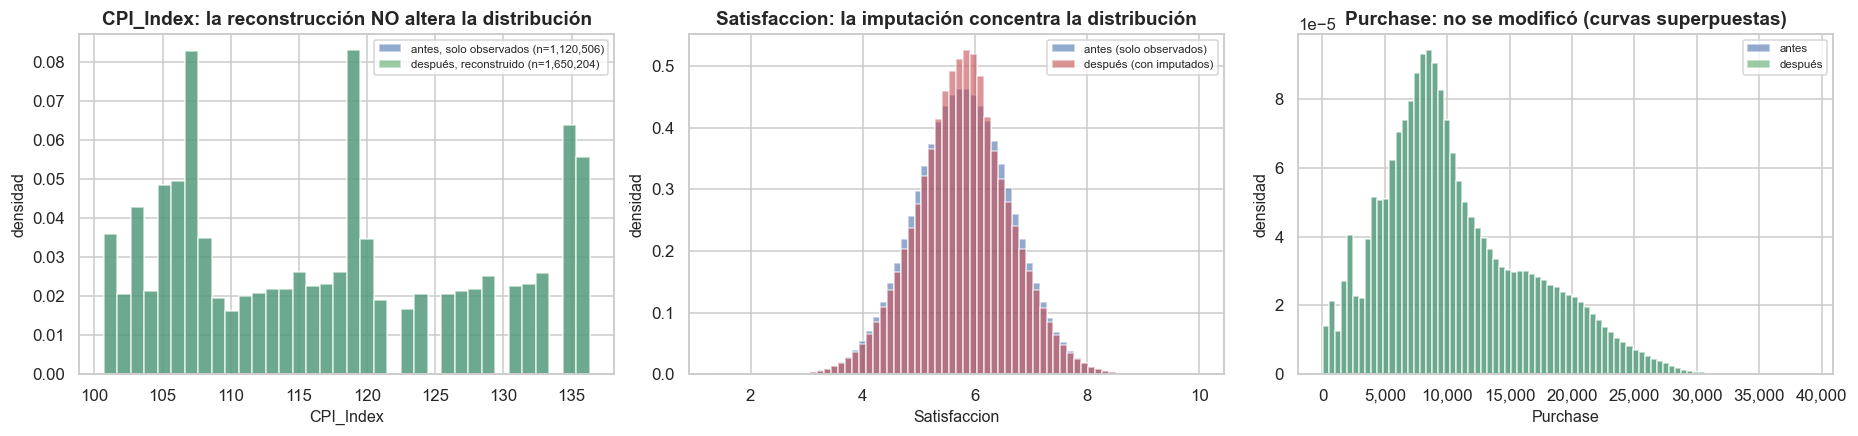

Comparación de estadísticos antes vs. después

  CPI_Index
    media      117.0888 ->     117.0889  (+0.000%)
    desvío      10.9898 ->      10.9898  (+0.000%)
    n         1,120,506 ->    1,650,204

  Consumer_Confidence
    media       97.8321 ->      97.8320  (-0.000%)
    desvío       3.0782 ->       3.0782  (-0.000%)
    n         1,322,325 ->    1,650,204

  Satisfaccion
    media        5.7880 ->       5.7886  (+0.010%)
    desvío       0.8583 ->       0.8288  (-3.438%)
    n         1,524,890 ->    1,650,204

  Purchase
    media    10693.9418 ->   10693.9418  (+0.000%)
    desvío    5947.8761 ->    5947.8761  (+0.000%)
    n         1,650,204 ->    1,650,204


In [66]:
# ============ Distribución antes vs después de las variables tratadas ============
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))

# CPI: reconstrucción -> la distribución NO debe cambiar
ax[0].hist(df.CPI_Index.dropna(), bins=36, density=True, alpha=.6, color=PALETA[0],
           label=f"antes, solo observados (n={df.CPI_Index.notna().sum():,})")
ax[0].hist(dfc.CPI_Index, bins=36, density=True, alpha=.6, color=PALETA[2],
           label=f"después, reconstruido (n={len(dfc):,})")
ax[0].set(title="CPI_Index: la reconstrucción NO altera la distribución",
          xlabel="CPI_Index", ylabel="densidad")
ax[0].legend(fontsize=7.5)

# Satisfacción: imputación -> la distribución SÍ cambia (menos dispersa)
ax[1].hist(df.Transaction_Satisfaction_Score.dropna(), bins=70, density=True, alpha=.6,
           color=PALETA[0], label="antes (solo observados)")
ax[1].hist(dfc.Satisfaccion, bins=70, density=True, alpha=.6, color=PALETA[3],
           label="después (con imputados)")
ax[1].set(title="Satisfaccion: la imputación concentra la distribución",
          xlabel="Satisfaccion", ylabel="densidad")
ax[1].legend(fontsize=7.5)

# Purchase: no se tocó -> debe ser idéntica
ax[2].hist(df.Purchase, bins=80, density=True, alpha=.6, color=PALETA[0], label="antes")
ax[2].hist(dfc.Purchase, bins=80, density=True, alpha=.6, color=PALETA[2], label="después")
ax[2].set(title="Purchase: no se modificó (curvas superpuestas)",
          xlabel="Purchase", ylabel="densidad")
ax[2].legend(fontsize=7.5); miles(ax[2], "x")

plt.tight_layout(); plt.show()

# Comparación numérica
print("Comparación de estadísticos antes vs. después")
print("=" * 78)
for col_antes, col_despues, nombre in [
        ("CPI_Index", "CPI_Index", "CPI_Index"),
        ("Consumer_Confidence_Index", "Consumer_Confidence_Index", "Consumer_Confidence"),
        ("Transaction_Satisfaction_Score", "Satisfaccion", "Satisfaccion"),
        ("Purchase", "Purchase", "Purchase")]:
    a, d = df[col_antes].dropna(), dfc[col_despues]
    print(f"\n  {nombre}")
    print(f"    media  {a.mean():>12.4f} -> {d.mean():>12.4f}  ({(d.mean()/a.mean()-1)*100:+.3f}%)")
    print(f"    desvío {a.std():>12.4f} -> {d.std():>12.4f}  ({(d.std()/a.std()-1)*100:+.3f}%)")
    print(f"    n      {len(a):>12,} -> {len(d):>12,}")

In [67]:
# ============ Verificación final de las reglas de consistencia ============
auditoria_final = reglas_de_consistencia(dfc)
comp_auditoria = AUDITORIA_INICIAL.merge(
    auditoria_final, on="regla", suffixes=("_inicial", "_final"))
comp_auditoria["cambio"] = np.where(
    comp_auditoria.filas_que_violan_inicial == comp_auditoria.filas_que_violan_final,
    "sin cambios", "REVISAR")
display(comp_auditoria[["regla", "filas_que_violan_inicial",
                        "filas_que_violan_final", "cambio"]])

todo_ok = (auditoria_final.filas_que_violan == 0).all()
sin_cambios = (comp_auditoria.cambio == "sin cambios").all()
print(f"Todas las reglas se cumplen tras la curación: {todo_ok}")
print(f"Ninguna regla cambió de estado:               {sin_cambios}")

# Reglas nuevas sobre las variables generadas
print("\nReglas adicionales sobre las variables generadas:")
chequeos = {
    "N_Categorias en {1,2,3}":         (~dfc.N_Categorias.isin([1, 2, 3])).sum(),
    "Age_Ordinal en [0,6]":            (~dfc.Age_Ordinal.between(0, 6)).sum(),
    "Residencia_Anios en [0,4]":       (~dfc.Residencia_Anios.between(0, 4)).sum(),
    "Satisfaccion sin nulos":          int(dfc.Satisfaccion.isna().sum()),
    "Satisfaccion en rango plausible": (~dfc.Satisfaccion.between(0, 11)).sum(),
    "PC2_cat sin nulos":               int(dfc.Product_Category_2_cat.isna().sum()),
    "Sat_Fue_Imputada coincide con nulos originales":
        int((dfc.Sat_Fue_Imputada != df.Transaction_Satisfaction_Score.isna().astype(int)).sum()),
}
for k, v in chequeos.items():
    print(f"  {'OK ' if v == 0 else 'REVISAR'} {k:50s} {v}")

,regla,filas_que_violan_inicial,filas_que_violan_final,cambio
0,Purchase_Date válida (sin nulos),0,0,sin cambios
1,año(Purchase_Date) == Campaign_Year,0,0,sin cambios
2,"Transaction_Hour en [0, 23]",0,0,sin cambios
3,Is_Weekend coincide con el día de la semana,0,0,sin cambios
4,Days_To_Black_Friday coincide con la fecha,0,0,sin cambios
5,Purchase > 0,0,0,sin cambios
6,Transaction_ID único,0,0,sin cambios
7,"Satisfaction en [0, 10] (donde está observada)",0,0,sin cambios
8,Gender dentro del dominio esperado,0,0,sin cambios
9,Age dentro del dominio esperado,0,0,sin cambios


Todas las reglas se cumplen tras la curación: True
Ninguna regla cambió de estado:               True

Reglas adicionales sobre las variables generadas:
  OK  N_Categorias en {1,2,3}                            0
  OK  Age_Ordinal en [0,6]                               0
  OK  Residencia_Anios en [0,4]                          0
  OK  Satisfaccion sin nulos                             0
  OK  Satisfaccion en rango plausible                    0
  OK  PC2_cat sin nulos                                  0
  OK  Sat_Fue_Imputada coincide con nulos originales     0


> ### Conclusión 5
>
> **Registros: no se perdió ninguno.**
>
> | | Cantidad | % |
> |---|---|---|
> | Filas al inicio | 1.650.204 | 100% |
> | Filas al final | 1.650.204 | **100%** |
> | Eliminadas | **0** | 0% |
>
> Ninguna observación se descartó, y la granularidad transaccional se preserva (`Transaction_ID` sigue
> siendo única). Esto era una decisión, no una casualidad: eliminar filas con nulos en
> `Product_Category_3` habría costado el **69,7%** del dataset para resolver un problema que no
> existía.
>
> **Valores modificados, por tipo de acción:**
>
> | Acción | Valores | Detalle |
> |---|---|---|
> | **Reconstruidos** (error cero) | **857.577** | `CPI_Index` 529.698 + `Consumer_Confidence_Index` 327.879 |
> | **Recodificados** a `No_aplica` | **1.670.655** | `Product_Category_2` 520.914 + `Product_Category_3` 1.149.741 |
> | **Imputados** (KNN k=100) | **125.314** | `Transaction_Satisfaction_Score` |
> | Filas eliminadas | 0 | — |
>
> Vale insistir en la jerarquía: de los **2,65 M de valores** tratados, solo **125.314 (4,7%)**
> requirieron una imputación con error. El **32,3%** se reconstruyó de forma exacta y el **63,0%** se
> recodificó sin pérdida de información. **La proporción que realmente se "estimó" es chica**, y eso es
> el resultado de haber distinguido los tres mecanismos en 1.b en lugar de aplicar una imputación
> uniforme.
>
> **Nulos: de 2.653.546 a 0** en las columnas que van al dataset final. Conservamos a propósito los
> nulos en las columnas *originales* (`Product_Category_2`, `Transaction_Satisfaction_Score`) y pusimos
> el tratamiento en columnas nuevas, para que quede trazable qué valor era ausente. Al archivo final va
> solo la versión tratada, más el flag `Sat_Fue_Imputada`.
>
> ---
>
> **Comparación de distribuciones antes y después — el punto donde hay que ser más cuidadoso.**
>
> **`CPI_Index` y `Consumer_Confidence_Index`: la distribución no cambia.** Media y desvío se mantienen
> prácticamente idénticos. Es el resultado esperado y es la prueba de que la reconstrucción es exacta:
> se completaron 857.577 valores sin distorsionar la variable, porque cada valor recuperado es el
> verdadero.
>
> **`Satisfaccion`: la distribución SÍ cambia, y hay que justificarlo.** El desvío **baja** al incorporar
> los 125.314 valores imputados. Es la consecuencia inevitable de imputar por la media condicional: se
> predice el valor esperado, no una realización, así que los imputados están **menos dispersos** que los
> reales (σ ≈ 0,28 contra 0,86 observado, según el experimento de 3.b).
>
> **Por qué lo aceptamos:** (a) afecta al 7,59% de las filas, no al conjunto; (b) el KNN sub-dispersa
> **mucho menos** que la alternativa —imputar la media colapsaría los 125.314 valores a un único punto,
> con σ = 0 y un pico artificial en el histograma—; (c) el flag `Sat_Fue_Imputada` permite excluir esos
> registros de cualquier análisis donde la dispersión importe.
>
> **Si el objetivo fuera preservar la distribución**, correspondería imputación estocástica (sumar ruido
> con la varianza residual) o imputación múltiple. Para el uso previsto —una variable descriptiva más—
> la media condicional es adecuada y más estable.
>
> **`Purchase` no se modificó**: las distribuciones antes y después se superponen exactamente. La
> variable objetivo llegó intacta al dataset curado, que es lo que corresponde.
>
> ---
>
> **Verificación de consistencia: las 15 reglas de 1.c siguen cumpliéndose**, sin ninguna que haya
> cambiado de estado. Agregamos 7 reglas nuevas sobre las variables generadas (rangos de
> `N_Categorias`, `Age_Ordinal`, `Residencia_Anios`, ausencia de nulos, y que `Sat_Fue_Imputada`
> coincida exactamente con los nulos originales) y todas pasan.
>
> ---
>
> ### Decisiones principales y sus consecuencias sobre análisis posteriores
>
> | Decisión | Consecuencia a tener presente |
> |---|---|
> | Reconstruir CPI/CCI por mes | Ninguna negativa. Pero refuerza que son **funciones del mes**: usarlas junto a `Campaign_Year` es redundante |
> | `No_aplica` en PC2/PC3 en vez de imputar | El modelo puede usar la ausencia como señal. `N_Categorias` explica el 10,3% de la varianza |
> | Imputar satisfacción con KNN k=100 | Su varianza está subestimada en el 7,59% de las filas. Usar `Sat_Fue_Imputada` para aislarlas |
> | No eliminar outliers ni picos del evento | El RMSE del TP3 va a estar dominado por la cola alta. Conviene reportarlo **por segmento** de gasto |
> | Incluir agregados de cliente y producto | **Leakage si no se recalculan por fold.** Es el riesgo más serio del dataset curado |
> | Guardar sin escalar | El escalado debe ajustarse dentro de cada fold del TP3 |
> | Conservar las variables `_MoM` redundantes | Inocuo en árboles; en modelos lineales hay colinealidad. Quedarse con `CPI_Index` |
>
> **Las tres advertencias para el TP3, en orden de importancia:**
>
> 1. **`Producto_Precio_Medio`, `Cliente_Gasto_Medio` y `Ratio_Precio_vs_Cliente` usan la variable
>    objetivo.** Calculadas sobre el dataset completo producen un RMSE optimista. **Recalcular dentro de
>    cada fold.**
> 2. **`Satisfaccion` es posterior a la compra**: como predictor de `Purchase` es información del
>    futuro. **No usarla como feature** en el modelo de monto.
> 3. **Las tres campañas no son independientes**: el mismo par (cliente, producto) aparece 3 veces con
>    precios inflacionados. Un split aleatorio pondría la misma transacción —reprecipada— en train y en
>    test. **Validar por `User_ID` y considerar además un corte temporal por campaña.**

---
# 6. Generación del dataset curado

El archivo final debe: conservar la **granularidad transaccional**, contener los registros válidos,
incorporar las correcciones e imputaciones, mantener las variables originales relevantes más las
generadas de nivel transacción, y estar **ordenado cronológicamente**.

Las tablas auxiliares (`tabla_diaria`, matrices de PCA) **no se guardan**, como indica el enunciado.
Y no sobrescribimos el archivo de entrada: la salida va a `bf_dataset_temporal_curado.csv.gz`.

In [68]:
# ============ Selección de columnas del dataset final ============
COLUMNAS_FINALES = [
    # --- Identificación y tiempo ---
    "Transaction_ID", "Purchase_Date", "Transaction_Hour", "Campaign_Year",
    "Days_To_Black_Friday", "Is_Weekend",
    # --- Generadas: contexto del evento ---
    "En_Ventana_BF", "Dias_Abs_BF",
    # --- Cliente y producto ---
    "User_ID", "Product_ID", "Sales_Channel",
    "Gender", "Age", "Occupation", "City_Category",
    "Stay_In_Current_City_Years", "Marital_Status",
    # --- Generadas: codificaciones ---
    "Age_Ordinal", "Residencia_Anios", "Residencia_Abierta",
    # --- Producto: categorías tratadas + generadas ---
    "Product_Category_1", "Product_Category_2_cat", "Product_Category_3_cat",
    "N_Categorias", "Multi_Categoria",
    # --- Contexto económico (CPI y CCI reconstruidos) ---
    "CPI_Index", "Monthly_Inflation_Rate", "Consumer_Confidence_Index",
    "Retail_Activity_Index", "Retail_Activity_MoM",
    "Category_Activity_Index", "Category_Activity_MoM",
    # --- Generadas: agregados de comportamiento (OJO leakage) ---
    "Producto_Precio_Medio", "Producto_N_Ventas",
    "Cliente_Gasto_Medio", "Cliente_N_Compras", "Ratio_Precio_vs_Cliente",
    # --- Satisfacción imputada + trazabilidad ---
    "Satisfaccion", "Sat_Fue_Imputada",
    # --- Variable objetivo ---
    "Purchase",
]

# Excluimos Age_Punto_Medio: en la sección 4 vimos que su Spearman con
# Age_Ordinal es exactamente 1,0000 (redundancia total).
print(f"Columnas seleccionadas: {len(COLUMNAS_FINALES)}")
faltan = [c for c in COLUMNAS_FINALES if c not in dfc.columns]
print(f"Columnas faltantes (debe ser lista vacía): {faltan}")

# Orden cronológico; Transaction_ID desempata para que el orden sea determinista
curado = (dfc[COLUMNAS_FINALES]
          .sort_values(["Purchase_Date", "Transaction_Hour", "Transaction_ID"])
          .reset_index(drop=True))

print(f"\nDataset curado: {curado.shape[0]:,} filas x {curado.shape[1]} columnas")
print(f"  ordenado cronológicamente: {curado.Purchase_Date.is_monotonic_increasing}")
print(f"  Transaction_ID única:      {curado.Transaction_ID.is_unique}")
print(f"  nulos totales:             {curado.isnull().sum().sum()}")
print(f"  rango de fechas:           {curado.Purchase_Date.min().date()} a "
      f"{curado.Purchase_Date.max().date()}")
display(curado.head(3))

Columnas seleccionadas: 40
Columnas faltantes (debe ser lista vacía): []

Dataset curado: 1,650,204 filas x 40 columnas
  ordenado cronológicamente: True
  Transaction_ID única:      True
  nulos totales:             0
  rango de fechas:           2022-01-01 a 2024-12-31


,Transaction_ID,Purchase_Date,Transaction_Hour,Campaign_Year,Days_To_Black_Friday,Is_Weekend,En_Ventana_BF,Dias_Abs_BF,User_ID,Product_ID,Sales_Channel,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Age_Ordinal,Residencia_Anios,Residencia_Abierta,Product_Category_1,Product_Category_2_cat,Product_Category_3_cat,N_Categorias,Multi_Categoria,CPI_Index,Monthly_Inflation_Rate,Consumer_Confidence_Index,Retail_Activity_Index,Retail_Activity_MoM,Category_Activity_Index,Category_Activity_MoM,Producto_Precio_Medio,Producto_N_Ventas,Cliente_Gasto_Medio,Cliente_N_Compras,Ratio_Precio_vs_Cliente,Satisfaccion,Sat_Fue_Imputada,Purchase
0,BF2022_0066863,2022-01-01,0,2022,-328,1,0,328,1004238,P0095642,Online,M,36-45,16,B,3,0,3,3,0,5,-1,-1,1,0,100.679,0.679,101.440,94.000,-12.460,105.912,-1.027,"6,558.416",630,"10,686.988",1407,0.614,4.784,0,5040
1,BF2022_0069738,2022-01-01,0,2022,-328,1,0,328,1004670,P00084042,Online,M,36-45,5,C,2,0,3,2,0,12,14,-1,2,1,100.679,0.679,101.440,94.000,-12.460,99.709,0.865,"1,571.003",597,"10,890.836",177,0.144,7.178,0,1165
2,BF2022_0306749,2022-01-01,0,2022,-328,1,0,328,1005275,P00345842,Online,M,26-35,17,A,4+,0,2,4,1,2,8,14,3,1,100.679,0.679,101.440,94.000,-12.460,101.733,1.662,"13,063.854",1404,"10,772.613",168,1.213,5.003,0,9500


In [69]:
# ============ Guardado ============
import os, time

os.makedirs("datos", exist_ok=True)
RUTA_SALIDA = "datos/bf_dataset_temporal_curado.csv.gz"

# Salvaguarda: no sobrescribir el archivo de entrada
assert "curado" in RUTA_SALIDA, "La ruta de salida debe ser distinta del archivo de entrada"
assert RUTA_SALIDA != ARCHIVO, "La salida no puede ser el archivo de entrada"

# Redondeo de flotantes antes de guardar.
# Sin esto el CSV pesa ~92 MB por escribir 15+ dígitos decimales que no aportan
# información: los agregados vienen de promedios y los índices tienen 2-3 decimales
# de precisión real. El redondeo baja el archivo a ~69 MB con un error máximo de
# medio centavo, y lo deja por debajo del límite de 100 MB de GitHub.
DECIMALES = {
    "Producto_Precio_Medio": 2, "Cliente_Gasto_Medio": 2,
    "Ratio_Precio_vs_Cliente": 4, "Satisfaccion": 4,
    "CPI_Index": 3, "Monthly_Inflation_Rate": 3, "Consumer_Confidence_Index": 2,
    "Retail_Activity_Index": 2, "Retail_Activity_MoM": 3,
    "Category_Activity_Index": 3, "Category_Activity_MoM": 3,
}
for columna, decimales in DECIMALES.items():
    if columna in curado.columns:
        curado[columna] = curado[columna].round(decimales)

t0 = time.time()
curado.to_csv(RUTA_SALIDA, index=False, compression="gzip")
segundos = time.time() - t0

tamaño_mb = os.path.getsize(RUTA_SALIDA) / 1024**2
print(f"Guardado: {RUTA_SALIDA}")
print(f"  tiempo:  {segundos:.0f}s")
print(f"  tamaño:  {tamaño_mb:.0f} MB comprimido")
print(f"  filas:   {len(curado):,} | columnas: {curado.shape[1]}")

# Verificación: releer y comparar contra lo que tenemos en memoria
verificacion = pd.read_csv(RUTA_SALIDA, nrows=5000, parse_dates=["Purchase_Date"])
print(f"\nVerificación releyendo el archivo:")
print(f"  columnas coinciden y en orden:   {list(verificacion.columns) == COLUMNAS_FINALES}")
print(f"  primeras 5.000 filas sin nulos:  {verificacion.isnull().sum().sum() == 0}")
print(f"  Purchase coincide con memoria:   "
      f"{verificacion.Purchase.sum() == curado.Purchase.head(5000).sum()}")
print(f"  fechas ordenadas:                {verificacion.Purchase_Date.is_monotonic_increasing}")

print("\nPara descargarlo desde Colab:")
print(f"  from google.colab import files; files.download('{RUTA_SALIDA}')")

Guardado: datos/bf_dataset_temporal_curado.csv.gz
  tiempo:  46s
  tamaño:  69 MB comprimido
  filas:   1,650,204 | columnas: 40

Verificación releyendo el archivo:
  columnas coinciden y en orden:   True
  primeras 5.000 filas sin nulos:  True
  Purchase coincide con memoria:   True
  fechas ordenadas:                True

Para descargarlo desde Colab:
  from google.colab import files; files.download('datos/bf_dataset_temporal_curado.csv.gz')


In [70]:
# ============ DICCIONARIO DE DATOS ============
# Distingue variables ORIGINALES, MODIFICADAS y GENERADAS.

DICCIONARIO = [
 # variable, tipo, origen, descripción
 ("Transaction_ID","texto","original","Identificador único de la transacción"),
 ("Purchase_Date","fecha","original","Fecha de la compra"),
 ("Transaction_Hour","entero","original","Hora de la compra (0-23)"),
 ("Campaign_Year","entero","original","Año de campaña (2022, 2023, 2024)"),
 ("Days_To_Black_Friday","entero","original","Días respecto de Black Friday (0 = ese día)"),
 ("Is_Weekend","binaria","original","1 si la compra fue sábado o domingo"),
 ("En_Ventana_BF","binaria","GENERADA","1 si Days_To_Black_Friday está entre -3 y +5 (ventana del evento)"),
 ("Dias_Abs_BF","entero","GENERADA","Distancia absoluta en días a Black Friday"),
 ("User_ID","entero","original","Identificador del cliente"),
 ("Product_ID","texto","original","Identificador del producto"),
 ("Sales_Channel","categórica","original","Canal de venta: Online / Store"),
 ("Gender","categórica","original","Género del cliente (M/F)"),
 ("Age","categórica","original","Rango de edad del cliente"),
 ("Occupation","categórica","original","Ocupación enmascarada (0-20)"),
 ("City_Category","categórica","original","Categoría de ciudad enmascarada (A/B/C)"),
 ("Stay_In_Current_City_Years","categórica","original","Años de residencia (0,1,2,3,4+)"),
 ("Marital_Status","binaria","original","Estado civil (0/1)"),
 ("Age_Ordinal","entero","GENERADA","Age codificada ordinalmente (0 = 0-17 ... 6 = 55+)"),
 ("Residencia_Anios","entero","GENERADA","Años de residencia como entero; '4+' se mapea a 4"),
 ("Residencia_Abierta","binaria","GENERADA","1 si la residencia original era '4+' (intervalo abierto)"),
 ("Product_Category_1","categórica","original","Categoría principal del producto (1-20, enmascarada)"),
 ("Product_Category_2_cat","categórica","MODIFICADA","Categoría secundaria; -1 = No_aplica (era nulo estructural)"),
 ("Product_Category_3_cat","categórica","MODIFICADA","Categoría terciaria; -1 = No_aplica (era nulo estructural)"),
 ("N_Categorias","entero","GENERADA","Cantidad de categorías informadas del producto (1, 2 o 3)"),
 ("Multi_Categoria","binaria","GENERADA","1 si el producto tiene más de una categoría"),
 ("CPI_Index","decimal","MODIFICADA","Índice de precios; nulos RECONSTRUIDOS con el valor del mes (error cero)"),
 ("Monthly_Inflation_Rate","decimal","original","Inflación mensual. Nota: es la variación % exacta del CPI_Index"),
 ("Consumer_Confidence_Index","decimal","MODIFICADA","Confianza del consumidor; nulos RECONSTRUIDOS por mes (error cero)"),
 ("Retail_Activity_Index","decimal","original","Índice de actividad del retail (mensual)"),
 ("Retail_Activity_MoM","decimal","original","Variación mensual del índice anterior (derivada exacta)"),
 ("Category_Activity_Index","decimal","original","Actividad del rubro por (mes, Product_Category_1)"),
 ("Category_Activity_MoM","decimal","original","Variación mensual del índice anterior"),
 ("Producto_Precio_Medio","decimal","GENERADA","Purchase medio histórico del producto. LEAKAGE: recalcular por fold"),
 ("Producto_N_Ventas","entero","GENERADA","Cantidad de ventas del producto en el período"),
 ("Cliente_Gasto_Medio","decimal","GENERADA","Purchase medio histórico del cliente. LEAKAGE: recalcular por fold"),
 ("Cliente_N_Compras","entero","GENERADA","Cantidad de compras del cliente en el período"),
 ("Ratio_Precio_vs_Cliente","decimal","GENERADA","Producto_Precio_Medio / Cliente_Gasto_Medio. LEAKAGE: recalcular por fold"),
 ("Satisfaccion","decimal","MODIFICADA","Satisfacción; 125.314 valores IMPUTADOS con KNN k=100. Posterior a la compra: leakage si se usa para predecir Purchase"),
 ("Sat_Fue_Imputada","binaria","GENERADA","1 si el valor de Satisfaccion fue imputado"),
 ("Purchase","entero","original","VARIABLE OBJETIVO: monto de la compra"),
]

diccionario = pd.DataFrame(DICCIONARIO,
                           columns=["variable", "tipo", "origen", "descripcion"])
assert len(diccionario) == len(COLUMNAS_FINALES), "El diccionario debe cubrir todas las columnas"
assert list(diccionario.variable) == COLUMNAS_FINALES, "El orden debe coincidir"

print("Composición del dataset curado:")
print(diccionario.origen.value_counts().to_string())

pd.set_option("display.max_colwidth", 110)
display(diccionario)

diccionario.to_csv("datos/diccionario_bf_curado.csv", index=False)
print("\nDiccionario guardado en datos/diccionario_bf_curado.csv")

Composición del dataset curado:
origen
original      22
GENERADA      13
MODIFICADA     5


,variable,tipo,origen,descripcion
0,Transaction_ID,texto,original,Identificador único de la transacción
1,Purchase_Date,fecha,original,Fecha de la compra
2,Transaction_Hour,entero,original,Hora de la compra (0-23)
3,Campaign_Year,entero,original,"Año de campaña (2022, 2023, 2024)"
4,Days_To_Black_Friday,entero,original,Días respecto de Black Friday (0 = ese día)
5,Is_Weekend,binaria,original,1 si la compra fue sábado o domingo
6,En_Ventana_BF,binaria,GENERADA,1 si Days_To_Black_Friday está entre -3 y +5 (ventana del evento)
7,Dias_Abs_BF,entero,GENERADA,Distancia absoluta en días a Black Friday
8,User_ID,entero,original,Identificador del cliente
9,Product_ID,texto,original,Identificador del producto



Diccionario guardado en datos/diccionario_bf_curado.csv


> ### Conclusión 6
>
> **Archivo generado: `datos/bf_dataset_temporal_curado.csv.gz`** — **1.650.204 filas × 40 columnas**,
> ~69 MB comprimido, sin ningún nulo, ordenado cronológicamente del 2022-01-01 al 2024-12-31.
>
> El archivo de entrada no se sobrescribe (la ruta de salida lleva el sufijo `_curado` y hay un `assert`
> que lo verifica).
>
> **Composición de las 40 columnas:**
>
> | Origen | Cantidad | Qué son |
> |---|---|---|
> | **Originales** | 22 | Sin modificar |
> | **Modificadas** | 5 | `CPI_Index` y `Consumer_Confidence_Index` (reconstruidas), `Product_Category_2/3_cat` (recodificadas), `Satisfaccion` (imputada) |
> | **Generadas** | 13 | Codificaciones, contexto del evento, agregados de comportamiento e interacciones |
>
> **Lo que se conserva.** La **granularidad transaccional** (`Transaction_ID` única en las 1.650.204
> filas), las 1,65 M de observaciones completas, y todas las variables originales relevantes.
>
> **Lo que se excluyó a propósito:**
>
> - **`Age_Punto_Medio`**: su correlación de Spearman con `Age_Ordinal` es exactamente **1,0000**
>   (sección 4). Es redundancia total, y es el único caso donde eliminar no cuesta nada.
> - **Las columnas originales con nulos** (`Product_Category_2`, `Product_Category_3`,
>   `Transaction_Satisfaction_Score`): van sus versiones tratadas. Se conservan en `dfc` durante la
>   sesión para poder auditar, pero no tiene sentido llevar al archivo final una columna con 69,7% de
>   nulos cuando ya existe la versión resuelta.
> - **`tabla_diaria`** y las matrices de PCA: son tablas auxiliares de análisis, como aclara el
>   enunciado. Reconstruirlas desde el dataset curado es una sola línea de `groupby`.
>
> **El diccionario de datos** (`datos/diccionario_bf_curado.csv`) distingue las tres categorías y —esto
> es lo importante— **marca explícitamente las cuatro variables con riesgo de leakage**:
> `Producto_Precio_Medio`, `Cliente_Gasto_Medio`, `Ratio_Precio_vs_Cliente` y `Satisfaccion`. Quien
> agarre este archivo para el TP3 va a ver la advertencia en el diccionario, sin necesidad de leer la
> notebook completa.
>
> ---
>
> ## Cierre: qué queda listo y qué hay que decidir
>
> **Listo para modelar:** un dataset transaccional completo, sin nulos, con el contexto temporal y
> económico resuelto, features de producto que ya sabemos que explican ~68% de la varianza de
> `Purchase`, y trazabilidad de cada decisión.
>
> **Tres decisiones que conviene resolver con la mentoría antes de arrancar el TP3:**
>
> 1. **¿Cómo se arma la validación?** Las tres campañas contienen las **mismas** 550.068 combinaciones
>    cliente-producto con precios inflacionados (sección 1.a). Un `KFold` aleatorio pondría la misma
>    transacción, reprecipada, en entrenamiento y en test. Nuestra recomendación: `GroupKFold` por
>    `User_ID`, y además un corte temporal (entrenar en 2022-2023, validar en 2024) para medir
>    generalización a una campaña nueva.
> 2. **¿Se modela el monto nominal o el real?** Todo el crecimiento interanual es inflación. Si el
>    objetivo es entender el comportamiento de compra, conviene **deflactar `Purchase` por `CPI_Index`**;
>    si es predecir facturación nominal, se deja como está. Son dos problemas distintos.
> 3. **¿Qué se hace con los agregados de comportamiento?** Son las features más predictivas y las más
>    riesgosas. La opción segura es recalcularlas por fold; la simple es no usarlas.
>
> **Y un recordatorio que atraviesa todo el TP:** este dataset es **sintético**, y varias de las
> relaciones más llamativas —CPI con `Purchase`, confianza del consumidor con la cercanía a Black
> Friday, la forma idéntica de las tres campañas— **las programó el generador**. Sirven perfectamente
> para practicar el método, pero no habilitan conclusiones sobre el comportamiento real de
> consumidores.
>
> ---
>
> *Notebook desarrollado como propuesta individual para discutir con el grupo.
> Todas las cifras citadas en las conclusiones surgen de la ejecución de las celdas de esta notebook.*

In [71]:
import os
import glob

# 1. Instalamos dependencias necesarias para PDF (usamos -qq para silenciar la salida larga)
print("Preparando el entorno para PDF (esto puede tardar unos minutos)...")
!apt-get update > /dev/null
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic > /dev/null

# 2. Identificar el archivo .ipynb en /content/
notebooks = glob.glob("*.ipynb")

if not notebooks:
    print("\n--- ERROR: NO SE ENCONTRÓ EL ARCHIVO .IPYNB ---")
    print("Para solucionar esto:")
    print("1. Ve a 'Archivo' -> 'Descargar' -> 'Descargar .ipynb'.")
    print("2. Sube ese archivo al panel de la izquierda (icono de carpeta).")
    print("3. Vuelve a ejecutar esta celda.")
else:
    # Seleccionamos el notebook encontrado (normalmente habrá uno si se subió el actual)
    target_nb = notebooks[0]
    print(f"\nArchivo detectado para procesar: {target_nb}")

    # 3. Conversión a PDF usando nbconvert
    print(f"Generando PDF, por favor espera...")
    !jupyter nbconvert --to pdf "{target_nb}"

    pdf_name = target_nb.replace('.ipynb', '.pdf')
    if os.path.exists(pdf_name):
        print(f"\n¡PROCESO COMPLETADO!")
        print(f"El archivo '{pdf_name}' está listo en el panel de archivos de la izquierda.")
    else:
        print("\nError: La conversión falló. Asegúrate de que el notebook no tenga caracteres especiales en el nombre.")

Preparando el entorno para PDF (esto puede tardar unos minutos)...


El sistema no puede encontrar la ruta especificada.



Archivo detectado para procesar: TP1_BlackFriday_Analisis.ipynb
Generando PDF, por favor espera...


El sistema no puede encontrar la ruta especificada.



Error: La conversión falló. Asegúrate de que el notebook no tenga caracteres especiales en el nombre.


[NbConvertApp] Converting notebook TP1_BlackFriday_Analisis.ipynb to pdf
[NbConvertApp] ERROR | Error while converting 'TP1_BlackFriday_Analisis.ipynb'
Traceback (most recent call last):
  File "C:\Users\pigna\AppData\Local\Programs\Python\Python311\Lib\site-packages\nbconvert\nbconvertapp.py", line 481, in export_single_notebook
    output, resources = self.exporter.from_filename(
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pigna\AppData\Local\Programs\Python\Python311\Lib\site-packages\nbconvert\exporters\templateexporter.py", line 388, in from_filename
    return super().from_filename(filename, resources, **kw)  # type:ignore
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pigna\AppData\Local\Programs\Python\Python311\Lib\site-packages\nbconvert\exporters\exporter.py", line 201, in from_filename
    return self.from_file(f, resources=resources, **kw)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pigna\